# <a id='toc1_'></a>[Bericht zur Datenqualität (klin) 📉](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität (klin) 📉](#toc1_)    
  - [Änderungen seit der letzten Version](#toc1_1_)    
  - [Datenstand ⏱️](#toc1_2_)    
  - [Lieferdatum 📆](#toc1_3_)    
  - [Fallzahlen](#toc1_4_)    
    - [absolut](#toc1_4_1_)    
    - [relativ](#toc1_4_2_)    
  - [Fehlende Therapieangaben](#toc1_5_)    
  - [Fallzahlen epi vs clin](#toc1_6_)    
  - [Verteilung von Variablen](#toc1_7_)    
    - [UICC (p)](#toc1_7_1_)    
    - [Diagnosesicherung](#toc1_7_2_)    
    - [Geschlecht](#toc1_7_3_)    
    - [🆕 Grading](#toc1_7_4_)    
    - [Diagnosejahr](#toc1_7_5_)    
    - [Inzidenzort vs Lieferregister](#toc1_7_6_)    
    - [ICD10 Gruppen](#toc1_7_7_)    
    - [Verstorben](#toc1_7_8_)    
    - [TNM-T (p)](#toc1_7_9_)    
    - [TNM-N (p)](#toc1_7_10_)    
    - [TNM-M (p)](#toc1_7_11_)    
  - [Todesursachen (TU)](#toc1_8_)    
    - [nach ICD10 Einstellern](#toc1_8_1_)    
    - [nach Sterbejahr und Todesursachen](#toc1_8_2_)    
    - [nach hat_todesursache bei Nicht-Verstorbenen](#toc1_8_3_)    
    - [nach ICD10 Dreistellern (TOP 5)](#toc1_8_4_)    
    - [nach IsGrundleiden](#toc1_8_5_)    
  - [Therapien](#toc1_9_)    
    - [OP](#toc1_9_1_)    
      - [nach ICD10](#toc1_9_1_1_)    
      - [nach Intention](#toc1_9_1_2_)    
    - [OP wenn OP erwartet](#toc1_9_2_)    
      - [C50](#toc1_9_2_1_)    
      - [C18 - C20](#toc1_9_2_2_)    
    - [OPS](#toc1_9_3_)    
      - [nach OPS ICD Kapitel (Top 10)](#toc1_9_3_1_)    
    - [SYST](#toc1_9_4_)    
      - [nach Stellung_OP](#toc1_9_4_1_)    
  - [Missings- und Unbekannt-Kodierungen](#toc1_10_)    
    - [Verpflichtende Tumorvariablen](#toc1_10_1_)    
    - [Weitere Tumorangaben](#toc1_10_2_)    
    - [Tumorstadien](#toc1_10_3_)    
    - [Therapieangaben](#toc1_10_4_)    
      - [OP](#toc1_10_4_1_)    
      - [ST](#toc1_10_4_2_)    
      - [SYST](#toc1_10_4_3_)    
    - [Folgeereignisse](#toc1_10_5_)    
    - [Freitexte](#toc1_10_6_)    
    - [Organspezifische Variablen](#toc1_10_7_)    
      - [Mamma](#toc1_10_7_1_)    
      - [Prostata](#toc1_10_7_2_)    
      - [Darm](#toc1_10_7_3_)    
      - [Melanom](#toc1_10_7_4_)    
  - [🆕 Weitere Klassifikationen](#toc1_11_)    
  - [Verteilung Monat von Datum_Vitalstatus](#toc1_12_)    
    - [Vitalstatus Jahr](#toc1_12_1_)    
  - [Numerische Variablen 🔢](#toc1_13_)    
    - [Diagnosealter](#toc1_13_1_)    
    - [Anzahl Tage zwischen Diagnose und Tod](#toc1_13_2_)    
    - [Tumordicke](#toc1_13_3_)    
    - [PSA](#toc1_13_4_)    
    - [LK_befallen](#toc1_13_5_)    
    - [LK_untersucht](#toc1_13_6_)    
    - [RektumAbstandAnokutanlinie](#toc1_13_7_)    
    - [LDH](#toc1_13_8_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<div style="page-break-after: always;"></div>

## <a id='toc1_1_'></a>[Änderungen seit der letzten Version](#toc0_)
- Neulieferung für Daten mit max DJ=2024

In [4]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
from enum import Enum

os.environ["RENDERER"] = "svg"
os.environ['THEME']='light'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))
file_db_clin = dir_db/'2026-02-26_data_clin.duckdb'
file_db_intern = dir_db/'2026-02-26_internal_clin.duckdb'
file_db_epi = dir_db/'2026-02-20_data_epi.duckdb'
URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

if not file_db_clin.exists() or not file_db_epi.exists() or not file_db_intern.exists():
    raise FileNotFoundError()

In [80]:
# # ! settings
class grouper_reg(Enum):
    KKR = "kkr"
    SYSTEM = "system"
    TOTAL = "Total"

class kpi(Enum):
    MISSINGS = "kpi_missing"
    UNKNOWN = "kpi_unknown"
    
class grouper_table(Enum):
    TABLECOL = "tablecolumn"
    TABLES = "tables"

DY_MAX = 2024

# * new filter

FILTER_DY = f"z_dy between 2020 and {DY_MAX}"
FILTER_DY_DELAY = f"Diagnosedatum between '2020-01-01' and '{DY_MAX}-06-30'"
FILTER_NO_DCO = "not z_is_dco"
FILTER_NO_C44 = "z_icd10_3d not in ('C44','D04')"

# ! C70-C72 is **solid**
FILTER_SOLID = """--sql
    z_icd10_3d not in ('C44')
    and left(z_icd10_3d,1) = 'C'
    and right(z_icd10_3d, 2)::int8 <= 75
"""

FILTER_DY_NO_DCO_NO_C44= f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and {FILTER_NO_C44}
"""

FILTER_DY_SOLID_NO_DCO= f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and {FILTER_SOLID}
"""

FILTER_GRAD = """--sql
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
"""

FILTER_TNM = """--sql
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
"""

FILTER_SYSTEM = """--sql
    (
        (left(z_icd10_3d,1) = 'C' and right(z_icd10_3d, 2)::int8 between 81 and 96)
        OR (left(z_icd10_3d,1) = 'D' and right(z_icd10_3d, 2)::int8 between 45 and 47)
    )
"""

FILTER_INSITU = """--sql
    z_icd10_3d in ('D00', 'D01', 'D02', 'D03', 'D05', 'D06', 'D07', 'D08', 'D09')
"""

FILTER_M0 = "ifnull(z_m_pc_1,'') <> '1'"
FILTER_NO_180D_DEAD = "ifnull(z_period_diag_death_day,181) >= 180"
FILTER_AGE_LT_80 = "z_age < 80"
FILTER_OPS_C50 = "left(Code,4) in ('5-87', '5-88')"
FILTER_OPS_C18C20 = "left(Code,4) in ('5-45', '5-46', '5-47', '5-48')"

# FILTER_TOPO = """--sql
#     left(tum.Topographie_Code::text, 3) in ('C26', 'C39', 'C76', 'C80')
#     or tum.Topographie_Code::text in ('C14.0', 'C57.9', 'C63.9', 'C68.9', 'C72.9', 'C75.9')
# """


# ! depr. based off of predefined tables in treecompletion
# fil_pd_dco_dy=f"dco=0 and dj_clipped>2019 and dj_clipped <= {DY_MAX}"
# fil_pd_c44 = "icd10_3d <> 'C44'"

<br>

## <a id='toc1_2_'></a>[Datenstand ⏱️](#toc0_)

In [6]:
hlp.show_package_version()
print()
sql.print_meta(file_db_clin)

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.4 | 📦 connection-helper: 0.13.3

database file:           2026-02-26_data_clin.duckdb
data tag:                v2.4
last kkr data import:    2026-02-24
sql table created:       2026-02-26 16:43:32
doi:                     -
document created:        2026-02-27 10:15:41


In [7]:
con = ddb.connect()
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_db_epi}' AS epi (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_intern}' AS intern (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_clin}' AS clin (READ_ONLY); SET SCHEMA 'clin';")
_=con.execute("ATTACH DATABASE ':memory:' AS mem; SET SCHEMA 'clin';")


In [126]:
dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
dim_syst_op_stellung = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/syst_op_stellung.csv", sep=";")

Applikationsart = con.sql("select * from clin.Applikationsart")
Bestrahlung = con.sql("select * from clin.Bestrahlung")
Diagnose_Fernmetastase = con.sql("select * from clin.Diagnose_Fernmetastase")
Diagnose_WeitereKlassifikation = con.sql("select * from clin.Diagnose_WeitereKlassifikation")
Folgeereignis = con.sql("select * from clin.Folgeereignis")
Folgeereignis_Fernmetastase = con.sql("select * from clin.Folgeereignis_Fernmetastase")
Folgeereignis_TNM = con.sql("select * from clin.Folgeereignis_TNM")
Folgeereignis_WeitereKlassifikation = con.sql("select * from clin.Folgeereignis_WeitereKlassifikation")
Lieferung = con.sql("select * from clin.Lieferung")
OP = con.sql("select * from clin.OP")
OPS = con.sql("select * from clin.OPS")
Protokoll = con.sql("select * from clin.Protokoll")
ST = con.sql("select * from clin.ST")
SYST= con.sql("select * from clin.SYST")
Substanz = con.sql("select * from clin.Substanz")
Todesursache = con.sql("select * from clin.Todesursache")
_meta = con.sql("select * from clin._meta")
Tumor = con.sql("select * from clin.Tumor")
Patient = con.sql("select * from clin.Patient")

dim_lieferregister = con.sql("select * from clin.dim_lieferregister")
dim_tnm_t = con.sql("select * from clin.dim_tnm_t")
dim_tnm_uicc = con.sql("select * from clin.dim_tnm_uicc")
dim_grading_clin = con.sql("select * from clin.dim_grading_clin")

# ! eg: 7.2 -> 72
dim_dsich_clin = con.sql("""--sql
    select
        replace(printf('%g', code),'.','') as code,
        name,
    from clin.dim_diagnosesicherung_clin
""")
dim_op_intention = con.sql("select * from clin.dim_op_intention")

dim_tree = sql.load_file_to_duckdb(con, "../quality-reports/data/dim_tree.csv", sep=";")

# ! depr
# _treecompletion = con.sql("select * from intern._treecompletion").project('*, Diagnose_ICD10_Code_DREI as icd10_3d').project('* exclude (Diagnose_ICD10_Code_DREI)')

# * epi (Fallzahlen)
Tumor4 = (con
    .sql("select * from epi.Tumor4")
    .project("""--sql
        *,
        left(ICDGM10,3) as z_icd10_3d,
        DJ as z_dy,
        case
            when DCO = 1 then true
            when DCO = 2 then false
            else null
        end as z_is_dco
    """)
    # .project("*, case when IARC like '%A_%' then cast(1 as int16) else cast(0 as int16) end as is_deleted")
)

<br>

## <a id='toc1_3_'></a>[Lieferdatum 📆](#toc0_)
- `kkr` = Klinisches Krebsregister
- `Lieferdatum` = Datum der letzten Übermittlung durch die KKR
- `Diagnosemonat` = letzter Diagnosemonat in den Daten

In [9]:
_tu_latest = Tumor.filter(f"z_dy = {DY_MAX}").aggregate("z_kkr_label, count(*) as cnt")

_tu=(Tumor.set_alias("t")
    .join(Lieferung.set_alias("l"), "l.Lieferregister::int = t.z_kkr::int", "inner")
    .aggregate("t.z_kkr_label, left(cast(max(Diagnosedatum) as varchar),7) as Diagnosemonat, max(Lieferdatum) as Lieferdatum")
    .join(_tu_latest.set_alias("latest"), "z_kkr_label", "left")
    # .project("z_kkr_label, Diagnosemonat")
    .order("z_kkr_label")
    .to_df().set_index("z_kkr_label")
    .astype({"Lieferdatum":str})
    .assign(Tumorfälle_2024 = lambda x: x["cnt"].apply(lambda y: f"{y:_.0f}"))
    .drop(columns=["cnt"])
    .T
)
display(_tu)

_late_kkr = con.from_df(_tu.T.reset_index(names="z_kkr_label")).filter("year(Lieferdatum::date) < 2026").z_kkr_label.fetchall()
print("kkr ohne aktuelle Daten: ", _late_kkr)

# * print as img, looks better for wide tables
# con.from_df(_tu
#     .reset_index(names="z_kkr_label")
# ).show()

z_kkr_label,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
Diagnosemonat,2024-12,2024-12,2024-12,2024-12,2024-12,2025-12,2024-12,2024-12,2026-01,2023-12,2025-10,2025-10,2025-01,2025-09,2025-12,2024-12
Lieferdatum,2026-02-10,2026-01-22,2026-02-15,2026-02-11,2026-01-22,2026-01-26,2026-01-29,2026-01-26,2026-01-25,2025-02-13,2026-01-05,2026-01-06,2025-01-21,2026-02-24,2026-01-30,2026-01-28
Tumorfälle_2024,37_898,13_977,48_119,4_879,191_865,29_713,30_244,90_465,95_762,nan,27_792,22_456,2_837,41_076,27_291,14_043


kkr ohne aktuelle Daten:  [('10-SL',), ('13-MV',)]


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Fallzahlen](#toc0_)
- in den Darstellungen sind keine Filter angewendet, solange nicht explizit angegeben

<br>

### <a id='toc1_4_1_'></a>[absolut](#toc0_)
- aufgespannt sind die Fallzahlen für Lieferregister und Elementknoten
- für jedes Register ist hier insbesondere einsehbar, wie viele Tumore/Patienten aus der aktuellsten Lieferung verarbeitet wurden
- kein Filter, "Altfälle" (DJ < 2020) sind also enthalten
- aufgeteilt auf 2 Tabellen zur besseren Übersicht
- die `%` Werte sowie die farbigen Datenbalken zeigen das relative Gewicht jedes KKR an "D gesamt" (`Total` Zeile)
- Erklärung für einige Elementknoten: (_cnt = count/Fallzahl)
  - `weitere_diag_cnt` = Weitere Klassifikation im Elementknoten "Diagnose"
  - `weitere_folge_cnt` = Weitere Klassifikation im Elementknoten "Folgeereignis"
  - `fm_folge_cnt`= Fernmetastasen im Elementknoten "Folgeereignis"
  - `fm_diag_cnt` = Fernmetastasen im Elementknoten "Diagnose"
  - `tnm_folge_cnt` = TNM im Elementknoten "Folgeereignis"

> 💡 `ZfKD` _die absoluten Werte lassen erkennen, dass inzwischen die meisten Elemente flächendeckend vorliegen. Ausnahmen: `Applikationsart`, `Folgeereignisse`, `Protokolle` / `Substanzen`_

In [104]:
with open("../sql/clin_data.sql") as f:
    sql_clin_data = f.read()
db_clin_all = con.sql(sql_clin_data)

# tbl.descr_db(db_clin_all, "db_clin_all", width=1000)

In [11]:
col_count_str = [
    f"sum({col}) as {col}" for col in db_clin_all.columns if (col.endswith("_cnt"))
]
col_missing_str = [
    f"sum({col}) as {col}" for col in db_clin_all.columns if col.endswith("_missing")
]

def get_absolute_cases(
    db_all,
    cols: list[str],
    group=grouper_reg.KKR.value,
    filter: str = "",
    total_include: bool = False,
):
    # * empty filter must be neutral in the query
    if not filter:
        filter = "True"

    # * is executed twice
    def get_db(group: str):
        _project = "'Total' as Total, *" if group == grouper_reg.TOTAL.value else "*"
        return (
            db_all.filter(filter)
            .project(_project)
            .aggregate(
                f"""--sql
                    {group},
                    count(*) as tum_cnt, 
                    count(distinct z_pat_id) as pat_cnt,
                    {','.join(cols)},
                    """
            )
            .order(group)
        )

    db = get_db(group)
    if group != grouper_reg.TOTAL.value and total_include:
        db = db.union(get_db(grouper_reg.TOTAL.value))
    return db


def get_relative_cases(
    db_all, group=grouper_reg.KKR.value, filter: str = "", total_include: bool = False
):
    db_abs = get_absolute_cases(
        db_clin_all,
        cols=col_count_str,
        group=group,
        filter=filter,
        total_include=total_include,
    )
    db_rel = db_abs.aggregate(
        f"""--sql
            {group},
            sum(tum_cnt)/sum(pat_cnt) as tum_per_pat,
            sum(op_cnt)/sum(tum_cnt) as op_per_tum,
            sum(ops_cnt)/sum(tum_cnt) as ops_per_tum,
            sum(st_cnt)/sum(tum_cnt) as st_per_tum,
            sum(syst_cnt)/sum(tum_cnt) as syst_per_tum,
            sum(folge_cnt)/sum(tum_cnt) as folge_per_tum,
            """
    ).order(group)
    df = db_rel.to_df().set_index(group)
    return df


def get_missing_cases(db_all, group=grouper_reg.KKR.value, filter: str = "", total_include: bool = False):
    db_abs = get_absolute_cases(
        db_clin_all, cols=col_missing_str, group=group, filter=filter, total_include=total_include
    )
    db_miss = db_abs.aggregate(
        f"""--sql
            {group},
            sum(op_missing)/sum(tum_cnt) as op_missing_per_tum,
            sum(st_missing)/sum(tum_cnt) as st_missing_per_tum,
            sum(syst_missing)/sum(tum_cnt) as syst_missing_per_tum,
            sum(folge_missing)/sum(tum_cnt) as folge_missings_per_tum,
            sum(thera_missing)/sum(tum_cnt) as treat_missing_per_tum,
            """
    ).order(group)
    df = db_miss.to_df().set_index(group)
    return df

In [12]:
# todo change names
db_cases_abs = get_absolute_cases(
    db_clin_all, group=grouper_reg.KKR.value, cols=col_count_str, total_include=False
)
_tu = db_cases_abs.to_df().set_index("kkr")[
    [
        "tum_cnt",
        "pat_cnt",
        "op_cnt",
        "ops_cnt",
        "syst_cnt",
        "st_cnt",
        "bestr_cnt",
        "app_cnt",

        "weitere_diag_cnt",
        "fm_diag_cnt",
        "folge_cnt",
        "weitere_folge_cnt",
        "fm_folge_cnt",
        "tnm_folge_cnt",
        "proto_cnt",
        "subst_cnt",
    ]
]
tbl.show_num_df(
    _tu.iloc[:, :8],
    data_bar_axis="x",
    total_axis="x",
    pct_axis="x",
    font_size_th=13,
    font_size_td=11,
    # kpi_mode="max_min_x",
)

,tum_cnt,pat_cnt,op_cnt,ops_cnt,syst_cnt,st_cnt,bestr_cnt,app_cnt
kkr,,,,,,,,
01-SH,194_283 (4.9%),172_772 (5.1%),56_623 (2.7%),110_767 (2.7%),64_858 (4.1%),27_180 (3.9%),27_180 (3.2%),0
02-HH,69_613 (1.7%),64_446 (1.9%),42_646 (2.0%),81_186 (2.0%),38_456 (2.4%),16_413 (2.4%),21_570 (2.6%),21_570 (2.9%)
03-NI,277_590 (6.9%),256_091 (7.5%),124_931 (6.0%),258_560 (6.4%),154_608 (9.8%),55_169 (8.0%),55_169 (6.5%),0
04-HB,30_960 (0.8%),28_092 (0.8%),11_892 (0.6%),26_647 (0.7%),14_168 (0.9%),5_550 (0.8%),5_550 (0.7%),0
05-NW,1_017_558 (25.4%),932_294 (27.4%),455_853 (21.9%),917_791 (22.8%),295_918 (18.8%),104_192 (15.1%),141_949 (16.8%),141_949 (19.1%)
06-HE,207_946 (5.2%),182_432 (5.4%),110_920 (5.3%),239_121 (5.9%),91_806 (5.8%),38_270 (5.5%),54_184 (6.4%),54_184 (7.3%)
07-RP,162_063 (4.1%),147_110 (4.3%),91_167 (4.4%),174_388 (4.3%),46_444 (2.9%),71_075 (10.3%),71_075 (8.4%),67_826 (9.1%)
08-BW,457_569 (11.4%),404_611 (11.9%),286_595 (13.7%),578_635 (14.4%),240_218 (15.3%),99_958 (14.5%),120_154 (14.3%),120_154 (16.1%)
09-BY,572_135 (14.3%),456_579 (13.4%),308_389 (14.8%),590_646 (14.7%),221_903 (14.1%),107_308 (15.5%),135_448 (16.1%),135_011 (18.1%)


In [13]:
tbl.show_num_df(
    _tu.iloc[:, 8:],
    data_bar_axis="x",
    total_axis="x",
    pct_axis="x",
    font_size_th=13,
    font_size_td=11,
    # kpi_mode="max_min_x",
)

,weitere_diag_cnt,fm_diag_cnt,folge_cnt,weitere_folge_cnt,fm_folge_cnt,tnm_folge_cnt,proto_cnt,subst_cnt
kkr,,,,,,,,
01-SH,14_051 (1.9%),26_350 (4.3%),11_615 (0.4%),0,6_940 (2.2%),11_615 (0.4%),7_784 (0.8%),109_468 (3.9%)
02-HH,18_643 (2.6%),22_969 (3.7%),13_881 (0.4%),0,5_153 (1.6%),13_881 (0.4%),30_957 (3.1%),77_686 (2.8%)
03-NI,49_061 (6.7%),60_527 (9.8%),31_494 (1.0%),0,10_815 (3.4%),31_494 (1.0%),16_172 (1.6%),251_611 (9.0%)
04-HB,4_697 (0.6%),7_692 (1.3%),3_117 (0.1%),0,1_361 (0.4%),3_117 (0.1%),1_238 (0.1%),23_630 (0.8%)
05-NW,105_364 (14.5%),95_589 (15.5%),751_366 (22.9%),140_754 (77.7%),43_924 (13.7%),751_366 (22.9%),55_684 (5.6%),582_545 (20.8%)
06-HE,44_172 (6.1%),39_794 (6.5%),237_234 (7.2%),7_908 (4.4%),15_558 (4.9%),237_234 (7.2%),91_799 (9.2%),173_836 (6.2%)
07-RP,10_097 (1.4%),14_174 (2.3%),305_608 (9.3%),2_560 (1.4%),29_093 (9.1%),305_608 (9.3%),21_649 (2.2%),46_392 (1.7%)
08-BW,244_425 (33.6%),86_073 (14.0%),847_405 (25.8%),5_097 (2.8%),87_069 (27.2%),847_405 (25.8%),164_160 (16.4%),460_246 (16.4%)
09-BY,61_476 (8.4%),88_386 (14.4%),294_441 (9.0%),12_607 (7.0%),48_835 (15.3%),294_441 (9.0%),221_629 (22.1%),395_241 (14.1%)


<br>

### <a id='toc1_4_2_'></a>[relativ](#toc0_)
- **Filter: `DJ` = 2020-2024, `DCO` = N, `ICD10` != C44**
- der Filter ist gewählt, um eine bessere Vergleichbarkeit der Werte zu gewährleisten
- die Metriken sind **einfache Verhältiszahlen**, z.B: `op_per_tum` = alle OP / alle Tumore (pro kkr)
- es sind jeweils die kumulierten Werte aufgespannt:
  - nach einzelnen **Lieferregistern**
  - nach verwendeten **Tumordokumentationssystemen** (um systemische Effekte darstellen zu können)

In [14]:
_tu = get_relative_cases(db_clin_all, group=grouper_reg.KKR.value, filter=FILTER_DY_NO_DCO_NO_C44, total_include=True)
tbl.show_num_df(
    _tu,
    data_bar_axis="xy",
    total_axis="",
    pct_axis="",
    precision=2,
    # kpi_mode="min_max_x",
    # total_exclude=True,
    font_size_th=13,
    font_size_td=11,
    # font_size_th=8,
    # font_size_td=6,
)

,tum_per_pat,op_per_tum,ops_per_tum,st_per_tum,syst_per_tum,folge_per_tum
kkr,,,,,,
01-SH,1.08,0.45,0.89,0.22,0.53,0.09
02-HH,1.08,0.63,1.20,0.24,0.57,0.21
03-NI,1.08,0.45,0.93,0.20,0.56,0.11
04-HB,1.08,0.48,1.08,0.23,0.58,0.13
05-NW,1.06,0.63,1.29,0.16,0.45,1.01
06-HE,1.06,0.54,1.18,0.19,0.46,1.12
07-RP,1.10,0.56,1.08,0.45,0.29,1.92
08-BW,1.12,0.63,1.30,0.24,0.58,1.99
09-BY,1.07,0.68,1.30,0.24,0.49,0.64


In [15]:
_tu = get_relative_cases(db_clin_all, group=grouper_reg.SYSTEM.value, filter=FILTER_DY_NO_DCO_NO_C44, total_include=True)
tbl.show_num_df(
    _tu,
    data_bar_axis="xy",
    total_axis="",
    pct_axis="",
    precision=2,
    font_size_th=13,
    font_size_td=11,
    # font_size_th=8,
    # font_size_td=6,
)

,tum_per_pat,op_per_tum,ops_per_tum,st_per_tum,syst_per_tum,folge_per_tum
system,,,,,,
Total,1.08,0.63,1.24,0.22,0.52,1.01
gtds,1.07,0.70,1.34,0.23,0.55,0.95
nw,1.06,0.63,1.29,0.16,0.45,1.01
rp,1.10,0.56,1.08,0.45,0.29,1.92
tristan,1.08,0.45,0.93,0.21,0.54,0.10
tristan_bw,1.12,0.63,1.30,0.24,0.58,1.99
tristan_hh,1.08,0.63,1.20,0.24,0.57,0.21


<br>

## <a id='toc1_5_'></a>[Fehlende Therapieangaben](#toc0_)
- **Filter: `DJ` = 2020-2024, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C76-C97, alle D)
- ein Wert von bspw. 0.68 ist zu interpretieren als: _"68% aller Tumorfälle im KKR haben keine zugeordneten OP Angaben, die restlichen 32% mindestens eine."_
- `treat_missing_per_tum` stellt den Anteil Fälle dar, bei denen keinerlei Therapieangabe (OP, ST, SYST) vorliegt
- in der Darstellung sind die Max/Min Werte pro Kennzahl mit 🟥/🟩 markiert (kleiner ist besser)
> 💡 `NI`: _"Die **Missings für Folgeereignis, Strahlentherapie und Systemische Therapie** sind Resultat der noch ausstehenden Implementierung in der Registersoftware Tristan zur Bildung der jeweiligen Best-Of-Informationen. Die Implementierung ist bereits beauftragt. Neben Niedersachsen nutzen die Bundesländer Schleswig-Holstein, Bremen und das Saarland dieselbe Tristan-Implementierung"_

> 💡 `ZfKD`: _aus `st_missing_per_tum` lässt sich ablesen, dass ~23% der Tumoren deutschlandweit mind. eine ST zugeordnet ist (Total: 1 - 0.77 = 0.23). Das entspricht in etwa der Annahme von 30% Anteil von Strahlentherapien an primären Diagnosen_

In [16]:
_filter = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and {FILTER_SOLID}
"""
    # and {FILTER_NO_180D_DEAD}
    # and {FILTER_AGE_LT_80}
    # and {FILTER_NO_C44}
    # and {FILTER_INSITU}
    # and {FILTER_SYSTEM}
    # and {FILTER_DY_DELAY}
    # and {FILTER_M0}
    # and {FILTER_NO_180D_DEAD}

hlp.print_filter(_filter)

_tu = get_missing_cases(
    db_clin_all,
    group=grouper_reg.KKR.value,
    filter=_filter,
    # filter=FILTER_DY_SOLID_NO_DCO,
    total_include=True,
)

tbl.show_num_df(
    _tu,
    data_bar_axis="xy",
    total_axis="",
    pct_axis="",
    precision=2,
    kpi_mode="min_max_x",
    total_exclude=True,
    font_size_th=13,
    font_size_td=11,
    # font_size_th=7,
    # font_size_td=5,
)
# todo treat nach dy aufspannen
# todo trennen nach op / st / syst

<!-- START_TOKEN -->

# filter

    z_dy between 2020 and 2024
    and not z_is_dco
    and 
    z_icd10_3d not in ('C44')
    and left(z_icd10_3d,1) = 'C'
    and right(z_icd10_3d, 2)::int8 <= 75




<!-- END_TOKEN -->

,op_missing_per_tum,st_missing_per_tum,syst_missing_per_tum,folge_missings_per_tum,treat_missing_per_tum
kkr,,,,,
01-SH,0.49 ⬜,0.72 ⬜,0.67 ⬜,0.89 ⬜,0.25 ⬜
02-HH,0.43 ⬜,0.73 ⬜,0.69 ⬜,0.82 ⬜,0.23 ⬜
03-NI,0.49 ⬜,0.76 ⬜,0.66 ⬜,0.87 ⬜,0.28 ⬜
04-HB,0.44 ⬜,0.72 ⬜,0.61 ⬜,0.85 ⬜,0.22 ⬜
05-NW,0.47 ⬜,0.83 🟥,0.70 ⬜,0.64 ⬜,0.30 ⬜
06-HE,0.50 🟥,0.79 ⬜,0.71 ⬜,0.47 ⬜,0.33 🟥
07-RP,0.49 ⬜,0.74 ⬜,0.74 🟥,0.36 ⬜,0.29 ⬜
08-BW,0.46 ⬜,0.74 ⬜,0.64 ⬜,0.47 ⬜,0.26 ⬜
09-BY,0.41 ⬜,0.75 ⬜,0.70 ⬜,0.62 ⬜,0.23 ⬜


<br>

## <a id='toc1_6_'></a>[Fallzahlen epi vs clin](#toc0_)
- **Filter: `DJ` = 2024, `DCO` = N, `ICD10` != C44**
- Ziel der Darstellung: Abschätzung der Vollzähligkeit der klinischen Daten
- dargestellt sind die gefilterten Fallzahlen jeweils aus den epi und den klinischen Daten, hier allerdings nur aus dem letzten DJ 2023
- Hinweis: Die Auswertung Daten basiert auf `Inzidenzort` anstatt `Lieferregister`, da in den epi Daten bislang die einzelnen Länder des GKR nicht aufgeschlüsselt waren, und ein matching auf EKRNR somit fehlschlägt
> 💡 `NI`: _"Die **höhere Fallzahl** des epidemiologischen Registers im Vergleich zum klinischen Register ist vermutlich auf unterschiedliche Filterkriterien in den beiden Registern zurückzuführen. Im KKN werden neben den Kriterien die das Lieferschema vorgibt auch noch weitere Plausibilitätsprüfungen angewandt. Tumoren, welche diese Prüfungen nicht bestehen, werden vom Export ausgeschlossen"_  

> 💡 `ZfKD`: _Die quota in den anderen KKR entspricht der Erwartung, dass die Fallzahl bei klin. Daten höher sein sollte als bei epi Daten._

In [17]:
_filter = f"""--sql
    {FILTER_NO_C44}
    and {FILTER_NO_DCO}
    and z_dy in ({DY_MAX})
"""

_db2=(db_clin_all
    # .filter("left(kkr,2) = bl and bl::int between 1 and 16")  # * very few cases
    .filter(f"{_filter}")
    .aggregate("bl, count(*) as clin_cnt")
    .join(dim_lieferregister.set_alias("l"), "bl::int8 = l.code", "left")
    .project("bl,clin_cnt")
    )

_db1=(Tumor4
    # .project("*, case when left(GKZlk,2)::int > 10 then left(GKZlk,2) else EKRNR end as EKRNR_")
    # .filter("EKRNR_ = left(GKZlk,2) and left(GKZlk,2)::int between 1 and 16")
    # .filter(f"DJ in ({DY_MAX}) and not is_deleted")
    # .filter("left(ICDGM10,3) <> 'C44' and  DCO = 2")
    .filter("not is_deleted")
    .filter(_filter)
    .aggregate("left(GKZlk,2) as bl, count(*) as epi_cnt")
    )

_df12 = _db1.join(_db2, "bl", "right").to_df()


_tu = (
    _df12.merge(dim_lieferregister.to_df(), left_on="bl", right_on="code")
    .assign(quota=lambda x: x.clin_cnt / x.epi_cnt * 100)
    .set_index("kkr")[["clin_cnt", "epi_cnt", "quota"]]
    .sort_index(ascending=True)
    .T
)
# display(tbl.show_num_df(
#     _tu.fillna(0),
#     total_mode="",
#     font_size_th=11,
#     font_size_td=9,
# ))

hlp.print_filter(_filter)

con.from_df(_tu
    # .fillna(0)
    .map(lambda x: f"{x:_.0f}")
    .reset_index(names="kkr",)
    ).show()

<!-- START_TOKEN -->

# filter

    z_icd10_3d not in ('C44','D04')
    and not z_is_dco
    and z_dy in (2024)



<!-- END_TOKEN -->

┌──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│   kkr    │  01-SH  │  02-HH  │  03-NI  │  04-HB  │  05-NW  │  06-HE  │  07-RP  │  08-BW  │  09-BY  │  11-BE  │  12-BB  │  13-MV  │  14-SN  │  15-ST  │  16-TH  │
│ varchar  │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │ varchar │
├──────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ clin_cnt │ 23_860  │ 12_999  │ 47_593  │ 4_541   │ 129_531 │ 29_173  │ 29_734  │ 80_888  │ 88_739  │ 25_458  │ 20_371  │ 1_150   │ 33_715  │ 17_664  │ 14_045  │
│ epi_cnt  │ 22_820  │ 12_347  │ 56_134  │ 4_371   │ 129_466 │ 27_955  │ 28_807  │ 74_961  │ 81_866  │ <NA>    │ <NA>    │ <NA>    │ <NA>    │ <NA>    │ <NA>    │
│ quota    │ 105     │

<div style="page-break-after: always;"></div>

## <a id='toc1_7_'></a>[Verteilung von Variablen](#toc0_)
- in den Diagrammen gibt das angegebene _`n=`_ einen Hinweis auf die verwendete Grundgesamtheit
- die _relativen_ Barcharts enthalten ein `Total` item für den Gesamtvergleich

In [128]:
def show_vars(idx: int, group_reg: str, show: bool = True, filter: str=""):
    agg_counts = {"pat": "distinct oBDS_RKIPatientId", "tum": "*"}
    agg_cols = [
        ["Geschlecht", "pat"], # 0
        ["Verstorben", "pat"], # 1
        ["UICC_Stadium_p", "tum"],
        ["Diagnosesicherung", "tum"],
        ["z_dy", "tum"],
        ["Inzidenzort_BL", "tum"],
        ["z_icd10_3d", "tum"],
        ["Morphologie_Version", "tum"],
        ["TNM_Auflage_p", "tum"],
        ["z_t_p_1", "tum"],
        ["z_is_dco", "tum"],
        ["z_n_p_1", "tum"],
        ["z_m_p_1", "tum"],
        ["Grading", "tum"],
    ]

    db_vars = (Tumor.set_alias("t")
        .project("*, left(Inzidenzort,2) as Inzidenzort_BL, z_dy, z_is_dco")
        .join(Patient, "oBDS_RKIPatientId")
        .join(dim_lieferregister, "t.z_kkr::int = code::int", "left")
        .join(dim_icd10_3d.set_alias("i"), "z_icd10_3d=i.code", how="left")
        .filter(filter if filter else "True")
        .aggregate(
            f"{group_reg}, {agg_cols[idx][0]} as value, count({agg_counts[agg_cols[idx][1]]}) as cnt"
        )
    )

    # * optional dim applikation
    if idx==2:
        db_vars = (db_vars
                .join(dim_tnm_uicc.set_alias("dim"), "value = dim.code", "left")
                .project(f"{group_reg},code_1 as value, cnt"))
    elif idx==3:
        db_vars = (db_vars
                .join(dim_dsich_clin, "value = code", "left")
                .project(f"{group_reg}, concat(value, ' - ', name) as value, cnt"))
    elif idx==6:
        db_vars = (db_vars
                .join(dim_icd10_3d, "value = code", "left")
                .project(f"{group_reg}, code_kid as value, cnt"))
    elif idx==13:
        db_vars = (db_vars
                .join(dim_grading_clin, "value = code", "left")
                .project(f"{group_reg}, concat(value, ' - ', name) as value, cnt"))
    # elif idx==9:
    #     db_vars = (db_vars
    #             .join(dim_tnm_t, "value = code", "left")
    #             .project(f"{group_reg}, code_1 as value, cnt"))

    df= db_vars.to_df()
    if idx==4:
        df["value"] = df["value"].astype("Int64").astype(str)

    df = df.rename(columns={"value":agg_cols[idx][0]})
    if show:
        pls.plot_stacked_bars(df, swap=False, orientation='h', show_total=True, normalize=False, relative=True, height=700)
    return df

<br>

### <a id='toc1_7_1_'></a>[UICC (p)](#toc0_)
- **Filter: `DJ` = 2020-2024, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C70-C72, C76-C97, alle D)
- nach den absoluten Werten ist auch die relative Verteilung gegeben unter Ausschluss der hohen Zahl an UICC missings
- die Variable wird in den meisten kkr selbst gebildet. Für GTDS Länder ist dafür ein Standard definiert  

> 💡 `NI`: _"UICC-Stadium: In Tristan ist die Implementierung zur automatisierten Ermittlung des UICC-Stadiums ausstehend. Bis zur Umsetzung der Implementierung wird das KKN **keine gesonderte Berechnung** des UICC-Stadiums vornehmen, liefert aber die Werte, die gemeldet worden sind"_  

> 💡 `HH`: _"Komplett fehlende UICC-Stadien: Teilweise bei uns unter **weitere Klassifikationen** zu finden und erst ab 2023 in einem eigenen Feld. UICC nach TNM-8 ist noch nicht vollständig in unserer Datenbank berechnet."_

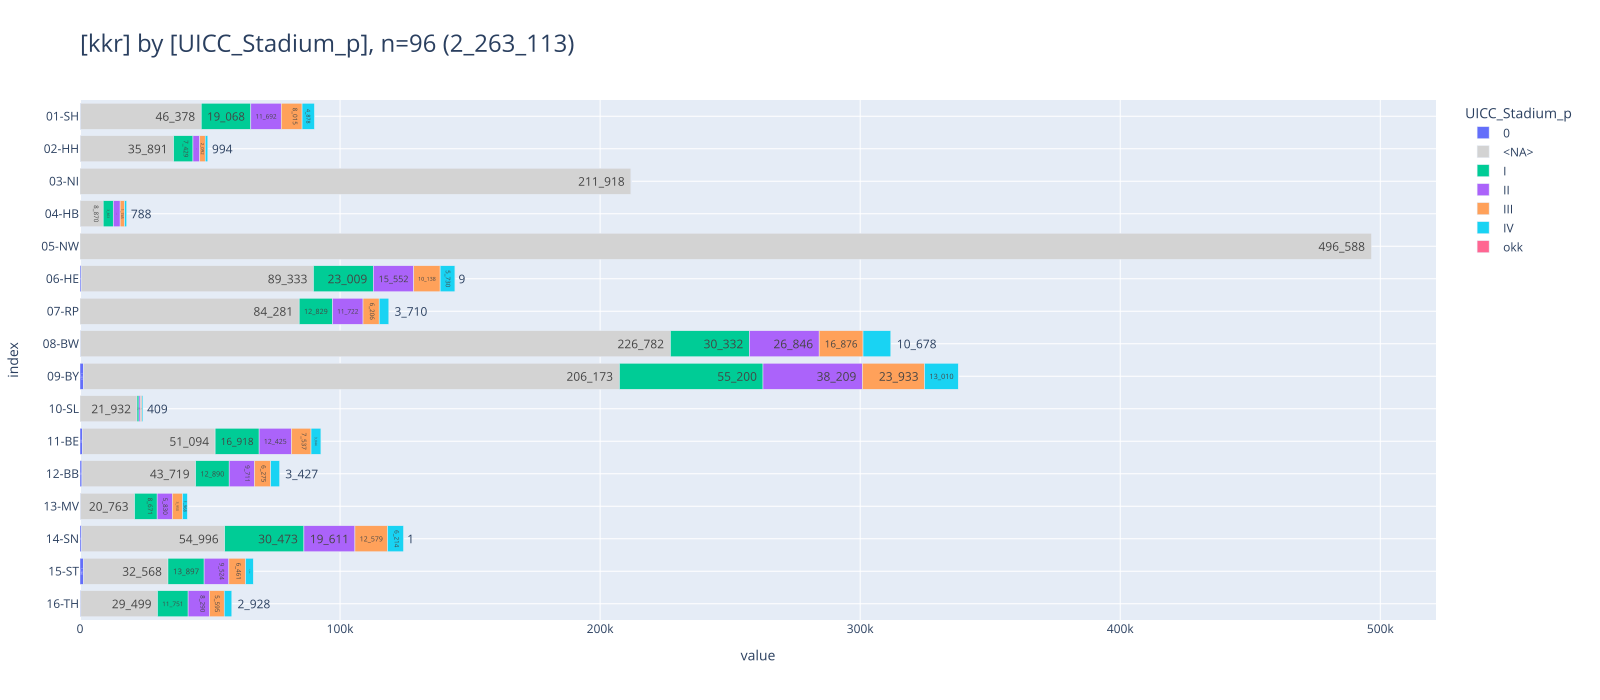

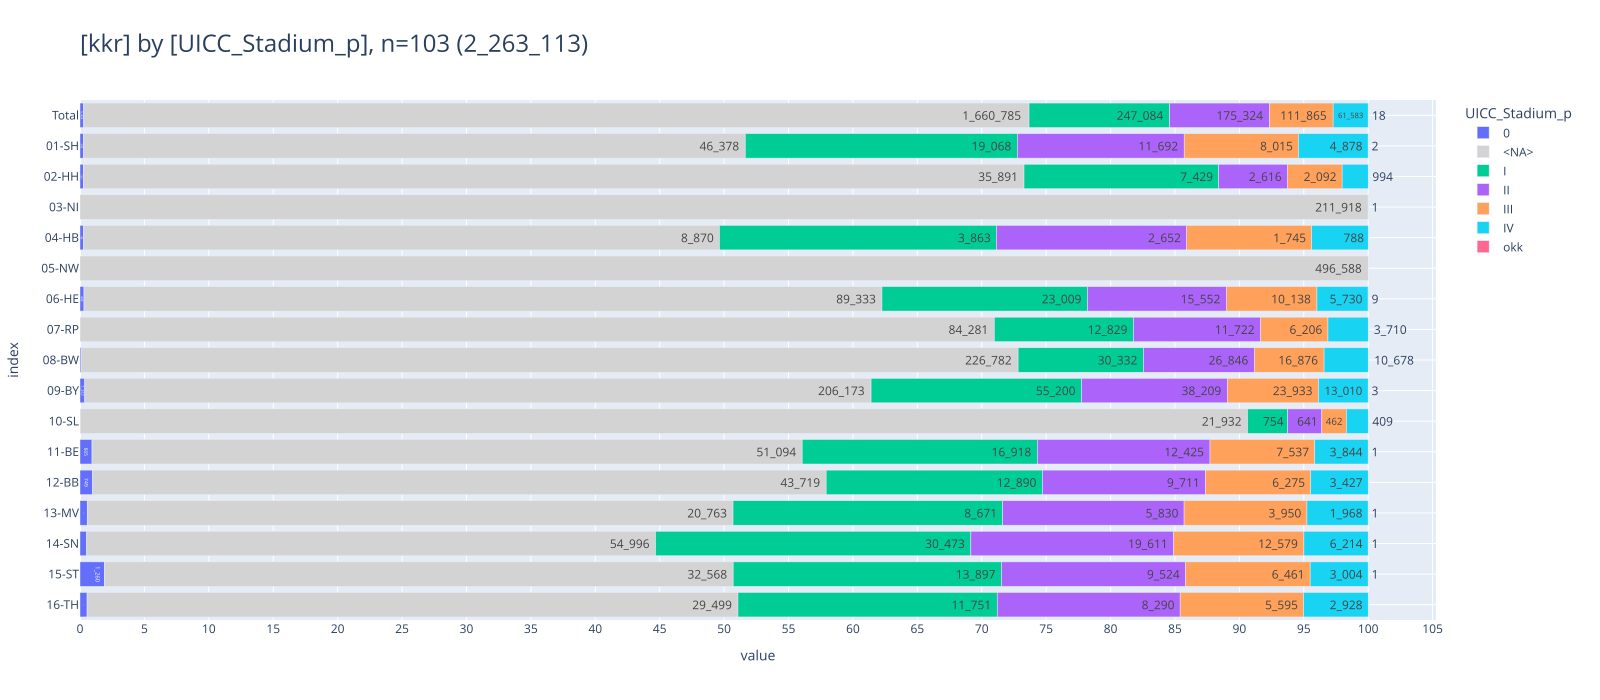

In [19]:
_tu=show_vars(2, grouper_reg.KKR.value, show=False, filter=FILTER_DY_SOLID_NO_DCO)
_=pls.plot_stacked_bars(_tu, swap=False, orientation='h', show_total=False, relative=False, height=700)
_=pls.plot_stacked_bars(_tu, swap=False, orientation='h', show_total=True, relative=True, height=700, dropna=False, )

# todo (DCN in klin. epi Fällen für GKR länder) pro DJ

<br>

### <a id='toc1_7_2_'></a>[Diagnosesicherung](#toc0_)
- **Filter: `DJ` = 2020-2024**

> 💡 `NI`: _"Die Ausprägung **DCO als Diagnosesicherung** kommt im KKN-Datensatz nicht vor. Diese Information liegt bisher nur dem EKN vor und wird gegebenenfalls zur Anreicherung von Datenexporten fallspezifisch vom KKN beim EKN angefragt. Der Prozess zur automatisierten Übermittlung dieser Informationen vom EKN zum KKN ist in Planung"_

> 💡 `ZfKD`: _Aufgrund der verschiedenartigen Handhabung von DCO in den übermittelten Daten ist die Filterung nach DCO mit erheblicher Unschärfe verbunden_

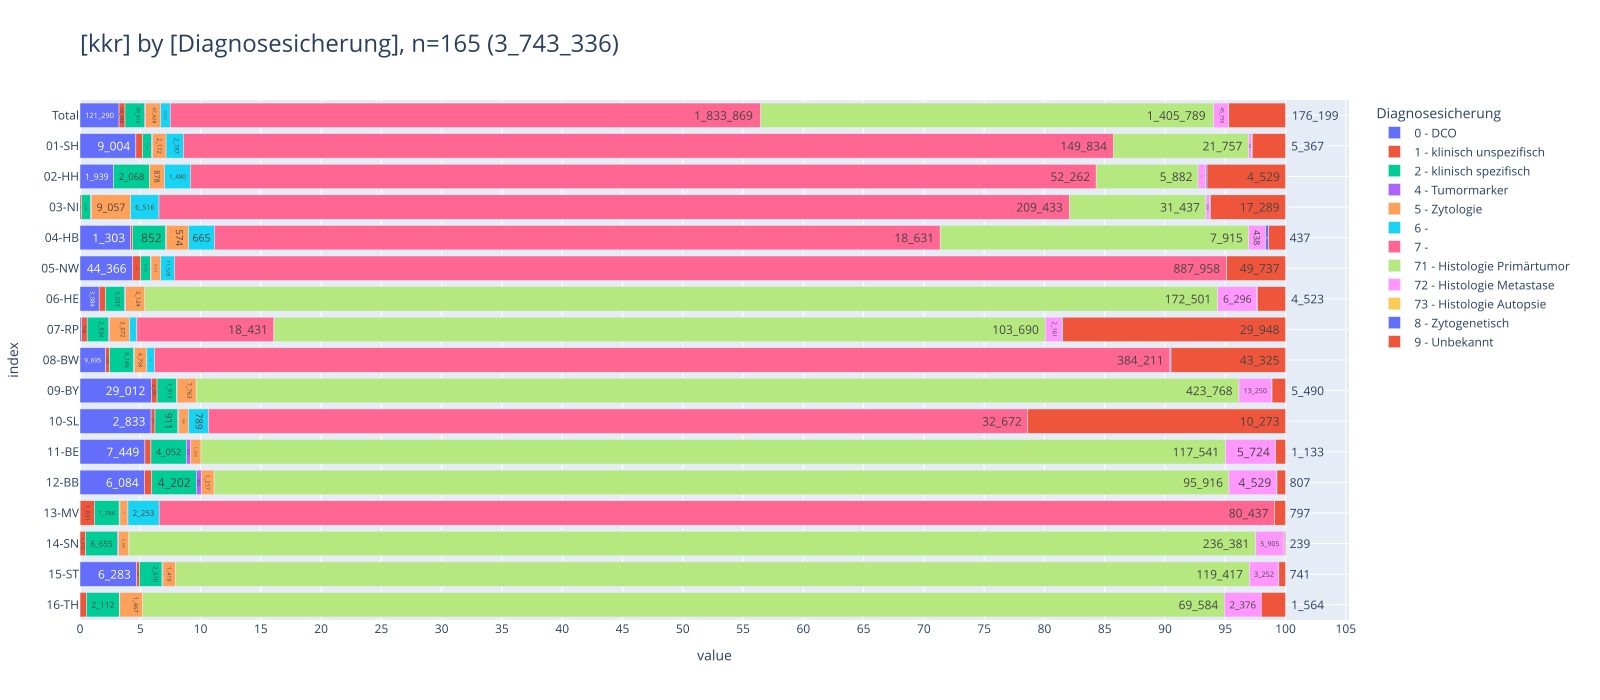

In [20]:
_ = show_vars(
    3,
    grouper_reg.KKR.value,
    show=True,
    filter=FILTER_DY,
    # filter="z_dy = 2024",
)


<br>

### <a id='toc1_7_3_'></a>[Geschlecht](#toc0_)
- Grundgesamtheit: Menge aller **Patienten** 
- **Filter: `DJ` = 2020-2024, Geschlecht in (`M`,`W`)**

> 💡 `ZfKD`: _Angaben zu Geschlecht ungleich `M` oder `W` sind sehr selten, diese Fälle werden nicht gesondert verarbeitet_

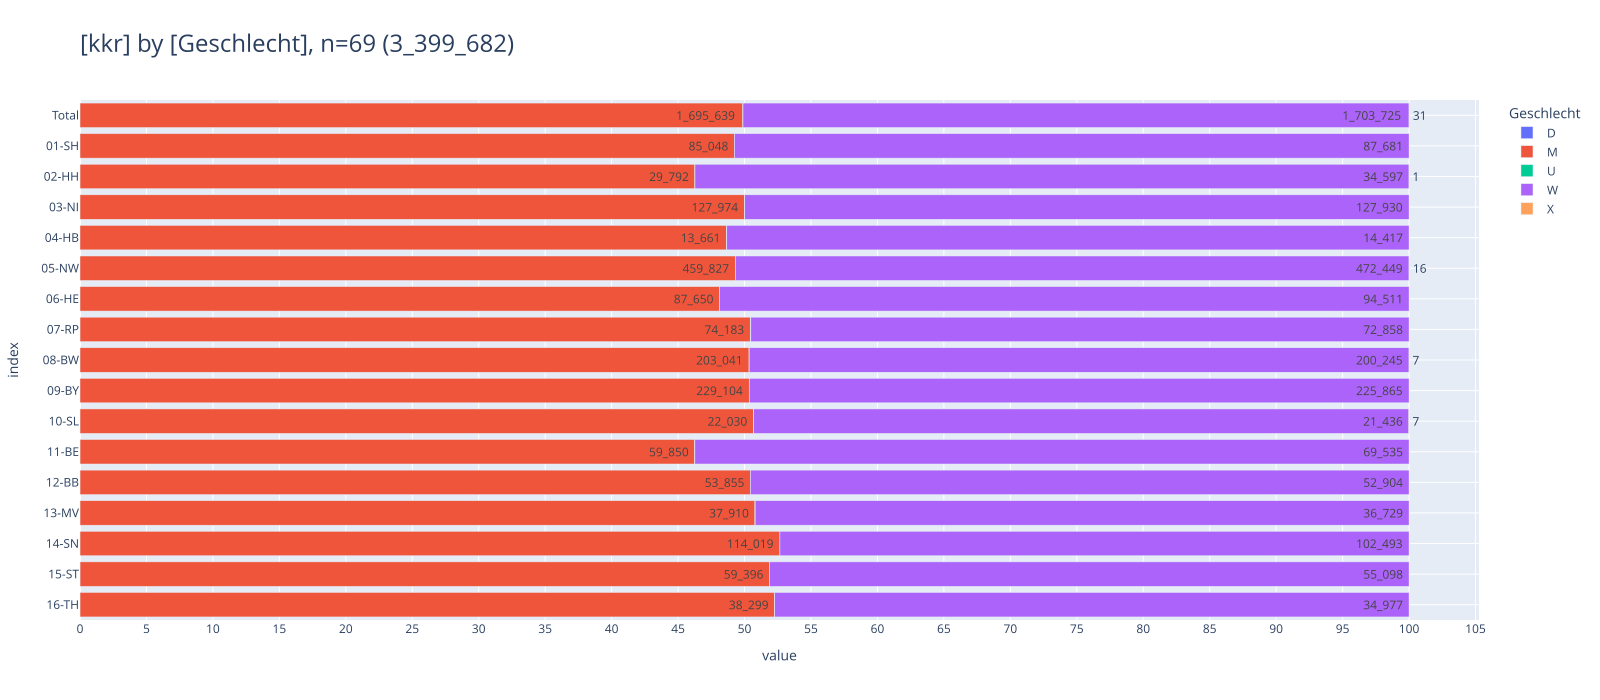

Anzahl Ausprägungen <> M oder W im Gesamtdatensatz: {'D': 43, 'U': 244, 'X': 31}


In [21]:
_tu=show_vars(0, grouper_reg.KKR.value, show=True, filter=FILTER_DY)
_other = _tu[~_tu["Geschlecht"].isin(["M", "W"])].groupby("Geschlecht")["cnt"].sum().to_dict()
print(f"Anzahl Ausprägungen <> M oder W im Gesamtdatensatz: {_other}")

### <a id='toc1_7_4_'></a>[🆕 Grading](#toc0_)

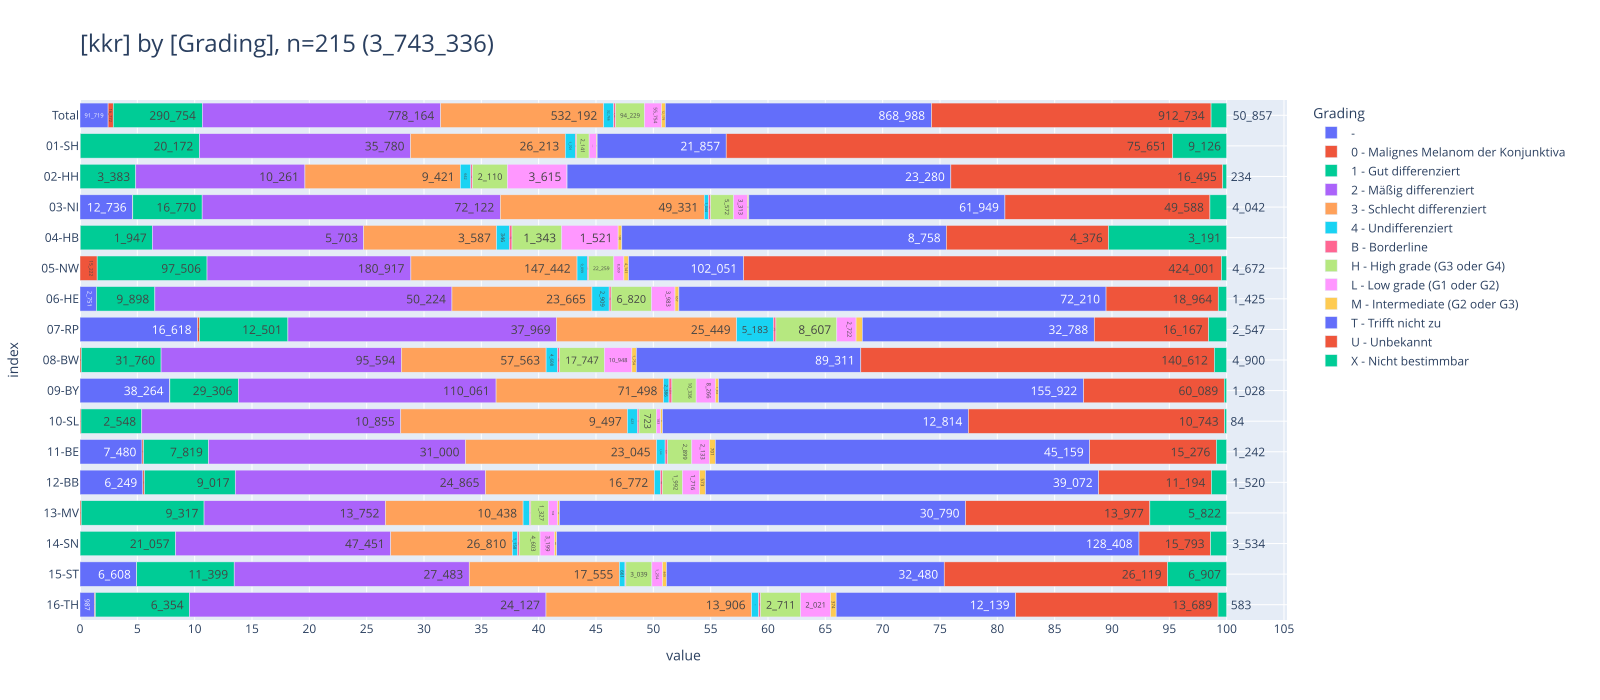

In [129]:
_ = show_vars(
    13,
    grouper_reg.KKR.value,
    show=True,
    filter=FILTER_DY,
)

<br>

### <a id='toc1_7_5_'></a>[Diagnosejahr](#toc0_)
- Filter: Top 5 Diagnosejahre
- Legende ist **absteigend sortiert nach Fallzahl im DJ**, Restkategorie `<other>` ist aufgeführt

Anzahl 2025 Fälle: {'11-BE': 322, '13-MV': 10, '12-BB': 351, '09-BY': 3102, '06-HE': 443, '15-ST': 2769, '14-SN': 5}


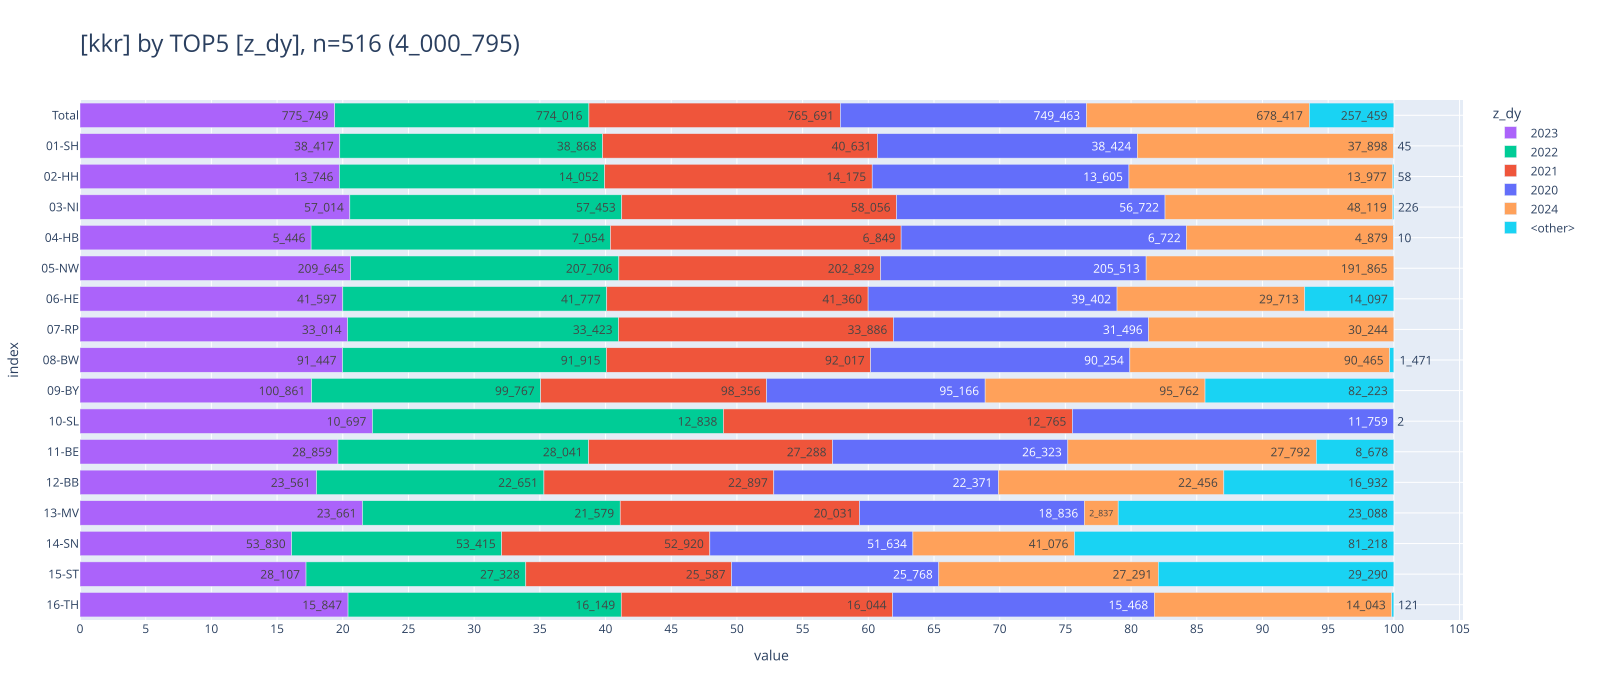

In [22]:
_tu = show_vars(4, grouper_reg.KKR.value, show=False)
print(
    f"Anzahl {str(DY_MAX+1)} Fälle: {_tu[_tu['z_dy'] == str(DY_MAX+1)].set_index('kkr')['cnt'].to_dict()}"
)
_ = pls.plot_stacked_bars(
    _tu,
    swap=False,
    orientation="h",
    show_total=True,
    normalize=False,
    relative=True,
    height=700,
    top_n_color=5,
    sort_values_color=True,
    show_other=True,
)
# todo extra ohne altdaten

<br>

### <a id='toc1_7_6_'></a>[Inzidenzort vs Lieferregister](#toc0_)
- **Filter: keiner**
- vertikal: `Inzidenzort` (Zeile `00` bündelt alle Fälle mit ungültiger Ortsangabe). horizontal: `Lieferregister`
- Beispiel: `03-NI` liefert zu 100% Fälle aus dem Inzidenzort `03`, `13-MV` liefert 159 Fälle aus `03`
> 💡 `ZfKD`: _Angestrebt ist eine "Diagonale", möglichst nur noch Fallübermittlungen aus dem eigenen Einzugsgebiet, was inzwischen schon besser erreicht ist. ~ 99% der Fälle stammen aus dem liefernden Register_

In [23]:
_tu = show_vars(5, grouper_reg.KKR.value, show=False).rename(columns={"Inzidenzort_BL":"ort"}).fillna(0)
_tu.loc[_tu["ort"]=="","ort"]="00"
_tu.loc[(_tu['ort'].astype(int) < 1) | (_tu['ort'].astype(int) > 16), "ort"]="00"
tbl.show_num_df(
    _tu.pivot_table(index="ort", columns="kkr", values="cnt", fill_value=0, dropna=False),
    data_bar_axis="xy",
    total_axis="xy",
    total_exclude=True,
    pct_axis="x",
    font_size_th=8,
    font_size_td=6,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
ort,,,,,,,,,,,,,,,,,
00,0,0,0,0,0,0,0,0,3 (0.0%),0,1 (0.0%),0,504 (0.5%),0,0,0,508 (0.0%)
01,194_283 (100.0%),0,0,0,0,0,0,0,0,0,0,6 (0.0%),29 (0.0%),1 (0.0%),0,0,194_319 (4.9%)
02,0,69_613 (100.0%),0,0,0,0,0,0,0,0,0,0,2 (0.0%),4 (0.0%),0,0,69_619 (1.7%)
03,0,0,277_590 (100.0%),0,0,0,0,0,0,0,2 (0.0%),0,227 (0.2%),9 (0.0%),0,0,277_828 (6.9%)
04,0,0,0,30_960 (100.0%),0,0,0,0,0,0,0,0,0,0,0,0,30_960 (0.8%)
05,0,0,0,0,1_017_558 (100.0%),0,0,0,1 (0.0%),0,0,0,0,9 (0.0%),1 (0.0%),0,1_017_569 (25.4%)
06,0,0,0,0,0,207_946 (100.0%),0,0,1 (0.0%),0,1 (0.0%),0,0,9 (0.0%),108 (0.1%),0,208_065 (5.2%)
07,0,0,0,0,0,0,162_063 (100.0%),0,2 (0.0%),0,0,0,0,7 (0.0%),0,0,162_072 (4.1%)
08,0,0,0,0,0,0,0,457_569 (100.0%),391 (0.1%),0,0,0,6 (0.0%),7 (0.0%),0,0,457_973 (11.4%)


<br>

### <a id='toc1_7_7_'></a>[ICD10 Gruppen](#toc0_)
- **Filter: `DJ` =  2020 - 2024**
- die verwendete ICD10 Skala entspricht der Darstellung aus *"Krebs in Deutschland"*
> 💡 `NI`: _"Für nicht-melanozytäre Hautkrebsarten bestimmter Histologien sowie fortgeschrittene Plattenepithelkarzinome gilt ab dem 20. September 2023 eine geänderte Meldepflicht. Erst seit diesem Zeitpunkt sind die prognostisch ungünstigen Hauttumore **(C44)** an das KKN zu melden und kommen daher im gelieferten Datensatz bisher nicht vor. In den nächsten Lieferungen werden diese Daten enthalten sein"_

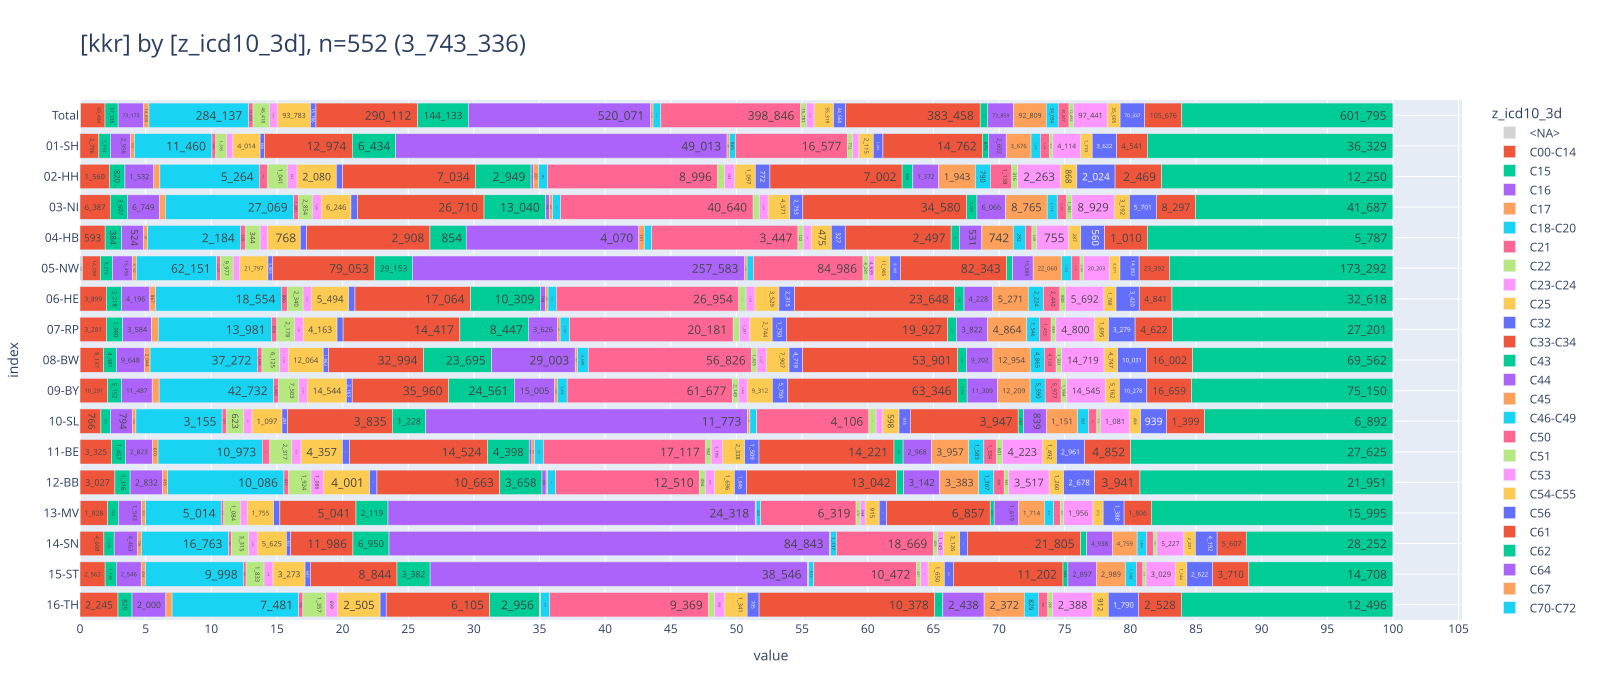

In [24]:
_=show_vars(6, grouper_reg.KKR.value, show=True, filter=FILTER_DY)
# todo ticket NI

<br>

### <a id='toc1_7_8_'></a>[Verstorben](#toc0_)

- **Filter: `DJ` = 2020-2024, `DCO` = N, `ICD10` != C44**
- gezählt sind **Personen**

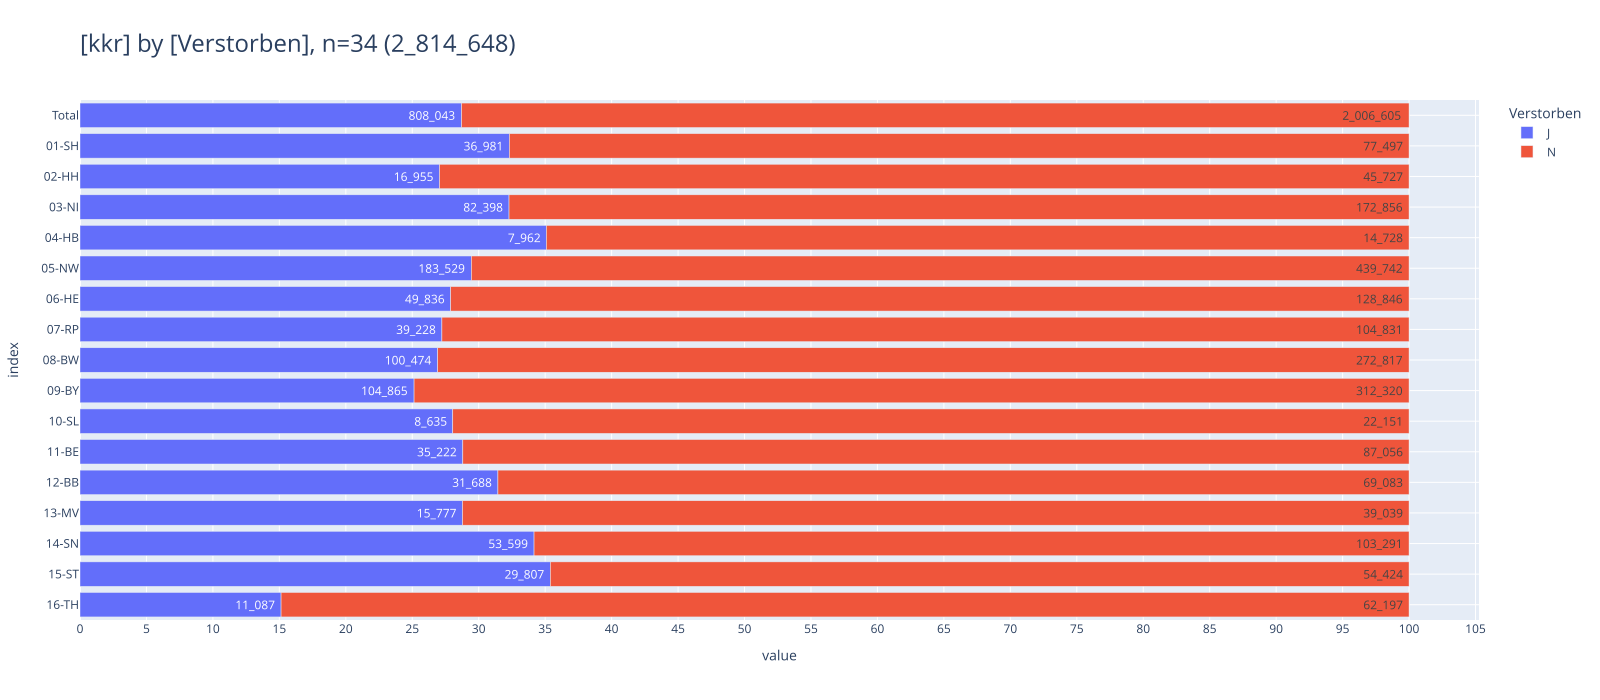

In [25]:
_ = show_vars(
    1,
    grouper_reg.KKR.value,
    show=True,
    #filter=f"z_dy > 2019 and z_dy <= {DY_MAX} and z_icd10_3d != 'C44' and not z_is_dco",
    filter=FILTER_DY_NO_DCO_NO_C44,
)
# todo ticket TH: erfassung todesfälle

<br>

### <a id='toc1_7_9_'></a>[TNM-T (p)](#toc0_)
- **Filter: `DJ` = 2020-2024, `DCO` = N, `ICD10` nur solide Tumoren**

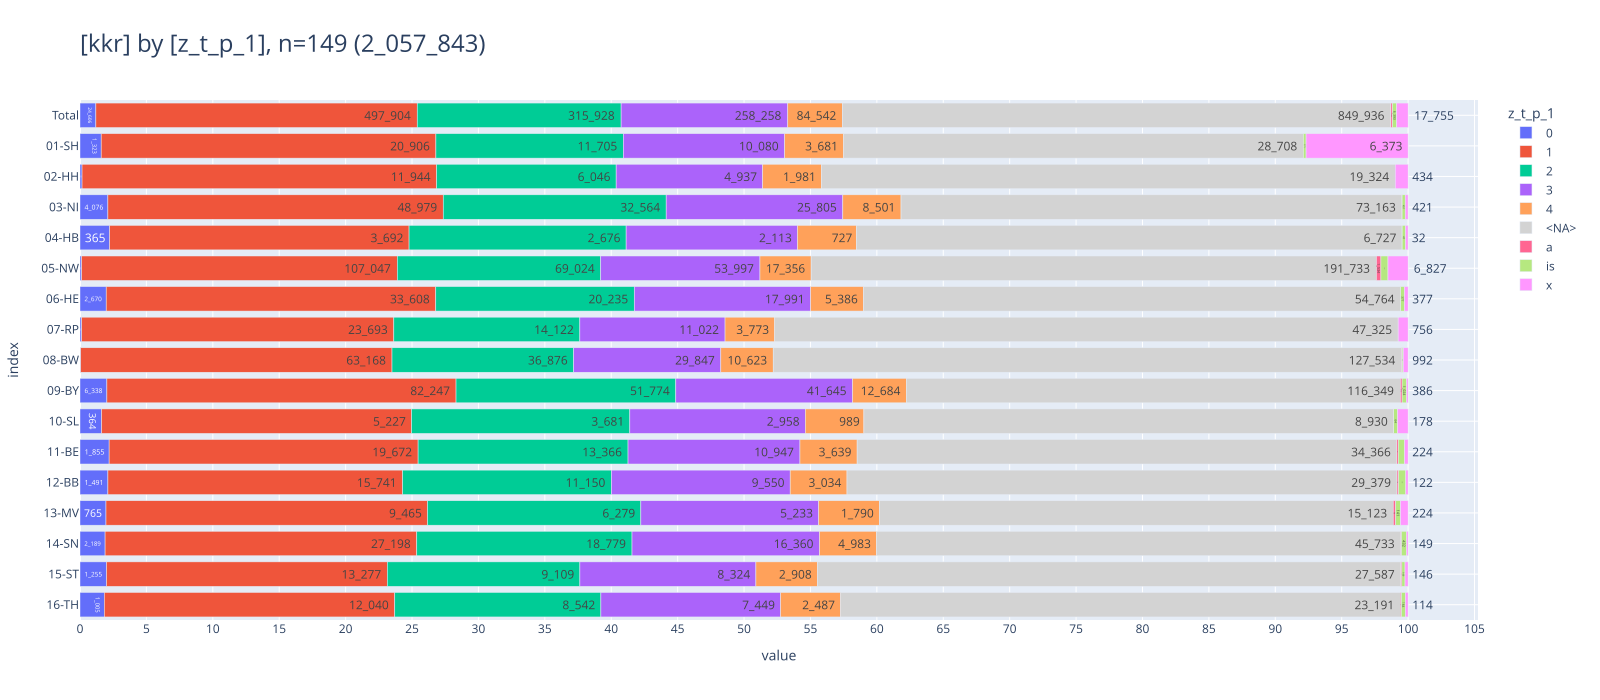

In [26]:
_filter = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and {FILTER_TNM}
"""
# hlp.print_filter(_filter)

# _=show_vars(9, grouper_reg.KKR.value, show=True, filter=FILTER_DY_SOLID_NO_DCO)
_=show_vars(9, grouper_reg.KKR.value, show=True, filter=_filter)

<br>

### <a id='toc1_7_10_'></a>[TNM-N (p)](#toc0_)
- **Filter: `DJ` = 2020-2024, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C70-C72, C76-C97, alle D)


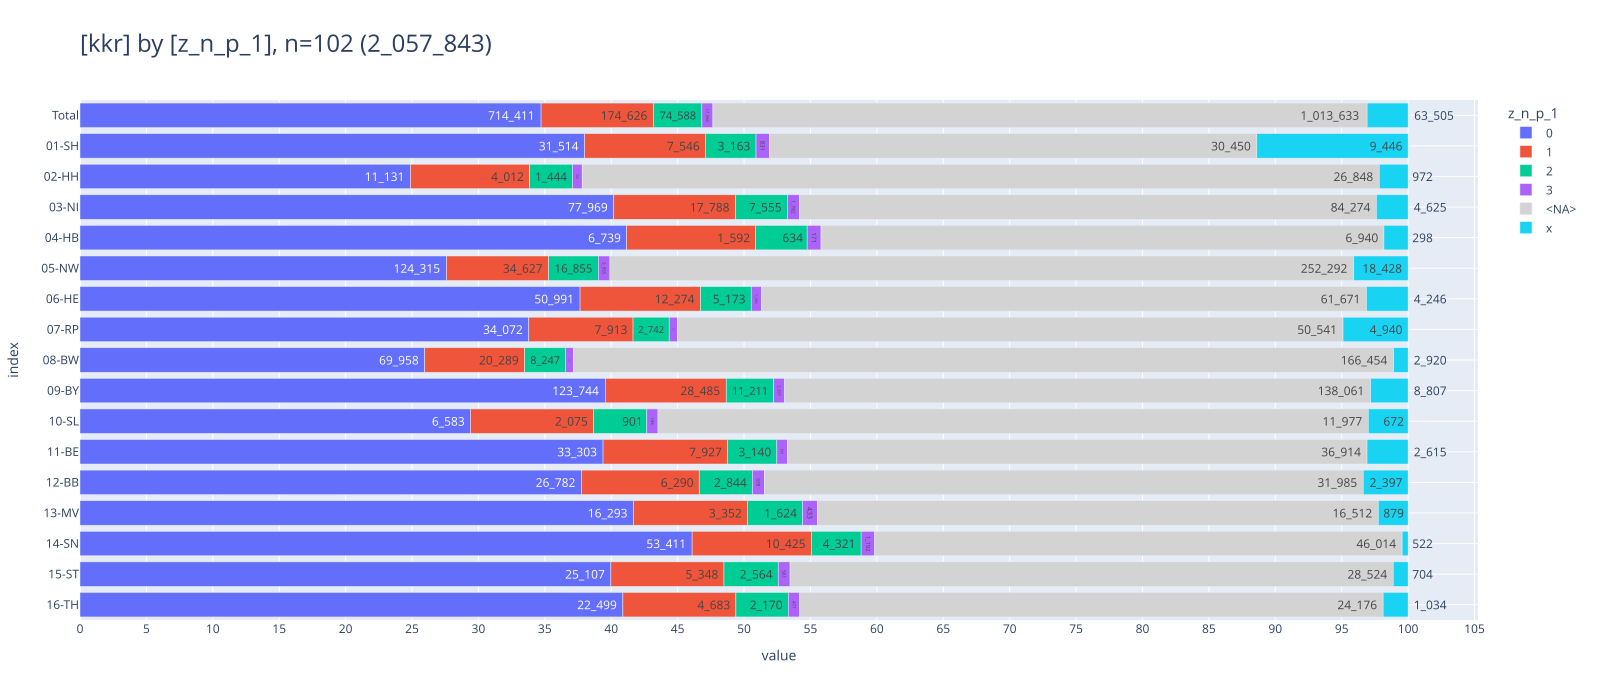

In [27]:
_filter = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and {FILTER_TNM}
"""

_=show_vars(11, grouper_reg.KKR.value, show=True, filter=_filter)

<br>

### <a id='toc1_7_11_'></a>[TNM-M (p)](#toc0_)
- **Filter: `DJ` = 2020-2024, `DCO` = N, `ICD10` nur TNM relevante**

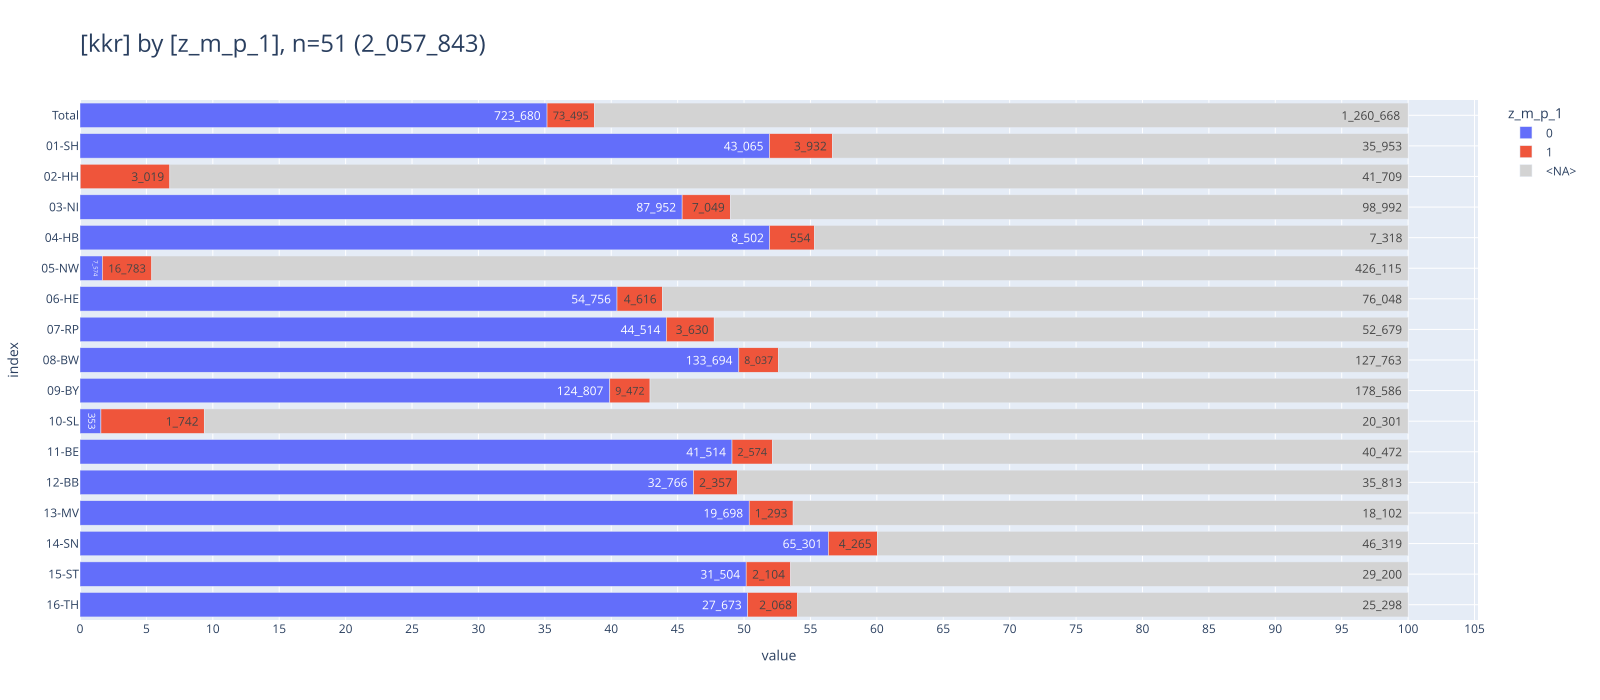

In [28]:
_filter = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and {FILTER_TNM}
"""

_=show_vars(12, grouper_reg.KKR.value, show=True, filter=_filter)

<br>

## <a id='toc1_8_'></a>[Todesursachen (TU)](#toc0_)

### <a id='toc1_8_1_'></a>[nach ICD10 Einstellern](#toc0_)
- gezählt sind die ersten Stellen aller TU Codes ohne jeglichen Filter

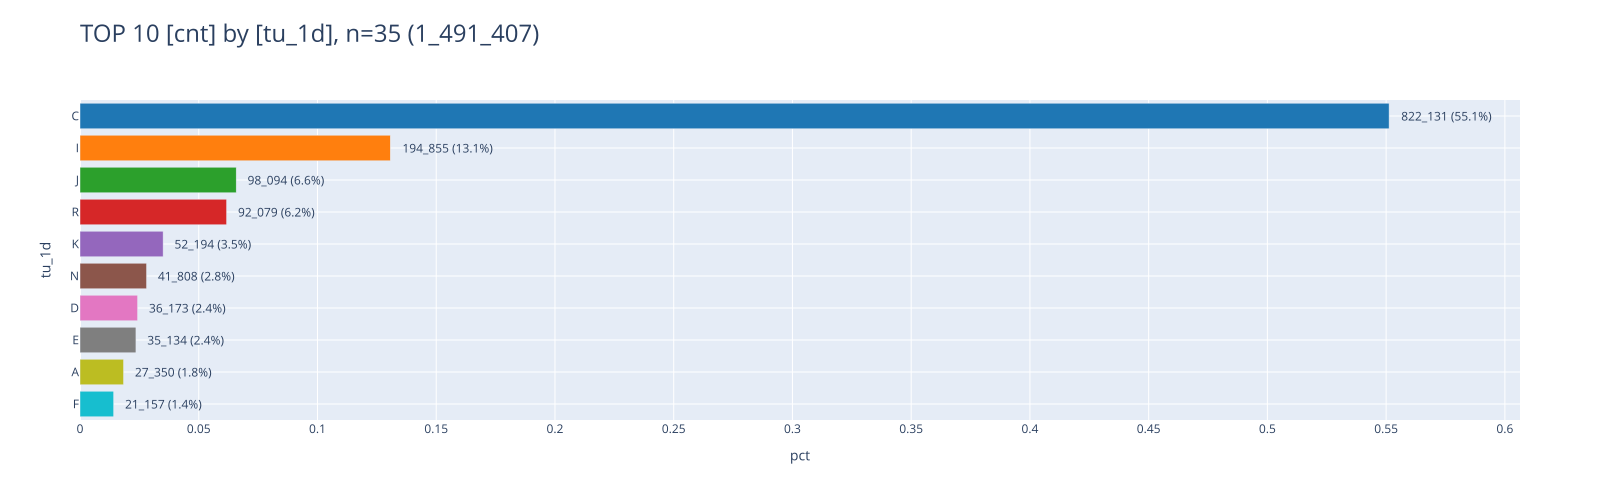

In [29]:
db_tu = Todesursache.project("*, upper(substr(Code, 1,1)) as tu_1d")
_ = pls.plot_bars(
    db_tu.aggregate("tu_1d, count(*) as cnt").to_df(),
    orientation="h",
    sort_values=True,
    height=500,
    top_n_index=10,
)

### <a id='toc1_8_2_'></a>[nach Sterbejahr und Todesursachen](#toc0_)
- gezählt werden **Personen**
- **Filter: `SJ`= 2020-2024, `Verstorben` = J**
- `tu_type` Art der TU pro Patient
  - `<NA>` keine Todesursache zugeordnet
  - `c_only` nur Todesursachen Cxx
  - `other_only` nur Todesursachen <> Cxx
  - `c_and_other` Cxx und andere Todesursachen

<!-- > 💡 `ZfKD`: _"`03-NI` und `06-HE` übermitteln deutlich weniger Todesursachen asl in den epi Daten, für `07-RP` ist der Anteil in beiden Datenräumen gering. Für `15-ST` sind auffällig wenige Todesfälle in 2023 übermittelt."_ -->

<!-- START_TOKEN -->

# filter

    year(Datum_Vitalstatus::date) between 2020 and 2024
    and Verstorben='J'



<!-- END_TOKEN -->

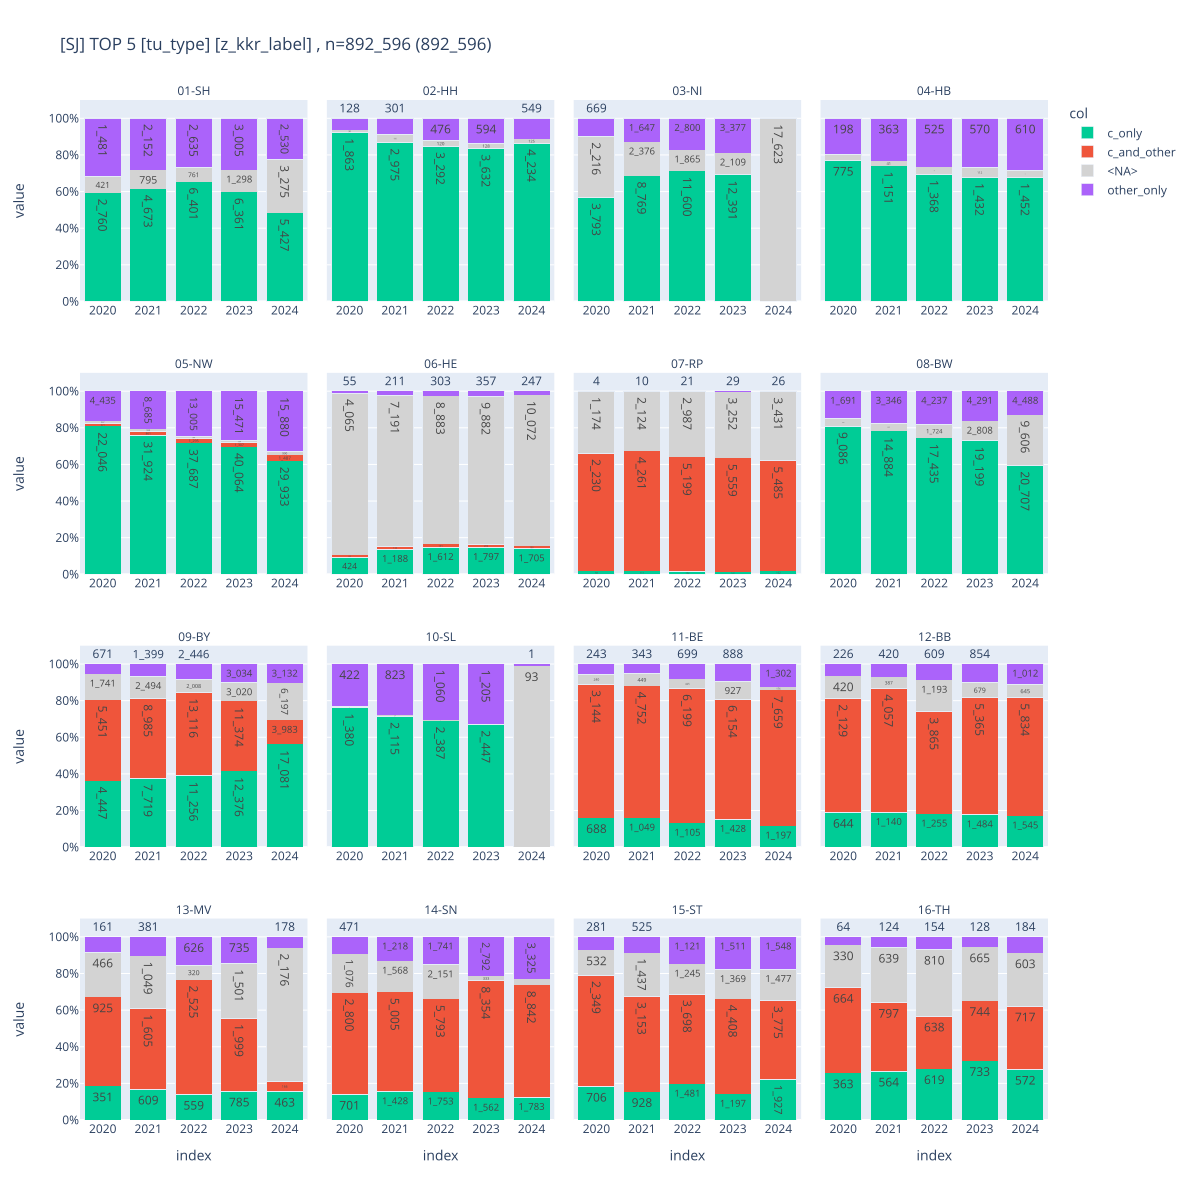

In [30]:
_filter = f"""--sql
    year(Datum_Vitalstatus::date) between 2020 and {DY_MAX}
    and Verstorben='J'
"""

db_tu2 = con.sql(f"""--sql
    with t1 as (
        -- raw list, 1 pat -> n tu
        select
            pat.oBDS_RKIPatientId as z_pat_id,
            year(Datum_Vitalstatus::date) as SJ,
            -- check both independantly
            case when left(code,1)='C' then true else false end as has_c,
            case when left(code,1)<>'C' then true else false end as has_other,
            pat.z_kkr,
            Code,
            Version,
            IsGrundleiden,
        from Patient pat
        left join Todesursache tu on pat.oBDS_RKIPatientId = tu.oBDS_RKIPatientId
        where {_filter}
    ),
    t2 as (
        -- 1 pat -> 1 tu_type
        select
            z_pat_id,
            SJ,
            z_kkr,
            case
                when max(has_c) and max(has_other) then 'c_and_other'
                when max(has_c) and not max(has_other) then 'c_only'
                when not max(has_c) and max(has_other) then 'other_only'
                -- use null for a prominent, grey bar in diagram
                when not max(has_c) and not max(has_other) then null
                -- this should never show
                else 'U'
            end as tu_type,
        from t1
        -- SJ and kkr are neutral in the group
        group by z_pat_id, SJ, z_kkr
    ),
    t3 as (
        -- assign label
        select
            SJ,
            tu_type,
            lr.kkr as z_kkr_label,
        from t2
        left join dim_lieferregister lr on t2.z_kkr = lr.code
    )
    select * from t3
    """)
# tbl.descr_db(db_tu2,"tu_type")
df_tu2 = db_tu2.to_df()

hlp.print_filter(_filter)

_ = pls.plot_facet_stacked_bars(
    df_tu2,
    subplots_per_row=4,
    top_n_color=5,
    sort_values_color=True,
    sort_values_facet=True,
    show_other=False,
    relative=True,
    annotations=True,
    renderer="svg",
)

In [31]:
# _filter = f"""--sql
#     year(Datum_Vitalstatus::date) between 2020 and {DY_MAX}
#     and Verstorben='J'
# """

# # # * get list of all patient and their first TU
# _tu = (Patient.set_alias("p")
#     .join(Todesursache, "oBDS_RKIPatientId", "inner")
#     .aggregate("p.oBDS_RKIPatientId, min(Code) as code")
# )
# # _tu

# db_tu=(
#     Patient
#     .join(_tu, "oBDS_RKIPatientId", "left")
#     .join(Tumor, "oBDS_RKIPatientId", "left")
#     .filter(_filter)
#     .project("""--sql
#             --z_dy 
#             year(Datum_Vitalstatus::date) as SJ
#             --,left(code,3) as tu
#             ,case 
#                 when left(code,1)='C' then 'C' 
#                 when left(code,1)<>'C' then '<other>' 
#                 else null end as tu_type
#             ,z_kkr_label
#     """)
# )
# df_tu = db_tu.to_df()

# hlp.print_filter(_filter)

# _ = pls.plot_facet_stacked_bars(
#     df_tu,
#     subplots_per_row=4,
#     top_n_color=5,
#     sort_values_color=True,
#     show_other=False,
#     relative=True,
#     annotations=True,
#     renderer="svg",
# )

<br>

### <a id='toc1_8_3_'></a>[nach hat_todesursache bei Nicht-Verstorbenen](#toc0_)
- gezählt werden **Personen**
- **Filter: `Verstorben` = N**

In [32]:
_pat = Patient.filter("Verstorben='N'").project("oBDS_RKIPatientId")
_df = (Todesursache
    .join(_pat, "oBDS_RKIPatientId")
    .aggregate("z_kkr, count(distinct oBDS_RKIPatientId) as cnt_tu")
    .join(dim_lieferregister, "z_kkr::int=code::int", "right")
    .project("kkr, cnt_tu")
    .order("kkr")
    .to_df().set_index("kkr").fillna(0)
    .T
)
# display(tbl.show_num_df(
#     _df,
#     total_axis="",
#     heatmap_axis="x",
#     font_size_th=9,
#     font_size_td=7,
# ))
con.from_df(_df
    .astype("int16")
    # .map(lambda x: f"{x:_.0f}")
    .reset_index(names="kkr")
).show()

┌─────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│   kkr   │ 01-SH │ 02-HH │ 03-NI │ 04-HB │ 05-NW │ 06-HE │ 07-RP │ 08-BW │ 09-BY │ 10-SL │ 11-BE │ 12-BB │ 13-MV │ 14-SN │ 15-ST │ 16-TH │ Total │
│ varchar │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │ int16 │
├─────────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┤
│ cnt_tu  │     1 │     0 │     0 │     0 │     0 │     0 │     0 │     0 │     2 │     8 │     1 │     3 │   472 │     0 │     0 │     2 │     0 │
└─────────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┘



<br>

### <a id='toc1_8_4_'></a>[nach ICD10 Dreistellern (TOP 5)](#toc0_)
- Grundgesamtheit: alle **Todesursachen**, kein Filter

> 💡 `ZfKD`: _Enthalten sind in einigen KKR auch `C79` (Metastasen), welche in offizieller Todesursachen-Statistik nicht kodiert sind_

In [33]:
_tu = (
    Todesursache.aggregate("z_kkr, left(Code,3) as tu_3d, count(*) as cnt")
    .join(dim_lieferregister, "z_kkr::int = code::int")
    .project("tu_3d,kkr, cnt")
    .to_df()
    # .pivot_table(index='tu_3d', columns='kkr', values='cnt', fill_value=0, dropna=False)
)
# tbl.show_num_df(_df, data_bar_axis="xy", total_axis="xy", total_exclude=True, pct_axis="x",)
tbl.pivot_df(
    _tu,
    top_n_index=5,
    data_bar_axis="xy",
    pct_axis="",
    swap=False,
    heatmap_axis="",
    total_axis="y",
    font_size_th=8,
    font_size_td=6,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tu_3d,,,,,,,,,,,,,,,,,
C18,1_642,1_006,2_444,351,10_948,153,2_328,5_103,8_902,520,2_431,2_259,924,4_087,2_050,519,45_667
C25,2_768,1_483,3_353,558,16_831,245,3_204,8_399,11_724,744,3_979,3_438,1_566,5_701,2_514,800,67_307
C34,6_974,4_048,9_682,1_674,45_386,916,7_875,16_197,22_923,2_068,10_423,7_789,3_621,9_624,5_350,1_754,156_304
C78,0,0,0,0,221,2_950,9_399,0,8_494,0,5_765,5_130,1_948,8_169,3_875,1_306,47_257
C79,0,0,0,0,189,3_383,13_541,0,25_133,0,4_849,3_019,1_184,4_824,2_092,628,58_842


<br>

### <a id='toc1_8_5_'></a>[nach IsGrundleiden](#toc0_)
- Grundgesamtheit: **alle Todesursachen**

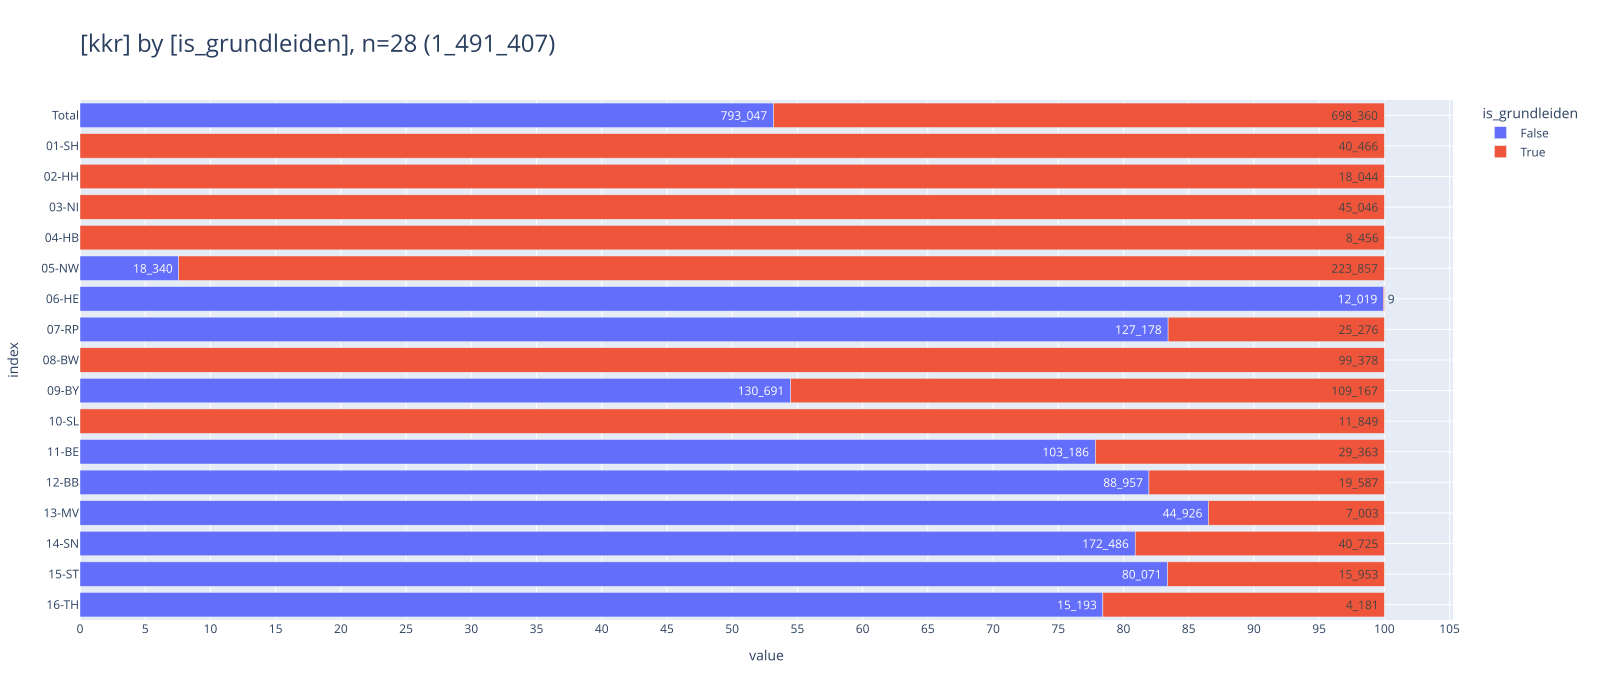

In [34]:
_tu = (
    Todesursache.aggregate(
        "z_kkr, cast(IsGrundleiden as bool) as is_grundleiden, count(*) as cnt"
    )
    .join(dim_lieferregister, "z_kkr::int = code::int")
    .project("kkr, is_grundleiden, cnt")
    .to_df()
)
_=pls.plot_stacked_bars(_tu, orientation="h", height=700, relative=True, show_total=True)

## <a id='toc1_9_'></a>[Therapien](#toc0_)

<br>

### <a id='toc1_9_1_'></a>[OP](#toc0_)


#### <a id='toc1_9_1_1_'></a>[nach ICD10](#toc0_)
- Grundgesamtheit: alle **OP Meldungen**

<!-- START_TOKEN -->

# filter

    z_dy between 2020 and 2024
    and z_op_order = 1



<!-- END_TOKEN -->

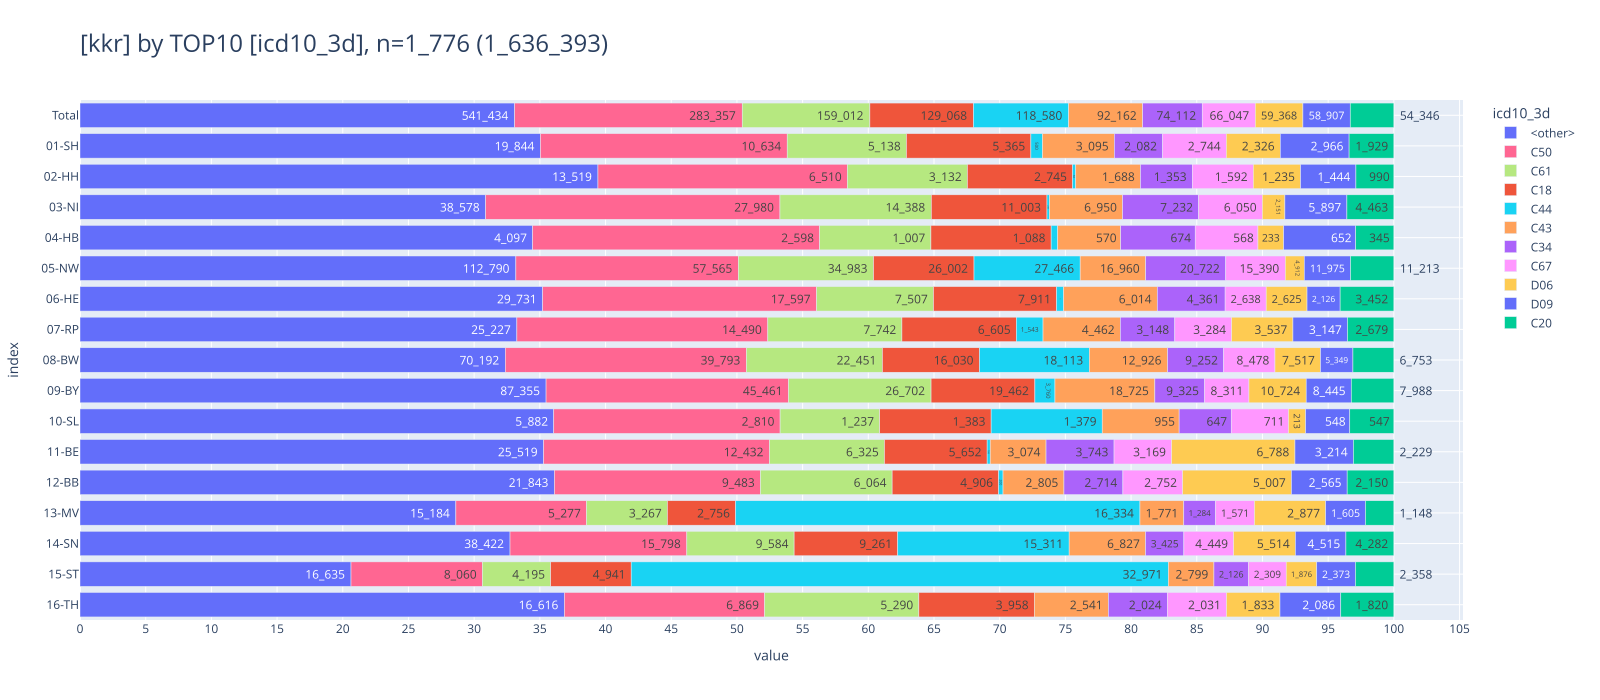

In [35]:
_filter = f"""--sql
    {FILTER_DY}
    and z_op_order = 1
"""

hlp.print_filter(_filter)

_op = (OP
    .join(Tumor
        .set_alias("t")
        .project("*, left(Diagnose_ICD10_Code,3) as icd10_3d"), 
        "z_tum_id")
    .filter(_filter)
    .aggregate("icd10_3d, t.z_kkr, count(*) as cnt")
    .join(dim_lieferregister, "z_kkr::int = code::int")
    .project("kkr, icd10_3d, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_op, orientation="h", height=700, top_n_color=10, relative=True, sort_values_color=True, show_other=True, show_total=True)


<br>

#### <a id='toc1_9_1_2_'></a>[nach Intention](#toc0_)
- Grundgesamtheit: alle **OP Meldungen**

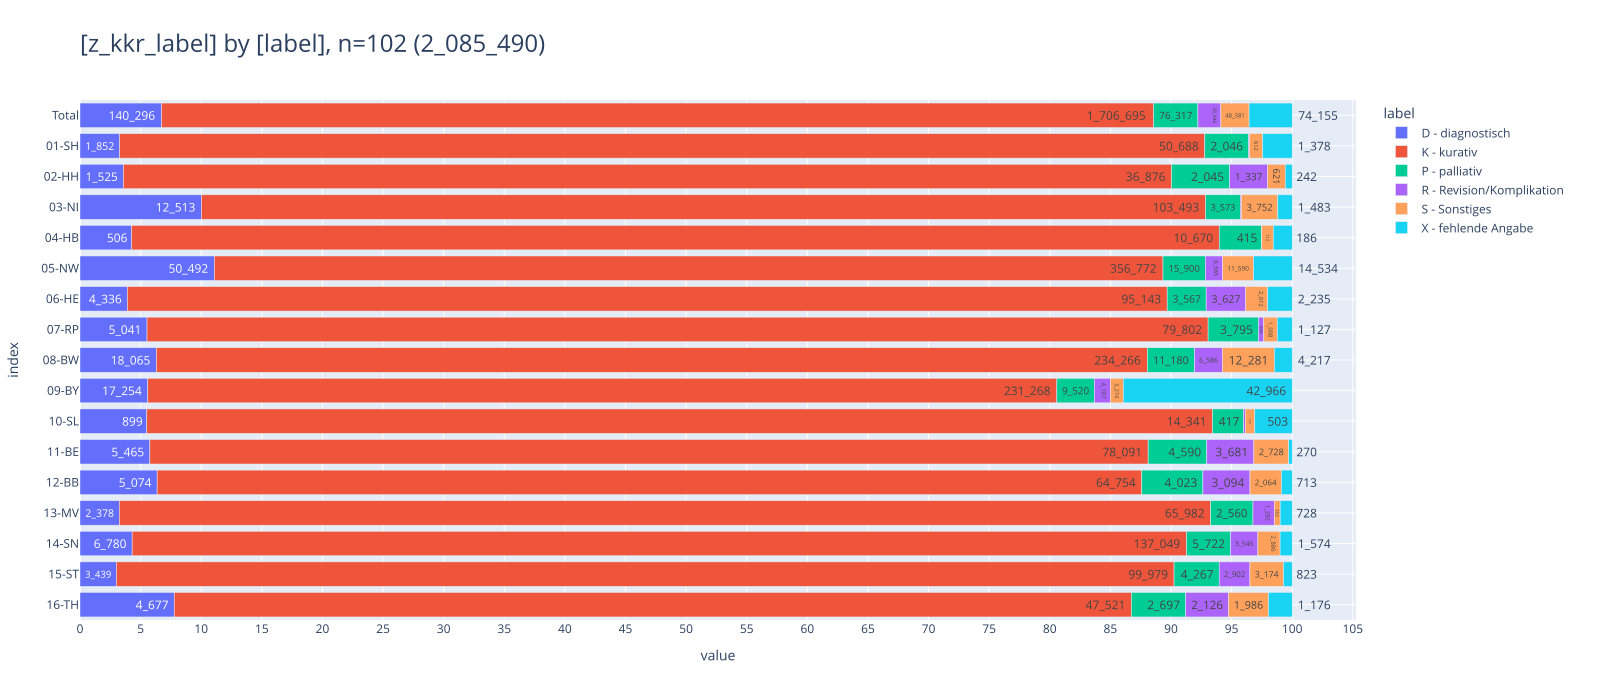

In [36]:
_op = (OP
    .join(Tumor.set_alias("t"), "z_tum_id")
    .aggregate("Intention, t.z_kkr_label, count(*) as cnt")
    .join(dim_op_intention.set_alias("i"), "Intention=i.code")
    .project("z_kkr_label,concat(i.code, ' -  ', i.name) as label, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_op, orientation="h", height=700, top_n_color=0, relative=True, show_total=True)

### <a id='toc1_9_2_'></a>[OP wenn OP erwartet](#toc0_)
- kategorien
  - `1_op`: mind. eine OPS im definierten Bereich (3Steller, organspezifisch) ist dokumentiert
  - `2_no_op_but_tp`: keine OPS, aber pT 1-4 ist dokumentiert
  - `3_rest`: keine der zuvor genannten Merkmale trifft

#### <a id='toc1_9_2_1_'></a>[C50](#toc0_)

<!-- START_TOKEN -->

counts: rows
---
n = 4_000_795                                    (100.0%) ██████████████████████████████
└ [C50]:                             n = 425_064  (10.6%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [2020-2024]:                       n = 398_846  (10.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [keine M1]:                        n = 371_246   (9.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [keine Verstorbenen < 180 Tage]:   n = 355_711   (8.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

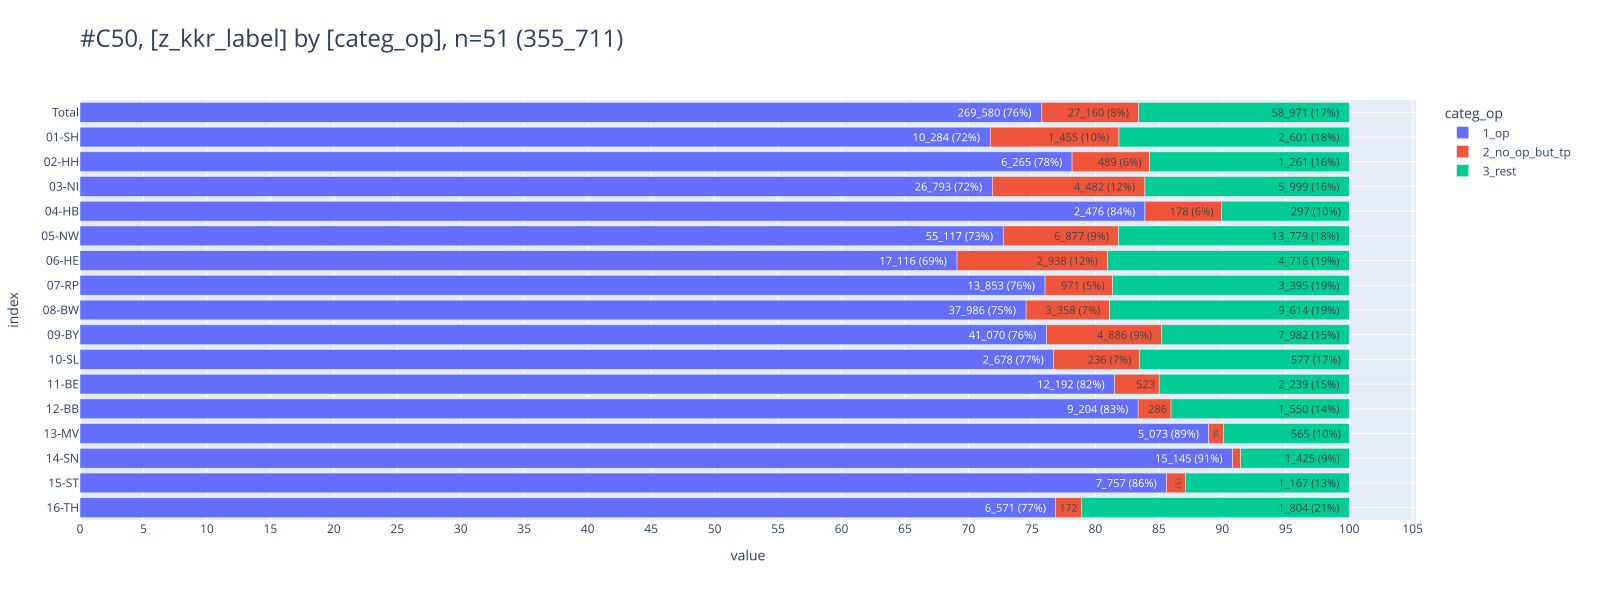

In [78]:
_filters = [
    ("z_icd10_3d = 'C50'", "C50"),
    (FILTER_DY, "2020-2024"),
    (FILTER_M0, "keine M1"),
    (FILTER_NO_180D_DEAD, "keine Verstorbenen < 180 Tage"),
    # (FILTER_AGE_LT_80, "unter 80 Jahre"),
]
_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    # query="from Tumor tum left join OPS ops on ops.z_tum_id = tum.z_tum_id",
    filters=_filters,
    # distinct_metric="z_tum_id",
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTER_OPS_C50} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C50",
)

#### <a id='toc1_9_2_2_'></a>[C18 - C20](#toc0_)

<!-- START_TOKEN -->

counts: rows
---
n = 4_000_795                                    (100.0%) ██████████████████████████████
└ [C18-C20]:                         n = 301_337   (7.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [2020-2024]:                       n = 284_137   (7.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [keine M1]:                        n = 235_120   (5.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine Verstorbenen < 180 Tage]:   n = 203_219   (5.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

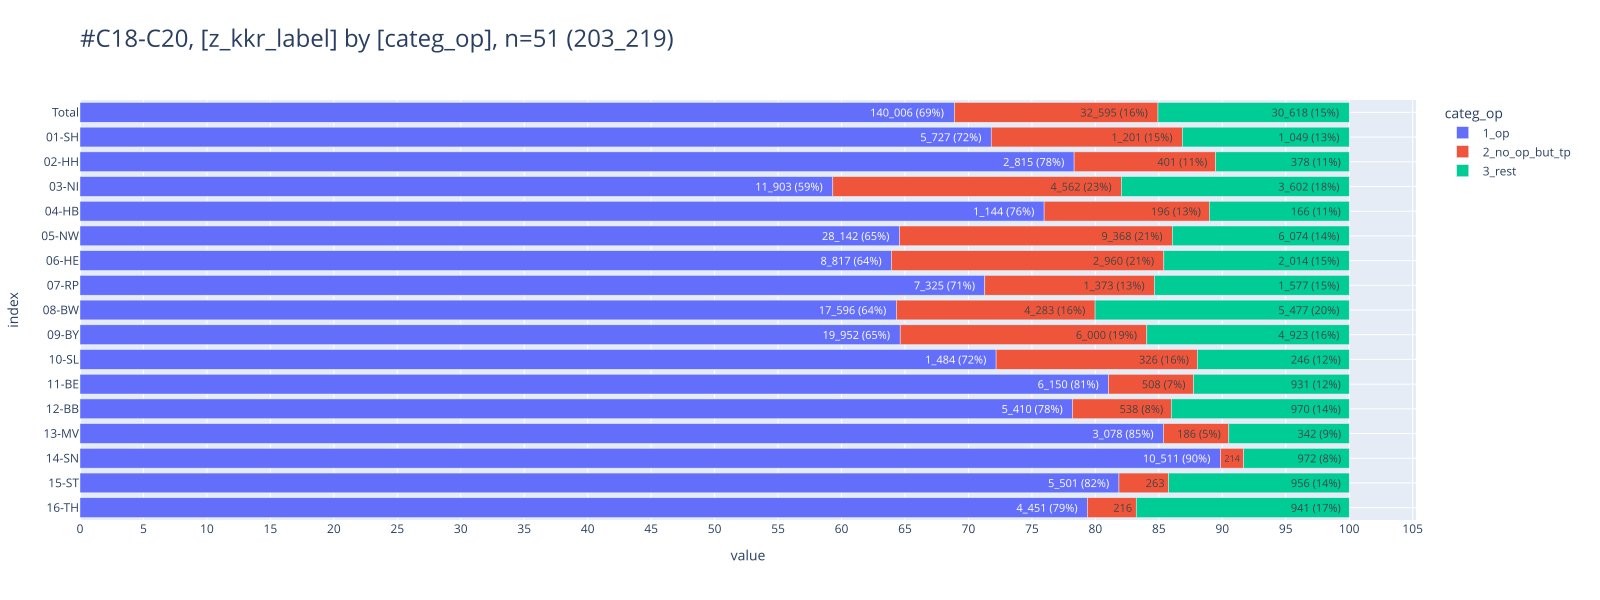

In [81]:
_filters = [
    ("z_icd10_3d in ('C18', 'C19', 'C20')", "C18-C20"),
    (FILTER_DY, "2020-2024"),
    (FILTER_M0, "keine M1"),
    (FILTER_NO_180D_DEAD, "keine Verstorbenen < 180 Tage"),
    # (FILTER_AGE_LT_80, "unter 80 Jahre"),
]
_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    # query="from Tumor tum left join OPS ops on ops.z_tum_id = tum.z_tum_id",
    filters=_filters,
    # distinct_metric="z_tum_id",
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTER_OPS_C18C20} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    caption="C18-C20",
)

<br>

### <a id='toc1_9_3_'></a>[OPS](#toc0_)


#### <a id='toc1_9_3_1_'></a>[nach OPS ICD Kapitel (Top 10)](#toc0_)
- Grundgesamtheit: **alle OPS Codes**

> 💡 `ZfKD`: _Lediglich `02-HH` und `05-NW` übermitteln ausschliesslich Kapitel 5. Der Anteil von Meldungen <> Kapitel 5 sind wahrscheinlich diagnostische Massnahmen oder nicht-operative Therapien. Vorschlag: nur noch Kapitel 5 übermitteln_

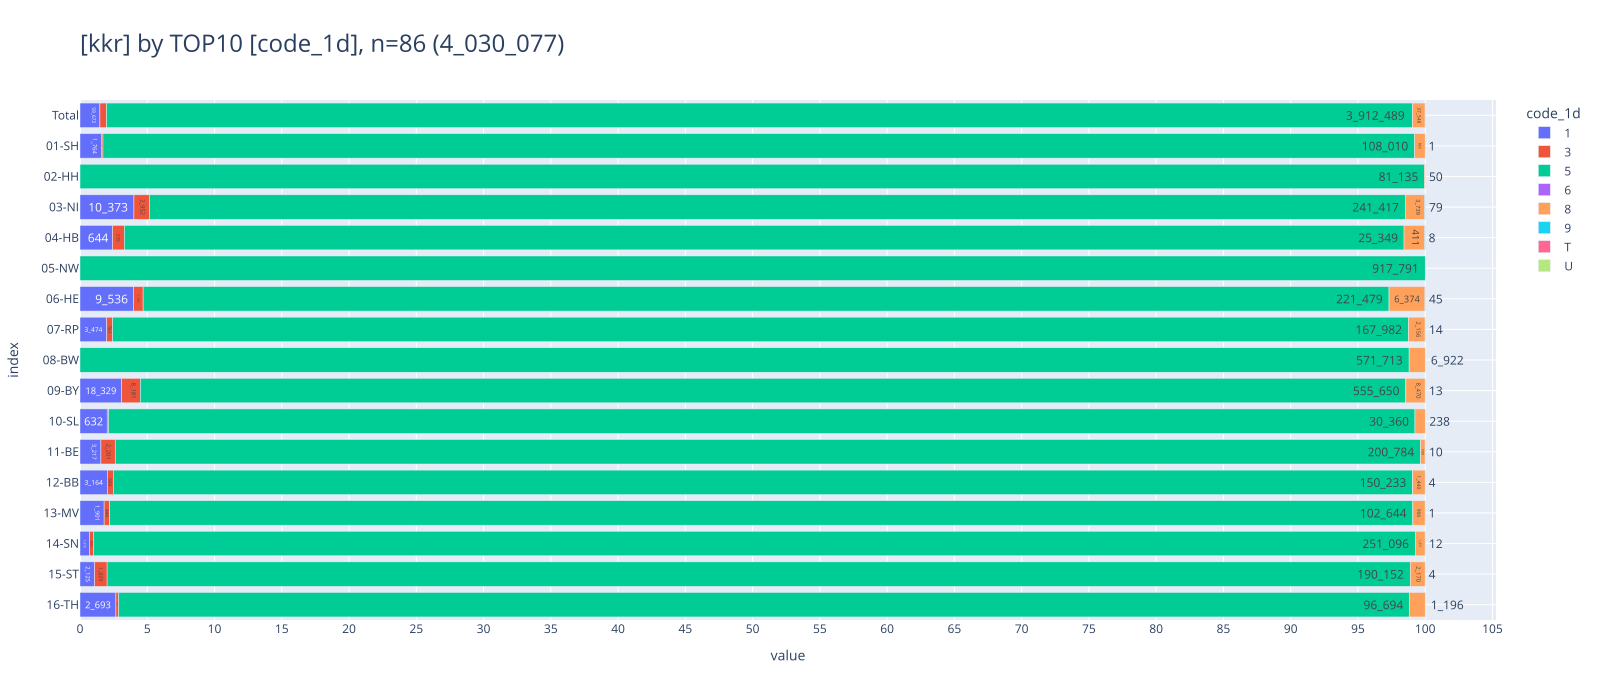

In [37]:
_ops = (OPS
    # .join(Tumor.set_alias("t"), "oBDS_RKIPatientTumorId")
    .aggregate("left(Code,1) as code_1d, z_kkr, count(*) as cnt")
    .join(dim_lieferregister, "z_kkr::int=code::int")
    .project("kkr, code_1d, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_ops, orientation="h", height=700, top_n_color=10, relative=True, sort_values_color=False, show_total=True)

### <a id='toc1_9_4_'></a>[SYST](#toc0_)

#### <a id='toc1_9_4_1_'></a>[nach Stellung_OP](#toc0_)

- Grundgesamtheit: **alle SYST Elemente**

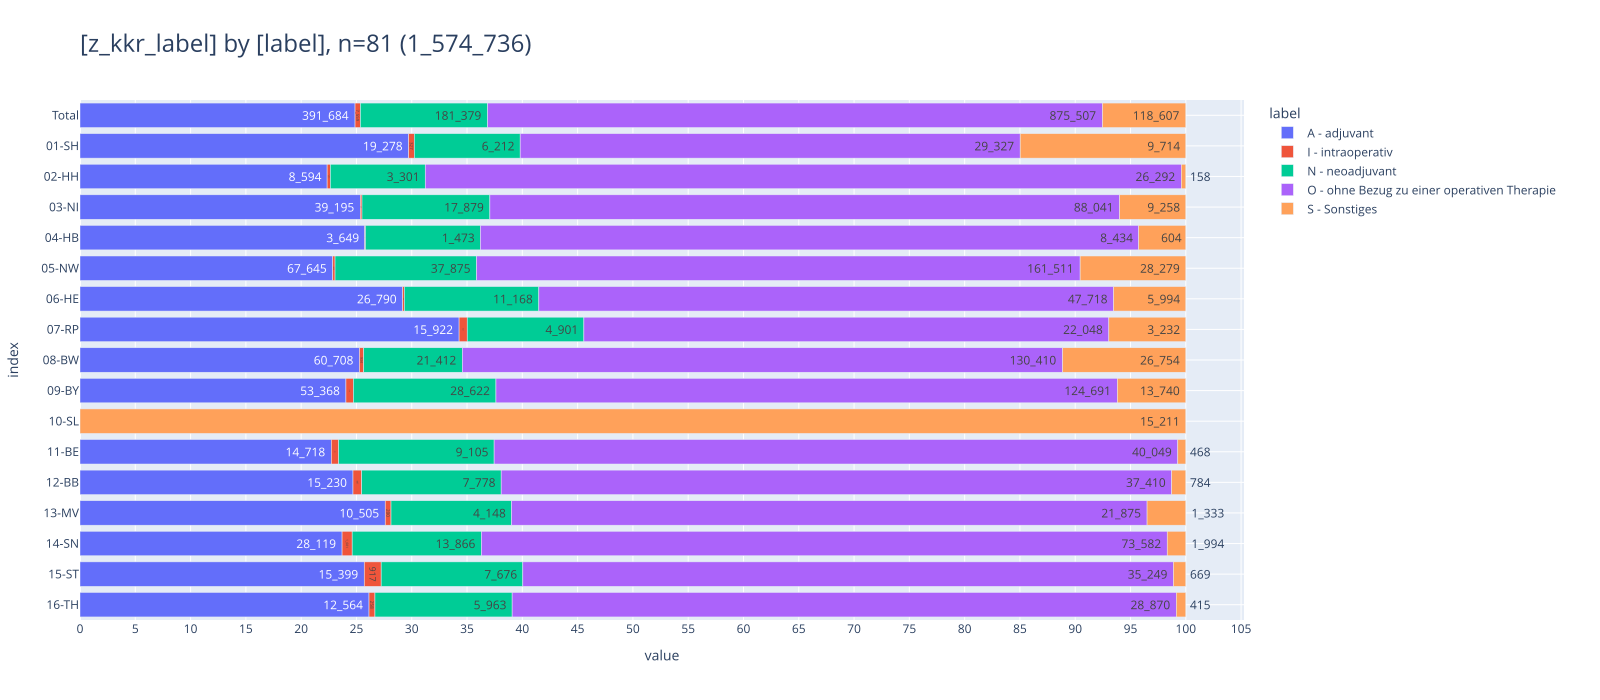

In [38]:
_syst = (SYST
    .join(Tumor.set_alias("t"), "z_tum_id")
    .aggregate("Stellung_OP, t.z_kkr_label, count(*) as cnt")
    .join(dim_syst_op_stellung.set_alias("s"), "Stellung_OP=s.code")
    .project("z_kkr_label,concat(s.code, ' -  ', s.name) as label, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_syst, orientation="h", height=700, top_n_color=0, relative=True, show_total=True)

<div style="page-break-after: always;"></div>

## <a id='toc1_10_'></a>[Missings- und Unbekannt-Kodierungen](#toc0_)
- es sind folgende Schwellwerte angezeigt:
  - 🟩 0 bis <5%
  - 🟨 **missings**: 5% bis <100% | **unbekannt**: 5% bis <35%>
  - 🟥 **missings**: bei 100% | **unbekannt** >= 35%
- dargestellt sind Variablen aus dem Schema in folgender Notation: `[Elementknoten]Variablenname`
- die graumelierte `0` kennzeichnet einen leeren Wert (=keine missings), 0% entsteht durch Rundung von kleinen Werten
- `Total` 
  - ist als Spalte neu eingefügt, und bildet den Anteil von missings bzw unbekannt deutschlandweit ab
  - ⚠️ verliert an Aussagekraft, wenn aus KKR keine Daten vorliegen für diese Variable (100% missings), der Wert wirkt dann geschönt

**unbekannt**
- bei 100% missings wird auch unbekannt auf 100% gesetzt
- Beispiele für gewertete Unbekannt-Kodierungen:
  - `Diagnosesicherung` = 9
  - `Seitenlokalisation` = U
  - `Datumsgenauigkeit` in ('M','V')
- der Quellcode zur Bestimmung von `Unbekannt` Kodierungen ist hier abrufbar: [sql](sql/check_if_unknown.sql)

In [106]:
with open("../sql/check_if_unknown.sql") as f:
    _macro_check_if_unknown = f.read()
_=con.execute(_macro_check_if_unknown)

In [40]:
def show_missings2(
    filter_col: str,
    filter_row: str = "true",
    use_unknown: bool = False,
    show_filter: bool = False,
    debug: bool = False,
):
    """
    filter_col: filter for columns  
    filter_row: filter for tablerows  
    use_unknown: show unknowns instead of missings  
    print_filter: print filter string  
    debug: show debug info  
    
    hint for filter_col:
    ```python
    regexp_matches(tablecolumn, 'atem|radio|geschl|inzidenz|Anzahl_Tage_Diagnose_OP','i')
    ```
    or
    ```python
    table = 'OPS'
    ```
    
    or

    ['sel3_TNM',
    'sel4_datum',
    'sel5_pflicht',
    'sel6_mamma',
    'sel7_prostata',
    'sel8_prio',
    'sel9_darm',
    'sel10_melanom',
    'sel11_fo',
    'sel12_free',
    'sel13_unknown']

    """
    # * get all columns and tables
    items = (dim_tree
        # .filter("regexp_matches(tablecolumn, 'atem|radio|geschl|inzidenz|Anzahl_Tage_Diagnose_OP','i')")
        .filter(filter_col)
        .project("""--sql
            tablecolumn,
            regexp_extract(tablecolumn, '\](.*)', 1) as col_name,
            tables,
        """)
        .to_df()
        .to_dict()
    )
    if debug:
        print(items)

    # * create empty df
    df_missings_all = pd.DataFrame()

    for col, tab, col_name in zip(items["tablecolumn"].values(), items["tables"].values(), items["col_name"].values()):

        # * create stub, care for the unclosed brackets (closing in query_1)
        query_0 = (f"""--sql
            with t1 as (
                select
                    (ifnull(t_1.{col_name}::text, '') = '') as is_missing,
                    mem.fx_check_if_unknown(t_1.{col_name}, '{col_name}') AS is_unknown,
                    t_1.z_kkr as z_kkr,
                from {tab} t_1
                
        """)

        # ! use extra query for patient oriented tables, join is different here
        if tab in ('Patient', 'Todesursache'):
            query_1 = (f"""--sql
                where oBDS_RKIPatientId in
                    -- avoid join to not have a table prefix like "tum.", to reuse the filter
                    (select z_pat_id from Tumor where {filter_row})
            ),
            """)
        else:
            query_1 = (f"""--sql
                where z_tum_id in (select z_tum_id from Tumor where {filter_row})
            ),
            """)
            
        # ! use extra metrics for unknown. missings / unknown -> invalid
        if not use_unknown:
            query_2 = ("""--sql
                t2 as (
                    select
                        is_missing as is_invalid,
                        z_kkr,
                        count(*)::int as cnt,
                    from t1
                    group by is_missing,z_kkr
                ),
            """)
        else:
            query_2 = ("""--sql
                t2 as (
                    select
                        is_unknown as is_invalid,
                        z_kkr,
                        case
                            -- check if there are any rows at all
                            -- if not, return 0, which makes nonexisting data also unknown
                            when count(*) filter (not is_missing) = 0 then 0
                            else count(*)::int
                        end as cnt,
                    from t1
                    group by is_unknown,z_kkr
                ),
            """)

        query_rest = (f"""--sql
            t3 as (
                select
                    *,
                    sum(cnt) over (partition by z_kkr) as cnt_all,
                from t2
                order by z_kkr
            ),
            t4 as (
                select
                    z_kkr,
                    cnt as cnt_valid,
                    cnt_all,
                from t3
                where not is_invalid
                -- filter for the **valid** rows
                -- these can be better distinguished from non existing data

                -- ! TOTALS can be activated here. problem is, non existing data bias the total
                -- when kkr dont have any data, total looks fine. this is not intuitive!

                -- now calc the total. must be on t2 since t3 is filtered
                union
                select
                    -- 0 = Total
                    0 as z_kkr,
                    -- sum all cnt but only for the valid
                    sum(cnt) filter (not is_invalid) as cnt_valid,
                    -- sum all cnt
                    sum(cnt) as cnt_all
                from t2
            ),
            t5 as (
                select
                    '{col}' as col,
                    kkr as z_kkr,
                    cnt_valid,
                    cnt_all,
                    case
                        -- no data at all -> 100% (red)
                        when ifnull(cnt_all,0) = 0 then 1
                        -- calculate diff to 100%. empty valids -> 0
                        else 1 - coalesce(cnt_valid/cnt_all::float,0)
                    end as pct_invalid
                from t4
                -- fill up non existing data
                right join dim_lieferregister on z_kkr = code
                --where kkr <> 'Total'
            )
            select * from t5
        """)

        query = query_0 + query_1 + query_2 + query_rest
        # print(query)
        db_missings = con.sql(query)
                
        df_missings = db_missings.to_df()

        if df_missings_all.empty:
            df_missings_all = df_missings
        else:
            df_missings_all = pd.concat([df_missings_all, df_missings], axis=0)

    # * debug
    # con.from_df(df_missings_all).filter("z_kkr <> 0").sum("cnt_all").show()
    # return df_missings_all.sort_values(["z_kkr"])#["cnt_invalid"].sum()

    if debug:
        print(query)
        display(df_missings_all.sort_values(["col","z_kkr"]))

    if filter_row != "true" and show_filter:
        hlp.print_filter(filter_row)

    if use_unknown:
        print("🟠 unknowns")
    else:
        print("🟠 missings")
    

    display(tbl.pivot_df(
        df_missings_all[["col","z_kkr","pct_invalid"]],
        total_axis="",
        precision=1,
        show_as_pct=True,
        pct_axis="",
        # kkr_col="z_kkr",
        # swap=True,
        kpi_mode="rag_abs",
        kpi_rag_list=[0.05,1] if not use_unknown else [0.05, 0.35],
        )
    )

# show_missings2(
#     # filter_col="sel5_pflicht",
#     # filter_col="tables = 'Todesursache'",
#     filter_col="""--sql
#         regexp_matches(tablecolumn, 'Anzahl_Tage_SYST_Dauer','i')""",
#     # filter_col="""--sql
#     #     regexp_matches(tablecolumn, 'Anzahl_Tage_Diagnose_OP','i')""",
#     filter_row = FIL_DY_NO_DCO_C44,
#     use_unknown=True,
#     # show_filter=True,
#     # debug=True,
# )

<br>

### <a id='toc1_10_1_'></a>[Verpflichtende Tumorvariablen](#toc0_)
- kein Filter
- Pflichtangaben aus anderen Elementknoten (z.B. Datum aus dem OP Knoten) sind nicht aufgeführt, da diese selbst optional sind

> 💡 `ZfKD`: _Pflichtfelder sind nahezu komplett vorhanden, die wenigen Ausnahmen werden allerdings Stand heute nicht korrigiert_

> 💡 `ZfKD`: _`Gesamtbeurteilung_Tumorstatus`ist zwar vollständig geliefert (siehe vorherige Grafiken), aber häufig als Unbekannt kodiert. Viele Pflichtvariablen haben keine Unbekannt Kodes, etwas auffällig sind hier `Diagnosesicherung` und `Seitenlokalisation`. Ähnlich auch `Morphologie` (kein Pflichtfeld)._ 


In [41]:
hlp.print_filter(FILTER_DY)

show_missings2(
    filter_col="sel5_pflicht",
    filter_row = FILTER_DY,
    # use_unknown=True,
    # show_filter=True,
    # debug=True,
)

show_missings2(
    filter_col="sel5_pflicht",
    filter_row = FILTER_DY,
    use_unknown=True,
    # show_filter=True,
    # debug=True,
)

<!-- START_TOKEN -->

# filter
z_dy between 2020 and 2024


<!-- END_TOKEN -->

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Patient]Datum_Vitalstatus,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geburtsdatum,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geschlecht,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Verstorben,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]DCN,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Diagnose_ICD10_Code,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩
[Tumor]Diagnosedatum,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Diagnosesicherung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Inzidenzort,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,1.0% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Patient]Datum_Vitalstatus,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0 🟩,1.2% 🟩,0.2% 🟩,0 🟩,0.2% 🟩,0.2% 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,0.3% 🟩,0.2% 🟩
[Patient]Geburtsdatum,0 🟩,0 🟩,0 🟩,0 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩
[Patient]Geschlecht,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩
[Patient]Verstorben,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]DCN,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Diagnose_ICD10_Code,1.1% 🟩,1.4% 🟩,1.4% 🟩,1.6% 🟩,1.0% 🟩,1.0% 🟩,1.1% 🟩,1.4% 🟩,1.7% 🟩,1.2% 🟩,1.8% 🟩,1.9% 🟩,1.1% 🟩,1.1% 🟩,1.7% 🟩,1.6% 🟩,1.3% 🟩
[Tumor]Diagnosedatum,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Diagnosesicherung,2.8% 🟩,6.5% 🟨,6.2% 🟨,1.4% 🟩,4.9% 🟩,2.3% 🟩,18.5% 🟨,9.5% 🟨,1.1% 🟩,21.4% 🟨,0.8% 🟩,0.7% 🟩,0.9% 🟩,0.1% 🟩,0.6% 🟩,2.0% 🟩,4.7% 🟩
[Tumor]Inzidenzort,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩


### <a id='toc1_10_2_'></a>[Weitere Tumorangaben](#toc0_)

In [42]:
_fil = """--sql
    tablecolumn in (
        --'[Tumor]Diagnosesicherung',
        --'[Tumor]T_p',
        --'[Tumor]UICC_Stadium_p',
        '[Tumor]Morphologie_Code',
        --'[Tumor]Diagnosedatum_Genauigkeit',
        '[Tumor]Topographie_Code',
        '[Tumor]Grading',
)"""

hlp.print_filter(FILTER_DY_NO_DCO_NO_C44)

show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    # use_unknown=True,
    # show_filter=True,
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    use_unknown=True,
    # show_filter=True,
    # debug=True,
)

<!-- START_TOKEN -->

# filter

    z_dy between 2020 and 2024
    and not z_is_dco
    and z_icd10_3d not in ('C44','D04')



<!-- END_TOKEN -->

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]Grading,0 🟩,0 🟩,4.6% 🟩,0 🟩,0 🟩,1.3% 🟩,10.1% 🟨,0 🟩,2.2% 🟩,0 🟩,0.1% 🟩,0.2% 🟩,0.0% 🟩,0.0% 🟩,0.4% 🟩,1.3% 🟩,1.4% 🟩
[Tumor]Morphologie_Code,0 🟩,0 🟩,4.6% 🟩,0 🟩,0 🟩,1.3% 🟩,10.1% 🟨,0 🟩,2.2% 🟩,0 🟩,0.1% 🟩,0.2% 🟩,0.0% 🟩,0.0% 🟩,0.4% 🟩,1.3% 🟩,1.4% 🟩
[Tumor]Topographie_Code,0 🟩,0.0% 🟩,1.6% 🟩,0 🟩,0 🟩,0.0% 🟩,2.7% 🟩,0.2% 🟩,0.1% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.3% 🟩,0.0% 🟩,0.0% 🟩,1.0% 🟩,0.4% 🟩


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]Grading,36.0% 🟥,56.0% 🟥,40.2% 🟥,32.2% 🟨,39.7% 🟥,46.3% 🟥,30.4% 🟨,50.5% 🟥,46.3% 🟥,36.3% 🟥,46.1% 🟥,46.6% 🟥,41.0% 🟥,46.8% 🟥,36.3% 🟥,33.3% 🟨,42.9% 🟥
[Tumor]Morphologie_Code,4.6% 🟩,6.0% 🟨,1.4% 🟩,4.3% 🟩,6.8% 🟨,1.8% 🟩,2.3% 🟩,8.6% 🟨,1.2% 🟩,4.2% 🟩,4.3% 🟩,3.3% 🟩,2.9% 🟩,3.8% 🟩,3.7% 🟩,2.7% 🟩,4.3% 🟩
[Tumor]Topographie_Code,1.4% 🟩,2.0% 🟩,1.7% 🟩,2.0% 🟩,1.8% 🟩,1.2% 🟩,1.5% 🟩,2.5% 🟩,1.6% 🟩,1.7% 🟩,1.8% 🟩,1.8% 🟩,1.7% 🟩,1.9% 🟩,1.8% 🟩,1.7% 🟩,1.8% 🟩


<br>

### <a id='toc1_10_3_'></a>[Tumorstadien](#toc0_)
- **Filter: `DJ` 2020-2024, `DCO` = N, `ICD10` nur solide Tumoren**

> 💡 `ZfKD`: _"`05-NW` hat die Auflage als Konstante im Datensatz hinterlegt"_

In [43]:
_fil = """--sql
    sel3_TNM
"""

_fil_row = f"""
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and {FILTER_TNM}
"""

hlp.print_filter(_fil_row)

show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    # use_unknown=True,
    # show_filter=True
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    use_unknown=True,
    # show_filter=True,
    # debug=True,
)

<!-- START_TOKEN -->

# filter

    z_dy between 2020 and 2024
    and not z_is_dco
    and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )




<!-- END_TOKEN -->

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]M_c,38.4% 🟨,21.6% 🟨,52.3% 🟨,28.7% 🟨,24.6% 🟨,53.9% 🟨,68.8% 🟨,41.2% 🟨,52.7% 🟨,29.9% 🟨,34.1% 🟨,39.6% 🟨,34.5% 🟨,32.5% 🟨,42.9% 🟨,45.8% 🟨,41.0% 🟨
[Tumor]M_p,43.3% 🟨,93.2% 🟨,51.0% 🟨,44.7% 🟨,91.2% 🟨,56.2% 🟨,52.2% 🟨,47.4% 🟨,57.1% 🟨,90.6% 🟨,46.6% 🟨,48.9% 🟨,45.4% 🟨,39.9% 🟨,46.2% 🟨,45.4% 🟨,60.4% 🟨
[Tumor]N_c,37.6% 🟨,34.6% 🟨,50.5% 🟨,28.6% 🟨,36.5% 🟨,52.1% 🟨,70.1% 🟨,45.1% 🟨,51.1% 🟨,40.4% 🟨,32.7% 🟨,38.3% 🟨,34.3% 🟨,32.5% 🟨,43.8% 🟨,45.3% 🟨,43.9% 🟨
[Tumor]N_p,36.7% 🟨,60.0% 🟨,43.4% 🟨,42.4% 🟨,56.0% 🟨,45.5% 🟨,50.1% 🟨,61.8% 🟨,44.1% 🟨,53.5% 🟨,43.7% 🟨,45.1% 🟨,42.2% 🟨,39.7% 🟨,45.4% 🟨,43.9% 🟨,49.3% 🟨
[Tumor]TNM_Auflage_c,36.3% 🟨,16.4% 🟨,48.0% 🟨,26.3% 🟨,0 🟩,47.2% 🟨,63.3% 🟨,41.2% 🟨,46.5% 🟨,24.2% 🟨,29.7% 🟨,32.7% 🟨,31.2% 🟨,32.2% 🟨,40.4% 🟨,43.4% 🟨,32.6% 🟨
[Tumor]TNM_Auflage_p,34.4% 🟨,38.0% 🟨,37.8% 🟨,41.1% 🟨,0 🟩,40.4% 🟨,46.9% 🟨,47.3% 🟨,37.2% 🟨,30.9% 🟨,40.6% 🟨,41.4% 🟨,38.7% 🟨,39.5% 🟨,43.9% 🟨,42.1% 🟨,31.8% 🟨
[Tumor]T_c,37.3% 🟨,42.5% 🟨,47.5% 🟨,27.3% 🟨,42.3% 🟨,47.2% 🟨,64.1% 🟨,41.2% 🟨,46.5% 🟨,45.6% 🟨,29.7% 🟨,32.7% 🟨,31.2% 🟨,32.2% 🟨,40.4% 🟨,43.4% 🟨,42.7% 🟨
[Tumor]T_p,34.6% 🟨,43.2% 🟨,37.7% 🟨,41.1% 🟨,42.6% 🟨,40.4% 🟨,46.9% 🟨,47.3% 🟨,37.2% 🟨,39.9% 🟨,40.6% 🟨,41.4% 🟨,38.7% 🟨,39.5% 🟨,43.9% 🟨,42.1% 🟨,41.3% 🟨
[Tumor]UICC_Stadium_c,47.2% 🟨,45.0% 🟨,100.0% 🟨,30.7% 🟨,100.0% 🟥,57.8% 🟨,75.7% 🟨,49.0% 🟨,56.1% 🟨,87.1% 🟨,42.4% 🟨,49.2% 🟨,40.0% 🟨,34.8% 🟨,45.1% 🟨,50.2% 🟨,66.7% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]M_c,0 🟩,0.1% 🟩,0 🟩,0 🟩,1.2% 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,2.0% 🟩,3.9% 🟩,1.1% 🟩,0.1% 🟩,0.2% 🟩,0.4% 🟩,0.5% 🟩
[Tumor]M_p,0 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,3.4% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,1.2% 🟩,1.6% 🟩,0.8% 🟩,0.1% 🟩,0.3% 🟩,0.6% 🟩,0.9% 🟩
[Tumor]N_c,11.2% 🟨,2.5% 🟩,5.9% 🟨,5.3% 🟨,9.1% 🟨,4.3% 🟩,6.0% 🟨,3.8% 🟩,3.2% 🟩,5.8% 🟨,8.3% 🟨,8.2% 🟨,6.3% 🟨,4.3% 🟩,3.6% 🟩,4.3% 🟩,5.9% 🟨
[Tumor]N_p,11.4% 🟨,2.2% 🟩,2.4% 🟩,1.8% 🟩,4.1% 🟩,3.1% 🟩,4.9% 🟩,1.1% 🟩,2.8% 🟩,3.0% 🟩,3.1% 🟩,3.4% 🟩,2.2% 🟩,0.5% 🟩,1.1% 🟩,1.9% 🟩,3.1% 🟩
[Tumor]TNM_Auflage_c,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]TNM_Auflage_p,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]T_c,7.3% 🟨,2.1% 🟩,4.0% 🟩,4.2% 🟩,8.0% 🟨,3.6% 🟩,7.1% 🟨,4.5% 🟩,2.4% 🟩,4.1% 🟩,6.1% 🟨,5.3% 🟨,6.7% 🟨,5.3% 🟨,4.1% 🟩,4.0% 🟩,5.2% 🟨
[Tumor]T_p,7.7% 🟨,1.0% 🟩,0.2% 🟩,0.2% 🟩,1.5% 🟩,0.3% 🟩,0.7% 🟩,0.4% 🟩,0.1% 🟩,0.8% 🟩,0.3% 🟩,0.2% 🟩,0.6% 🟩,0.1% 🟩,0.2% 🟩,0.2% 🟩,0.9% 🟩
[Tumor]UICC_Stadium_c,0.0% 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩


<br>

### <a id='toc1_10_4_'></a>[Therapieangaben](#toc0_)
- **Filter: `DJ` 2020-2024, `DCO` = N, `ICD10` != C44**
- fiktives Rechenbeispiel für `[Bestrahlung]Anzahl_Tage_Diagnose_ST`:
  - 5363 Bestrahlungen sind in den 01-SH Daten unter Beachtung des Filters (DCO/DJ/ICD10) für den zugeordneten Tumor
  - davon enthalten 302 ein leeres Feld `Anzahl_Tage_Diagnose_ST` -> ~ 6%

#### <a id='toc1_10_4_1_'></a>[OP](#toc0_)

> 💡 `ZfKD`: _Für überlieferte OP liegen `Datum_OP` und `Intention` komplett vollständig vor. Der Tagesabstand hat wenige Lücken, während `Lokale_Beurteilung_Residualstatus` auch ausserhalb von Tristan erkennbar häufiger fehlt._

In [44]:
_fil = """--sql
tables = 'OP' and tablecolumn not ilike '%genauigkeit'
"""

show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    # use_unknown=True,
    # show_filter=True,
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    use_unknown=True,
    # show_filter=True,
    # debug=True,
)

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[OP]Anzahl_Tage_Diagnose_OP,1.4% 🟩,0 🟩,2.4% 🟩,2.9% 🟩,2.8% 🟩,0 🟩,5.2% 🟨,2.3% 🟩,0.0% 🟩,2.7% 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,1.4% 🟩
[OP]Datum_OP,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[OP]Intention,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[OP]Lokale_Beurteilung_Residualstatus,100.0% 🟥,4.1% 🟩,100.0% 🟥,100.0% 🟥,7.9% 🟨,10.2% 🟨,1.9% 🟩,0.0% 🟩,12.8% 🟨,100.0% 🟥,10.7% 🟨,11.0% 🟨,5.0% 🟩,6.8% 🟨,17.0% 🟨,17.6% 🟨,18.1% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[OP]Anzahl_Tage_Diagnose_OP,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[OP]Datum_OP,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0 🟩,0.9% 🟩,0 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩
[OP]Intention,2.5% 🟩,0.6% 🟩,1.2% 🟩,1.6% 🟩,3.2% 🟩,1.8% 🟩,1.3% 🟩,1.2% 🟩,13.5% 🟨,3.3% 🟩,0.3% 🟩,0.9% 🟩,0.5% 🟩,1.1% 🟩,0.8% 🟩,2.0% 🟩,3.6% 🟩
[OP]Lokale_Beurteilung_Residualstatus,100.0% 🟥,0.4% 🟩,100.0% 🟥,100.0% 🟥,3.0% 🟩,0 🟩,1.4% 🟩,13.1% 🟨,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,2.8% 🟩


#### <a id='toc1_10_4_2_'></a>[ST](#toc0_)

> 💡 `ZfKD`: _`Datum_Beginn_Bestrahlung` und `Intention` sind nahezu komplett verfügbar in den dokumentierten ST / Bestrahlungen, mit Abstrichen auch `Anzahl_Tage_Diagnose_ST`._  
> _`Anzahl_Tage_ST_Dauer` und `Stellung_OP` fehlen bei Tristan_  
> _`Applikationsart` wird nicht von allen kkr übermittelt, davon abgesehen ist `Seite_Zielgebiet` zuverlässig angegeben, die CodeVersionen ergänzen sich, wobei `2014` deutlich häufiger angewendet wird als `2021`._

In [45]:
_filter = """--sql
        tablecolumn not ilike '%genauigkeit'
        and (
            tables in ('ST', 'Bestrahlung')
            or regexp_matches(tablecolumn,'codeversion|zielgebiet','i')
)"""

show_missings2(
    filter_col=_filter,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    # use_unknown=True,
    # show_filter=
    # debug=True,
)
show_missings2(
    filter_col=_filter,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    use_unknown=True,
    # show_filter=
    # debug=True,
)

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Applikationsart]CodeVersion2014,100.0% 🟥,56.9% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,20.8% 🟨,36.9% 🟨,36.8% 🟨,25.5% 🟨,100.0% 🟥,30.7% 🟨,27.3% 🟨,0.4% 🟩,52.2% 🟨,35.5% 🟨,38.9% 🟨,46.0% 🟨
[Applikationsart]CodeVersion2021,100.0% 🟥,43.1% 🟨,100.0% 🟥,100.0% 🟥,0 🟩,79.3% 🟨,63.1% 🟨,64.3% 🟨,76.4% 🟨,100.0% 🟥,69.7% 🟨,72.8% 🟨,99.7% 🟨,48.2% 🟨,64.5% 🟨,61.5% 🟨,54.6% 🟨
[Applikationsart]Seite_Zielgebiet,100.0% 🟥,0.0% 🟩,100.0% 🟥,100.0% 🟥,0.7% 🟩,0.0% 🟩,0 🟩,1.1% 🟩,1.0% 🟩,100.0% 🟥,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.4% 🟩,0.0% 🟩,0.4% 🟩,0.5% 🟩
[Bestrahlung]Anzahl_Tage_Bestrahlung_Dauer,100.0% 🟥,2.5% 🟩,100.0% 🟥,100.0% 🟥,8.5% 🟨,4.6% 🟩,14.7% 🟨,0.0% 🟩,3.6% 🟩,5.4% 🟨,1.4% 🟩,1.3% 🟩,0.0% 🟩,0.3% 🟩,1.3% 🟩,1.7% 🟩,14.5% 🟨
[Bestrahlung]Anzahl_Tage_Diagnose_Bestrahlung,3.9% 🟩,0 🟩,5.4% 🟨,6.2% 🟨,100.0% 🟥,0 🟩,9.1% 🟨,0.1% 🟩,0.1% 🟩,100.0% 🟥,0.0% 🟩,0.0% 🟩,1.9% 🟩,0 🟩,0.0% 🟩,0 🟩,19.1% 🟨
[Bestrahlung]Datum_Beginn_Bestrahlung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩
[ST]Intention,0 🟩,0 🟩,0.3% 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩,0.0% 🟩,0 🟩,2.6% 🟩,0 🟩,0.3% 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.9% 🟩,0.5% 🟩
[ST]Stellung_OP,100.0% 🟥,0.0% 🟩,100.0% 🟥,100.0% 🟥,0.9% 🟩,0.6% 🟩,0.2% 🟩,0 🟩,2.8% 🟩,100.0% 🟥,0.0% 🟩,0.0% 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,1.6% 🟩,14.6% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Applikationsart]CodeVersion2014,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Applikationsart]CodeVersion2021,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Applikationsart]Seite_Zielgebiet,100.0% 🟥,12.6% 🟨,100.0% 🟥,100.0% 🟥,28.0% 🟨,17.5% 🟨,7.2% 🟨,21.0% 🟨,15.0% 🟨,100.0% 🟥,26.4% 🟨,27.2% 🟨,20.6% 🟨,20.8% 🟨,17.2% 🟨,31.9% 🟨,20.2% 🟨
[Bestrahlung]Anzahl_Tage_Bestrahlung_Dauer,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Bestrahlung]Anzahl_Tage_Diagnose_Bestrahlung,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Bestrahlung]Datum_Beginn_Bestrahlung,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0 🟩,0.1% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩
[ST]Intention,0.5% 🟩,0.7% 🟩,2.1% 🟩,0.6% 🟩,2.1% 🟩,1.3% 🟩,0.9% 🟩,0.8% 🟩,1.1% 🟩,6.1% 🟨,0.8% 🟩,0.6% 🟩,0.2% 🟩,2.4% 🟩,0.9% 🟩,1.3% 🟩,1.3% 🟩
[ST]Stellung_OP,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


#### <a id='toc1_10_4_3_'></a>[SYST](#toc0_)

> 💡 `ZfKD`: _Die meisten Angaben im SYST Element liegen komplett vor. `Anzahl_Tage_SYST_Dauer` fehlt häufig, was auch an noch nicht abgeschlossenen Therapien liegen könnte - wohingegen `08-BW` hier als einzige keine missings ausweisen._

In [46]:
_fil = """--sql
tables in ('SYST') and tablecolumn not ilike '%genauigkeit'
"""

show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    # use_unknown=True,
    # show_filter=
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    use_unknown=True,
    # show_filter=
    # debug=True,
)

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[SYST]Anzahl_Tage_Diagnose_SYST,5.4% 🟨,0 🟩,8.9% 🟨,13.5% 🟨,1.0% 🟩,0 🟩,15.9% 🟨,0.3% 🟩,0.1% 🟩,13.3% 🟨,0.0% 🟩,0.0% 🟩,0.1% 🟩,0 🟩,0 🟩,0.0% 🟩,2.1% 🟩
[SYST]Anzahl_Tage_SYST_Dauer,35.2% 🟨,28.4% 🟨,42.6% 🟨,36.2% 🟨,43.8% 🟨,36.0% 🟨,59.1% 🟨,34.7% 🟨,42.0% 🟨,100.0% 🟥,32.1% 🟨,40.2% 🟨,37.3% 🟨,33.4% 🟨,40.1% 🟨,36.7% 🟨,39.9% 🟨
[SYST]Datum_Beginn_SYST,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Intention,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Stellung_OP,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Therapieart,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[SYST]Anzahl_Tage_Diagnose_SYST,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Anzahl_Tage_SYST_Dauer,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Datum_Beginn_SYST,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.4% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.5% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩,0.3% 🟩,0.7% 🟩,0.2% 🟩,0.2% 🟩
[SYST]Intention,8.3% 🟨,0.7% 🟩,2.9% 🟩,1.3% 🟩,4.7% 🟩,2.4% 🟩,2.5% 🟩,3.2% 🟩,6.8% 🟨,30.5% 🟨,1.2% 🟩,2.7% 🟩,0.8% 🟩,3.9% 🟩,1.3% 🟩,1.6% 🟩,4.1% 🟩
[SYST]Stellung_OP,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Therapieart,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


### <a id='toc1_10_5_'></a>[Folgeereignisse](#toc0_)

> 💡 `ZfKD`: _`Datum_Folgeereignis` und `Gesamtbeurteilung_Tumorstatus` liegen komplett vor, die anderen Angaben zum Tumorstatus allerdings nicht. Angaben für `Folgeereignis_TNM` fehlen ganz überwiegend, auch wenn Folgereignisse keine TNM enthalten müssen. Die Erkennung von Rezidiven ist so deutlich erschwert._

In [47]:
_fil = """--sql
tablecolumn not ilike '%genauigkeit' and sel11_fo
"""

show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    # use_unknown=True,
    # show_filter=
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    use_unknown=True,
    # show_filter=
    # debug=True,
)

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Folgeereignis]Datum_Folgeereignis,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Folgeereignis]Gesamtbeurteilung_Tumorstatus,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Folgeereignis]Verlauf_Lokaler_Tumorstatus,48.1% 🟨,57.6% 🟨,56.0% 🟨,53.4% 🟨,22.4% 🟨,30.5% 🟨,0 🟩,0 🟩,34.7% 🟨,100.0% 🟥,31.2% 🟨,30.1% 🟨,28.3% 🟨,27.4% 🟨,17.5% 🟨,22.0% 🟨,17.2% 🟨
[Folgeereignis]Verlauf_Tumorstatus_Fernmetastasen,47.6% 🟨,57.6% 🟨,54.3% 🟨,52.7% 🟨,23.5% 🟨,32.5% 🟨,6.1% 🟨,0 🟩,37.0% 🟨,100.0% 🟥,29.5% 🟨,29.1% 🟨,30.8% 🟨,26.1% 🟨,16.3% 🟨,23.5% 🟨,18.3% 🟨
[Folgeereignis]Verlauf_Tumorstatus_Lymphknoten,81.8% 🟨,57.9% 🟨,84.2% 🟨,82.2% 🟨,24.2% 🟨,35.6% 🟨,0 🟩,0 🟩,41.5% 🟨,100.0% 🟥,35.4% 🟨,35.3% 🟨,32.4% 🟨,31.8% 🟨,19.1% 🟨,27.9% 🟨,20.0% 🟨
[Folgeereignis_TNM]T,100.0% 🟥,52.8% 🟨,100.0% 🟥,100.0% 🟥,93.0% 🟨,89.2% 🟨,98.2% 🟨,98.4% 🟨,82.4% 🟨,100.0% 🟥,79.0% 🟨,84.1% 🟨,81.7% 🟨,91.4% 🟨,92.4% 🟨,88.7% 🟨,92.4% 🟨
[Folgeereignis_TNM]UICC_Stadium,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,95.6% 🟨,99.2% 🟨,99.0% 🟨,88.4% 🟨,100.0% 🟥,93.2% 🟨,94.3% 🟨,90.1% 🟨,89.9% 🟨,94.6% 🟨,94.7% 🟨,96.5% 🟨
[Folgeereignis_TNM]r_Symbol,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,99.2% 🟨,98.5% 🟨,100.0% 🟥,99.1% 🟨,96.7% 🟨,100.0% 🟥,97.4% 🟨,98.1% 🟨,99.1% 🟨,96.3% 🟨,99.0% 🟨,99.3% 🟨,98.7% 🟨
[Folgeereignis_TNM]y_Symbol,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,99.3% 🟨,98.9% 🟨,100.0% 🟨,99.8% 🟨,98.9% 🟨,100.0% 🟥,97.1% 🟨,98.2% 🟨,98.6% 🟨,99.1% 🟨,99.4% 🟨,99.3% 🟨,99.4% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Folgeereignis]Datum_Folgeereignis,0 🟩,0.0% 🟩,0 🟩,0 🟩,3.9% 🟩,0.0% 🟩,6.1% 🟨,0 🟩,0.2% 🟩,100.0% 🟥,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩,0.0% 🟩,1.5% 🟩
[Folgeereignis]Gesamtbeurteilung_Tumorstatus,0 🟩,0.1% 🟩,0 🟩,0 🟩,20.3% 🟨,24.1% 🟨,10.7% 🟨,2.8% 🟩,29.3% 🟨,100.0% 🟥,23.0% 🟨,17.7% 🟨,25.9% 🟨,14.4% 🟨,13.3% 🟨,19.0% 🟨,14.8% 🟨
[Folgeereignis]Verlauf_Lokaler_Tumorstatus,0 🟩,6.0% 🟨,0 🟩,0 🟩,17.6% 🟨,2.6% 🟩,14.2% 🟨,33.9% 🟨,7.1% 🟨,100.0% 🟥,3.3% 🟩,3.6% 🟩,2.7% 🟩,4.0% 🟩,4.6% 🟩,3.1% 🟩,16.1% 🟨
[Folgeereignis]Verlauf_Tumorstatus_Fernmetastasen,0 🟩,2.7% 🟩,0 🟩,0 🟩,17.9% 🟨,2.2% 🟩,10.8% 🟨,37.7% 🟥,8.1% 🟨,100.0% 🟥,2.5% 🟩,3.1% 🟩,2.3% 🟩,2.8% 🟩,2.9% 🟩,2.0% 🟩,16.6% 🟨
[Folgeereignis]Verlauf_Tumorstatus_Lymphknoten,0 🟩,7.9% 🟨,0 🟩,0 🟩,19.3% 🟨,3.3% 🟩,17.8% 🟨,39.3% 🟥,10.0% 🟨,100.0% 🟥,4.5% 🟩,5.8% 🟨,3.6% 🟩,4.6% 🟩,5.2% 🟨,3.7% 🟩,18.8% 🟨
[Folgeereignis_TNM]T,100.0% 🟥,2.0% 🟩,100.0% 🟥,100.0% 🟥,0.7% 🟩,0.2% 🟩,0.4% 🟩,0.1% 🟩,0.2% 🟩,100.0% 🟥,1.8% 🟩,1.0% 🟩,0.4% 🟩,0.5% 🟩,0.4% 🟩,0.6% 🟩,0.4% 🟩
[Folgeereignis_TNM]UICC_Stadium,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,100.0% 🟥,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩
[Folgeereignis_TNM]r_Symbol,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Folgeereignis_TNM]y_Symbol,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


### <a id='toc1_10_6_'></a>[Freitexte](#toc0_)

> 💡 `ZfKD`: _Protokolle und Substanzen werden nach und nach in den Datensatz eingebunden. Protokolle bislang ausschliesslich als Freitext. Bei Substanzen komplementieren sich Freitexte und Kodierungen, bei vielen GTDS Ländern überwiegen inzwischen die Kodierungen._


In [48]:
_fil = """--sql
not regexp_matches(tablecolumn,'genauigkeit','i') and sel12_free
"""

show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    # use_unknown=True,
    # show_filter=True,
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = FILTER_DY_NO_DCO_NO_C44,
    use_unknown=True,
    # show_filter=True,
    # debug=True,
)

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Protokoll]Bezeichnung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩
[Protokoll]Protokoll_TypProtokollschluessel_Code,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥
[Substanz]Bezeichnung,98.6% 🟨,0 🟩,99.2% 🟨,99.2% 🟨,0 🟩,85.9% 🟨,0 🟩,0 🟩,48.3% 🟨,100.0% 🟥,91.4% 🟨,91.9% 🟨,0.1% 🟩,91.3% 🟨,80.9% 🟨,64.0% 🟨,44.8% 🟨
[Substanz]SYST_TypSubstanzATC_Code,1.4% 🟩,100.0% 🟥,0.8% 🟩,0.8% 🟩,100.0% 🟥,14.1% 🟨,100.0% 🟥,100.0% 🟥,51.7% 🟨,100.0% 🟥,8.6% 🟨,8.1% 🟨,100.0% 🟥,8.7% 🟨,19.1% 🟨,36.0% 🟨,55.2% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Protokoll]Bezeichnung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Protokoll]Protokoll_TypProtokollschluessel_Code,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥
[Substanz]Bezeichnung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Substanz]SYST_TypSubstanzATC_Code,0 🟩,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩


<br>

### <a id='toc1_10_7_'></a>[Organspezifische Variablen](#toc0_)
- die Prozentwerte sind bei allen Darstellungen gerundet, "100%" bei einer gelben Ampel kann interpretiert werden als knapp unter 100%
> 💡 `HH` _"Fehlende Modul-Angaben (C50, C61) 2021. Sind bei uns noch nicht im xml enthalten."_

<br>

#### <a id='toc1_10_7_1_'></a>[Mamma](#toc0_)
- **Filter: `DJ` 2020-2024, `DCO` = N, `ICD10` = C50**

In [49]:
_fil = """--sql
sel6_mamma
"""

_fil_row = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and z_icd10_3d = 'C50'
"""

hlp.print_filter(_fil_row)

show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    # use_unknown=True,
    # show_filter=
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    use_unknown=True,
    # show_filter=
    # debug=True,
)

<!-- START_TOKEN -->

# filter

    z_dy between 2020 and 2024
    and not z_is_dco
    and z_icd10_3d = 'C50'



<!-- END_TOKEN -->

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]Her2neuStatus,15.5% 🟨,100.0% 🟥,5.6% 🟨,0.2% 🟩,18.2% 🟨,18.1% 🟨,48.1% 🟨,11.6% 🟨,11.1% 🟨,5.7% 🟨,0.5% 🟩,0.9% 🟩,4.1% 🟩,0.9% 🟩,7.8% 🟨,14.0% 🟨,15.2% 🟨
[Tumor]HormonrezeptorStatus_Oestrogen,14.3% 🟨,100.0% 🟥,5.5% 🟨,0.2% 🟩,17.5% 🟨,17.7% 🟨,48.1% 🟨,11.4% 🟨,23.9% 🟨,5.4% 🟨,7.0% 🟨,8.3% 🟨,18.0% 🟨,3.0% 🟩,11.1% 🟨,12.8% 🟨,17.7% 🟨
[Tumor]HormonrezeptorStatus_Progesteron,14.3% 🟨,100.0% 🟥,5.5% 🟨,0.2% 🟩,17.5% 🟨,17.4% 🟨,48.1% 🟨,15.8% 🟨,23.9% 🟨,5.2% 🟨,7.1% 🟨,8.4% 🟨,18.0% 🟨,3.0% 🟩,11.2% 🟨,12.9% 🟨,18.4% 🟨
[Tumor]Praetherapeutischer_Menopausenstatus,21.1% 🟨,100.0% 🟥,34.7% 🟨,8.0% 🟨,31.4% 🟨,37.9% 🟨,54.0% 🟨,29.6% 🟨,37.4% 🟨,27.1% 🟨,23.6% 🟨,33.0% 🟨,24.1% 🟨,9.3% 🟨,37.4% 🟨,49.2% 🟨,34.0% 🟨
[Tumor]TumorgroesseDCIS,68.7% 🟨,100.0% 🟥,66.7% 🟨,34.3% 🟨,72.1% 🟨,80.9% 🟨,78.7% 🟨,54.8% 🟨,99.3% 🟨,68.4% 🟨,100.0% 🟨,99.9% 🟨,99.9% 🟨,100.0% 🟨,97.4% 🟨,100.0% 🟨,79.4% 🟨
[Tumor]TumorgroesseInvasiv,38.7% 🟨,100.0% 🟥,30.6% 🟨,20.5% 🟨,50.7% 🟨,55.6% 🟨,59.5% 🟨,33.2% 🟨,78.9% 🟨,26.6% 🟨,38.8% 🟨,41.1% 🟨,50.5% 🟨,24.4% 🟨,64.3% 🟨,56.5% 🟨,49.7% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]Her2neuStatus,1.9% 🟩,100.0% 🟥,1.6% 🟩,2.9% 🟩,3.0% 🟩,8.0% 🟨,4.0% 🟩,1.7% 🟩,8.1% 🟨,2.1% 🟩,8.2% 🟨,6.9% 🟨,11.9% 🟨,6.3% 🟨,14.9% 🟨,5.0% 🟨,4.8% 🟩
[Tumor]HormonrezeptorStatus_Oestrogen,0.7% 🟩,100.0% 🟥,0.7% 🟩,2.0% 🟩,1.4% 🟩,1.7% 🟩,1.7% 🟩,0.4% 🟩,0.1% 🟩,0.5% 🟩,2.6% 🟩,0.4% 🟩,0.4% 🟩,3.3% 🟩,0.5% 🟩,0.3% 🟩,1.0% 🟩
[Tumor]HormonrezeptorStatus_Progesteron,0.7% 🟩,100.0% 🟥,0.7% 🟩,2.0% 🟩,1.5% 🟩,2.3% 🟩,1.7% 🟩,0.4% 🟩,0.1% 🟩,0.8% 🟩,2.6% 🟩,0.5% 🟩,0.5% 🟩,3.3% 🟩,0.5% 🟩,0.4% 🟩,1.1% 🟩
[Tumor]Praetherapeutischer_Menopausenstatus,6.7% 🟨,100.0% 🟥,1.6% 🟩,0.9% 🟩,5.9% 🟨,1.6% 🟩,1.3% 🟩,1.0% 🟩,2.6% 🟩,8.1% 🟨,4.9% 🟩,6.1% 🟨,2.3% 🟩,3.3% 🟩,4.4% 🟩,0.9% 🟩,3.3% 🟩
[Tumor]TumorgroesseDCIS,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]TumorgroesseInvasiv,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


<br>

#### <a id='toc1_10_7_2_'></a>[Prostata](#toc0_)
- **Filter: `DJ` 2020-2024, `DCO` = N, `ICD10` = C61**

> 💡 `ZfKD` _Auch innerhalb eines KKR gibt es deutliche Varianzen zwischen Variablen des organspezifischen Moduls, z.B. in 11-16_

In [50]:
_fil = """--sql
sel7_prostata
"""

_fil_row = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and z_icd10_3d = 'C61'
"""

hlp.print_filter(_fil_row)

show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    # use_unknown=True,
    # show_filter=
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    use_unknown=True,
    # show_filter=
    # debug=True,
)

<!-- START_TOKEN -->

# filter

    z_dy between 2020 and 2024
    and not z_is_dco
    and z_icd10_3d = 'C61'



<!-- END_TOKEN -->

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]AnlassGleasonScore,17.5% 🟨,100.0% 🟥,9.8% 🟨,7.6% 🟨,36.5% 🟨,63.7% 🟨,66.8% 🟨,13.3% 🟨,29.7% 🟨,8.2% 🟨,42.8% 🟨,52.3% 🟨,40.3% 🟨,33.9% 🟨,66.0% 🟨,88.2% 🟨,35.9% 🟨
[Tumor]DatumPSA,41.4% 🟨,100.0% 🟥,40.9% 🟨,30.9% 🟨,0 🟩,43.7% 🟨,72.6% 🟨,95.3% 🟨,39.8% 🟨,27.4% 🟨,21.5% 🟨,21.2% 🟨,20.0% 🟨,12.8% 🟨,27.2% 🟨,25.4% 🟨,38.3% 🟨
[Tumor]PSA,41.3% 🟨,100.0% 🟥,40.5% 🟨,29.5% 🟨,30.8% 🟨,43.7% 🟨,66.7% 🟨,32.7% 🟨,39.8% 🟨,23.1% 🟨,21.5% 🟨,21.2% 🟨,20.0% 🟨,12.8% 🟨,27.2% 🟨,25.4% 🟨,35.6% 🟨
[Tumor]ScoreErgebnis,15.7% 🟨,100.0% 🟥,7.9% 🟨,7.4% 🟨,12.1% 🟨,23.0% 🟨,64.0% 🟨,10.1% 🟨,18.8% 🟨,4.1% 🟩,9.4% 🟨,9.5% 🟨,12.5% 🟨,4.2% 🟩,7.9% 🟨,18.9% 🟨,17.0% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]AnlassGleasonScore,2.1% 🟩,100.0% 🟥,0.8% 🟩,0.7% 🟩,0 🟩,0 🟩,0.4% 🟩,0.5% 🟩,6.4% 🟨,0.5% 🟩,3.2% 🟩,1.9% 🟩,0.2% 🟩,1.2% 🟩,0.7% 🟩,0.3% 🟩,1.6% 🟩
[Tumor]DatumPSA,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩
[Tumor]PSA,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]ScoreErgebnis,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


<br>

#### <a id='toc1_10_7_3_'></a>[Darm](#toc0_)
- **Filter: `DJ` 2020-2024, `DCO` = N, `ICD10` = C18-C20**

In [51]:
_fil = """--sql
sel9_darm
"""

_fil_row = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and z_icd10_3d in ('C18','C19','C20')
"""

hlp.print_filter(_fil_row)

show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    # use_unknown=True,
    # show_filter=
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    use_unknown=True,
    # show_filter=
    # debug=True,
)

<!-- START_TOKEN -->

# filter

    z_dy between 2020 and 2024
    and not z_is_dco
    and z_icd10_3d in ('C18','C19','C20')



<!-- END_TOKEN -->

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]RASMutation,53.2% 🟨,100.0% 🟥,65.0% 🟨,29.5% 🟨,73.8% 🟨,71.5% 🟨,87.4% 🟨,64.5% 🟨,80.2% 🟨,78.2% 🟨,64.9% 🟨,72.9% 🟨,64.1% 🟨,88.9% 🟨,93.5% 🟨,84.0% 🟨,73.9% 🟨
[Tumor]RektumAbstandAnokutanlinie,86.5% 🟨,100.0% 🟥,88.3% 🟨,86.7% 🟨,82.7% 🟨,81.1% 🟨,90.8% 🟨,82.4% 🟨,85.6% 🟨,83.2% 🟨,89.7% 🟨,84.5% 🟨,80.9% 🟨,77.2% 🟨,95.1% 🟨,91.1% 🟨,85.1% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]RASMutation,12.2% 🟨,100.0% 🟥,3.7% 🟩,12.2% 🟨,2.2% 🟩,2.8% 🟩,0.7% 🟩,2.7% 🟩,1.9% 🟩,4.2% 🟩,6.6% 🟨,2.1% 🟩,4.0% 🟩,1.0% 🟩,2.2% 🟩,1.9% 🟩,3.0% 🟩
[Tumor]RektumAbstandAnokutanlinie,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


<br>

#### <a id='toc1_10_7_4_'></a>[Melanom](#toc0_)
- **Filter: `DJ` 2020-2024, `DCO` = N, `ICD10` = C43**

In [52]:
_fil = """--sql
sel10_melanom
"""

_fil_row = f"""--sql
    {FILTER_DY}
    and {FILTER_NO_DCO}
    and z_icd10_3d = 'C43'
"""

# hlp.print_filter(_fil_row)

show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    # use_unknown=True,
    # show_filter=
    # debug=True,
)
show_missings2(
    filter_col=_fil,
    filter_row = _fil_row,
    use_unknown=True,
    # show_filter=
    # debug=True,
)

🟠 missings


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]LDH,98.0% 🟨,100.0% 🟥,93.8% 🟨,78.0% 🟨,84.3% 🟨,100.0% 🟥,98.3% 🟨,91.8% 🟨,100.0% 🟥,97.3% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,94.6% 🟨
[Tumor]Tumordicke,52.2% 🟨,100.0% 🟥,38.9% 🟨,17.5% 🟨,57.8% 🟨,100.0% 🟥,84.2% 🟨,17.3% 🟨,100.0% 🟥,46.0% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,68.3% 🟨
[Tumor]Ulzeration,58.5% 🟨,100.0% 🟥,56.4% 🟨,12.9% 🟨,71.6% 🟨,100.0% 🟥,87.0% 🟨,39.3% 🟨,100.0% 🟥,61.5% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,76.8% 🟨


🟠 unknowns


z_kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
col,,,,,,,,,,,,,,,,,
[Tumor]LDH,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,0 🟩
[Tumor]Tumordicke,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,0 🟩
[Tumor]Ulzeration,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,0 🟩


In [53]:
# show_missings(
#     kpi.MISSINGS.value,
#     filter=f"{fil_pd_dco_dy} and sel10_melanom and icd10_3d in ('C43')",
#     group_table=grouper_table.TABLECOL.value,
# )

## <a id='toc1_11_'></a>[🆕 Weitere Klassifikationen](#toc0_)

- Freitexte werden per regex in diesem [sql script](../sql/check_if_class.sql) zugeordnet

In [107]:
with open("../sql/check_if_class.sql") as f:
    _macro_check_if_class = f.read()
_=con.execute(_macro_check_if_class)

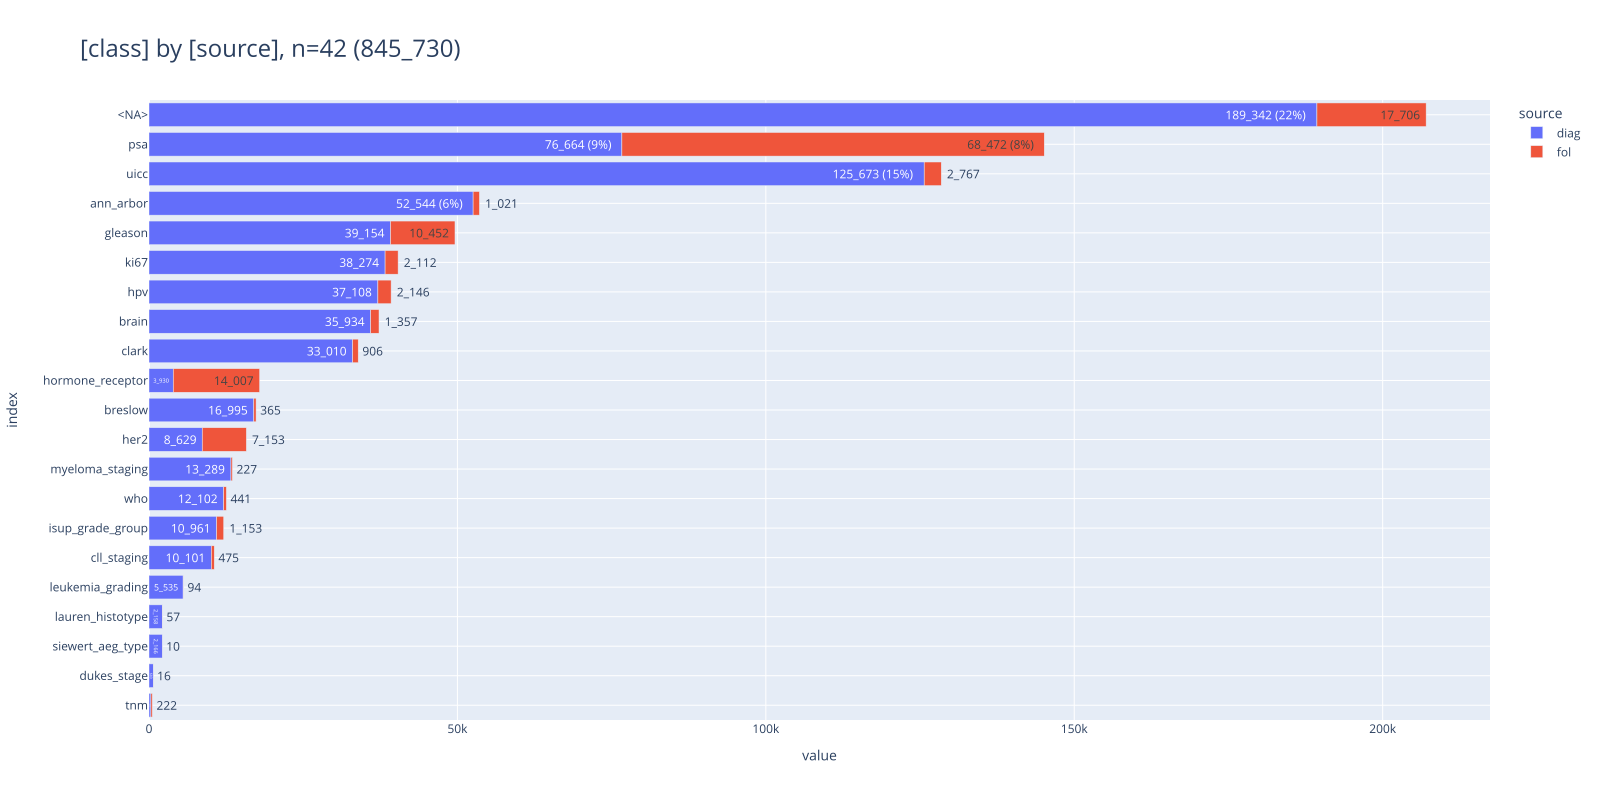

z_kkr_label,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
class,,,,,,,,,,,,,,,,,
ann_arbor,2_054,968,2_400,425,0,6_529,1_215,8_600,8_464,465,6_467,4_567,1_985,5_808,2_092,1_526,53_565
brain,323,0,1_784,457,0,3_308,679,10_813,6_765,701,2_634,2_030,65,4_332,2_115,1_285,37_291
breslow,37,442,700,639,0,1_668,188,3_403,973,700,2_354,1_029,300,197,3_469,1_261,17_360
clark,410,292,1_157,199,0,1_627,1_647,5_070,3_743,999,3_853,3_571,1_294,4_569,3_178,2_307,33_916
cll_staging,300,90,610,31,0,645,287,1_155,1_719,122,446,737,752,2_040,1_119,523,10_576
dukes_stage,0,0,0,0,0,1,0,169,154,0,0,2,20,4,355,0,705
gleason,41,334,730,304,0,5_411,805,15_949,9_773,1_580,806,1_627,1_451,5_623,3_468,1_704,49_606
her2,141,596,445,207,6_641,0,181,5_709,303,1_052,22,16,455,0,0,14,15_782
hormone_receptor,2,0,42,12,13_918,0,12,3_919,10,0,0,0,0,0,0,22,17_937


In [122]:
db_class = (con.sql("""--sql
        with dia_fol as (
            select Name, Stadium, z_tum_id,
            'diag' as source 
            from Diagnose_WeitereKlassifikation
            union
            select Name, Stadium, z_tum_id,
            'fol' as source 
            from Folgeereignis_WeitereKlassifikation
        )
        select
            tum.z_tum_id, Name, Stadium, z_kkr_label, source,
            mem.fx_check_if_class(Name) as class,
        from dia_fol
        join Tumor tum on dia_fol.z_tum_id = tum.z_tum_id
        where Stadium is not null
    """)
)
# tbl.descr_db(db_class, "db_class")

db_class_agg = (db_class
    .aggregate("z_kkr_label, source, class, count(*) as cnt, count(distinct z_tum_id) as cnt_tum")
)

_df = db_class.aggregate("class, source, count(*) as cnt").to_df()
pls.plot_stacked_bars(
    _df,
    orientation="h",
    sort_values_index=True,
    height=800,
    normalize=True,
    show_pct_all=True,
)
_df = db_class_agg.project("z_kkr_label, class, cnt").to_df().dropna()
tbl.pivot_df(
    _df,
    swap=True,
    data_bar_axis="",
    heatmap_axis="xy",
    pct_axis="",
    total_axis="xy",
    total_exclude=True,
)


<br>

## <a id='toc1_12_'></a>[Verteilung Monat von Datum_Vitalstatus](#toc0_)
- **Filter: alle Patienten mit `Verstorben`=N, `DJ` und `SJ` 2020-2024**

> 💡 `HH`: _"Das liegt an unserer Darstellung des Vitalstatus-Datum. Nach Abschluss der DC-Recherche, die nach Abschluss des 'Todesjahres' durchgeführt wird, wird bei allen Patienten bei denen wir keine weiteren Meldungen bzw Informationen zum Vitalstatus bekommen haben der 31.12. des abgeschlossenen 'Todesjahres' gesetzt. In diesem Fall ist dies das aktuelle Jahr - 2 -> 31.12.2022, da die DC-Recherche zum Zeitpunkt der Datenlieferung noch nicht abgeschlossen war. Wenn jetzt ein Patient die letzte Meldung mit einem Leistungsdatum in 2019 hatte, wir aber keine weiteren Informationen bekommen haben, gehen wir also nach Abschluss der Recherche davon aus, dass der Patient am 31.12.2022 noch gelebt hat. Dadurch 'verbessert' sich tatsächlich der Vitalstatus in unseren Daten, ansonsten wäre dieser nämlich irgendwann in 2019."_

> 💡 `ZfKD`: angestrebt ist die Verwendung eines einzelnen Erhebungszeitpunkts (z.B. Dezember)

In [120]:
# todo -> facet by kkr
_filter = f"""--sql
    Verstorben = 'N'
    and year(cast(Datum_Vitalstatus as date)) >= 2020
    and {FILTER_DY}
"""

hlp.print_filter(_filter)

_tu = (Patient
    # to get tum cols
    .join(Tumor, "oBDS_RKIPatientId", "inner")
    .filter(_filter)
    # apply tum filter
    .project("z_kkr_label, month(cast(Datum_Vitalstatus as date)) as Vitalstatus_MM, oBDS_RKIPatientId, year(Datum_Vitalstatus::date)::text as Vitalstatus_YY")
    # count pat, not tum
    .aggregate("z_kkr_label,Vitalstatus_MM, Vitalstatus_YY, count(distinct oBDS_RKIPatientId) as cnt")
    .order("z_kkr_label,Vitalstatus_MM")
    .to_df()
    .astype({"Vitalstatus_MM": "Int64"}).astype({"Vitalstatus_MM": str})
)
_tu.Vitalstatus_MM = _tu.Vitalstatus_MM.str.zfill(2)

# _tu

<!-- START_TOKEN -->

# filter

    Verstorben = 'N'
    and year(cast(Datum_Vitalstatus as date)) >= 2020
    and z_dy between 2020 and 2024



<!-- END_TOKEN -->

In [121]:
# _=pls.plot_facet_stacked_bars(
#     _tu[[
#         "Vitalstatus_YY",
#         "Vitalstatus_MM",
#         "z_kkr_label",
#         "cnt"
#     ]].sort_values(["Vitalstatus_YY"]),
#     relative=True,
#     subplot_size=400,
#     # subplots_per_row=4,
#     # top_n_color=5,
#     # sort_values_index=True,
#     sort_values_facet=True,
#     # show_other=False,
#     annotations=True,
# )

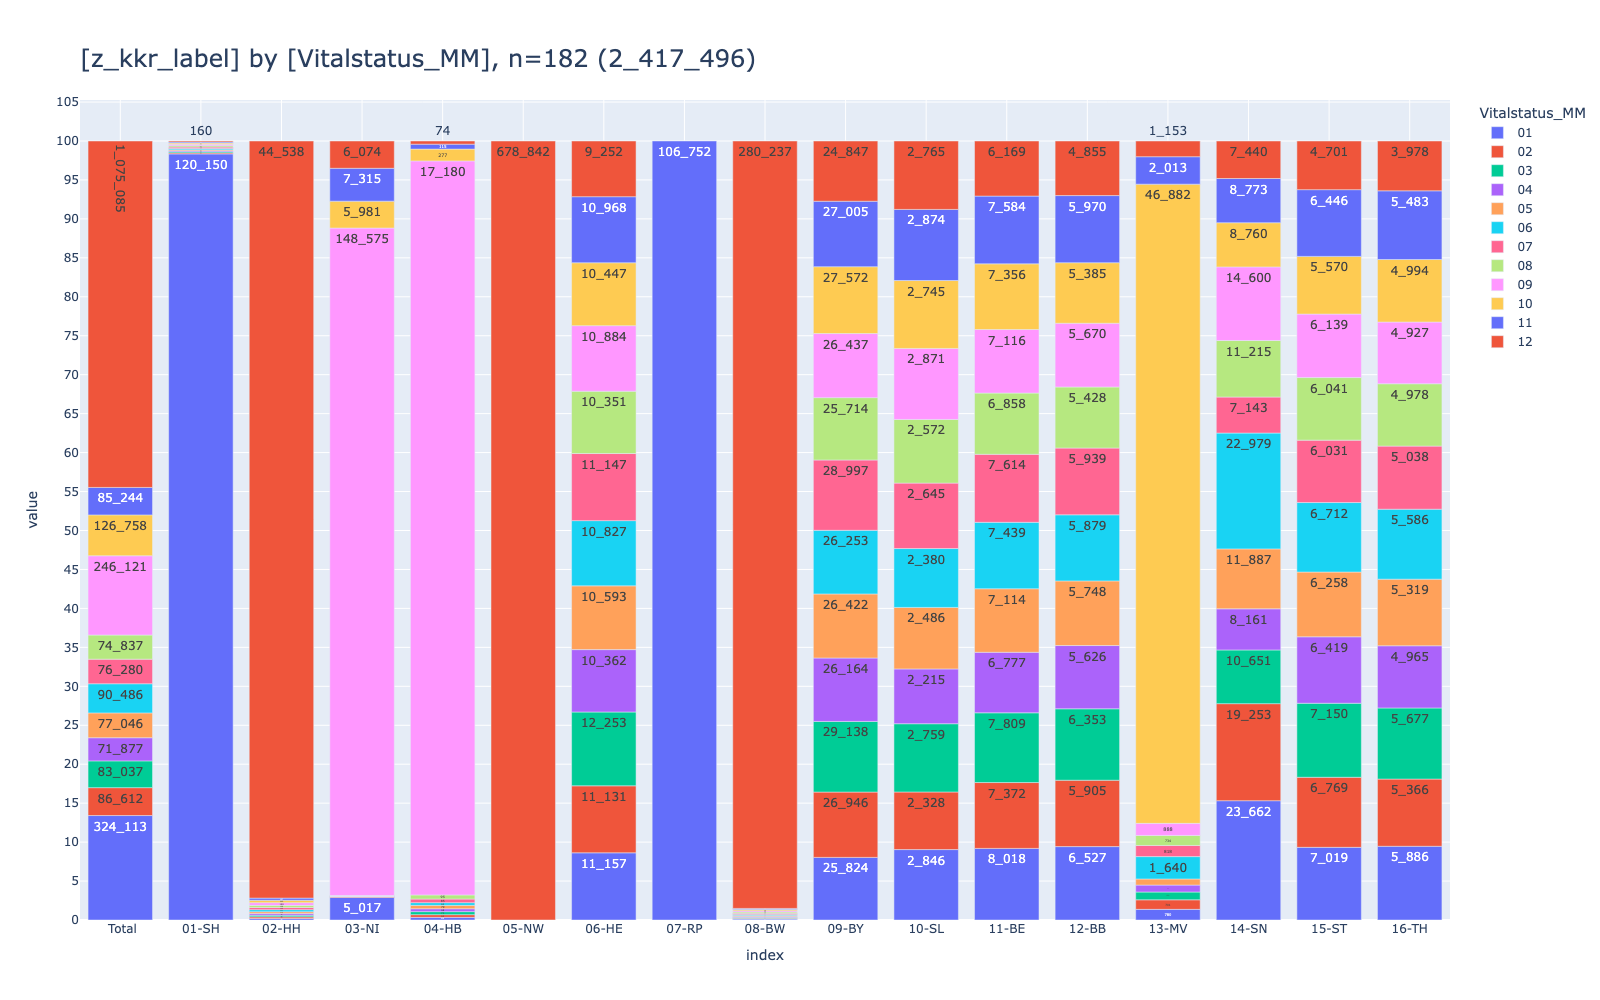

In [95]:

_ = pls.plot_stacked_bars(
    _tu[["z_kkr_label","Vitalstatus_MM","cnt"]],
    orientation="v",
    show_total=True,
    normalize=False,
    relative=True,
    height=1000,
    renderer="png",
)

### <a id='toc1_12_1_'></a>[Vitalstatus Jahr](#toc0_)

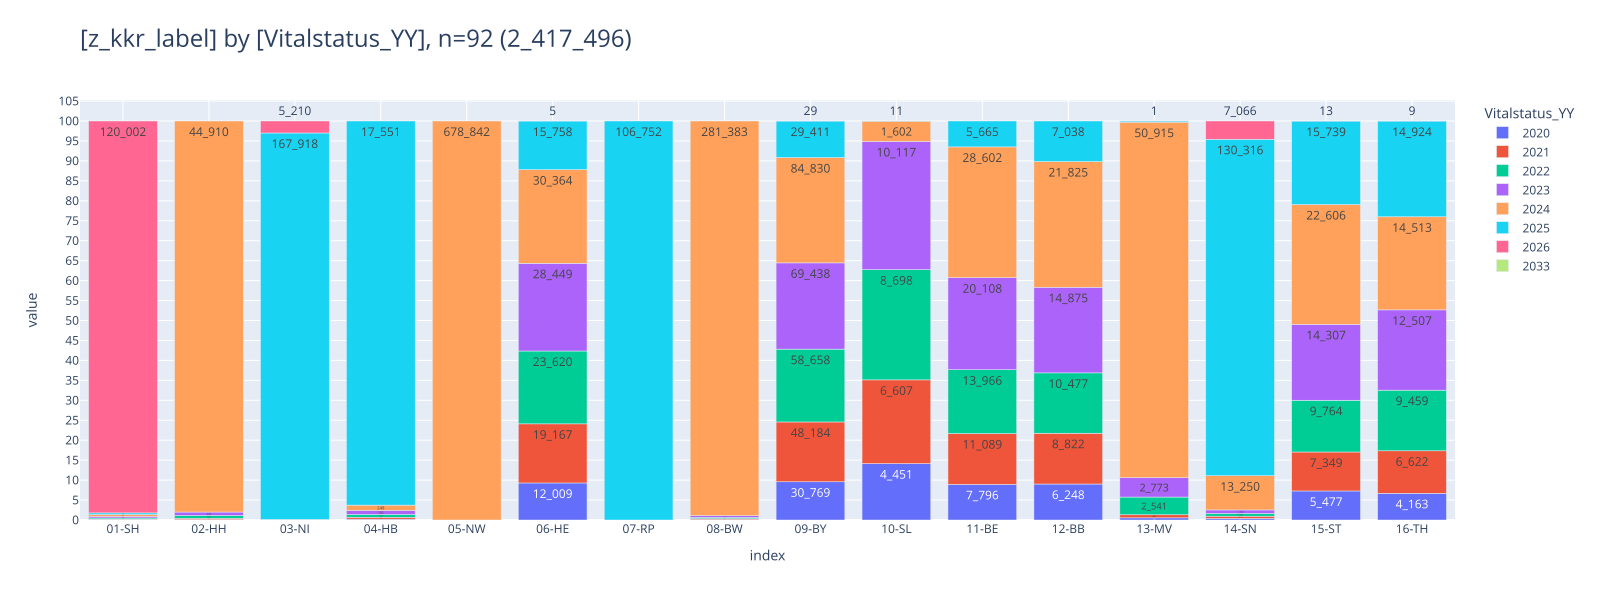

In [103]:
# _filter = """--sql
#     year(Datum_Vitalstatus) >= 2020
#     and Verstorben = 'N'"""

# hlp.print_filter(_filter)

# _df = con.sql(f"""--sql
#     select
#         year(Datum_Vitalstatus)::text as SJ,
#         lpad(z_kkr::text, 2, '0') as kkr
#     from Patient
#     where {_filter}
#     """).to_df()

pls.plot_stacked_bars(
    # _df,
    _tu[["z_kkr_label","Vitalstatus_YY","cnt"]],
    # swap=True,
    relative=True,
)

<div style="page-break-after: always;"></div>

## <a id='toc1_13_'></a>[Numerische Variablen 🔢](#toc0_)

In [58]:
df_numerics = (
    Tumor.project("""--sql
        z_kkr_label
        ,z_age
        ,Tumordicke
        ,Anzahl_Tage_Diagnose_Tod::int as Anzahl_Tage_Diagnose_Tod
        ,PSA
        ,LK_befallen::int as LK_befallen
        ,LK_untersucht::int as LK_untersucht
        ,RektumAbstandAnokutanlinie::int as RektumAbstandAnokutanlinie
        ,LDH::int as LDH
        """)
    .order("z_kkr_label")
    .to_df()
)

<br>

### <a id='toc1_13_1_'></a>[Diagnosealter](#toc0_)
- berechnet aus `Diagnosejahr` - `Geburtsjahr`
- negative Werte entstehen aus falscher Datumsreihenfolge von Ereignissen
- die Datumsangaben sind **nicht bereinigt**, um strukturelle Effekte sichtbar zu machen

> 💡 `HH`: _"Ja, das liegt an dem Geschätzt-Flag in den Datumsangaben. In unseren Daten haben wir noch die alte Ausprägung 'Jahr geschätzt', diese wird dann im ZFKD-Datensatz mit 'Vollständig geschätzt' übersetzt. Theoretisch könnten Sie statt 1900 auch das angegebene Jahr nutzen… Aber diese Schätz-Angabe ist uns auch ein Dorn im Auge. Wir werden es auch noch in unseren Daten bereinigen. Zumeist handelt es sich da bei uns um Dokumentations oder Verständnisfehler."_

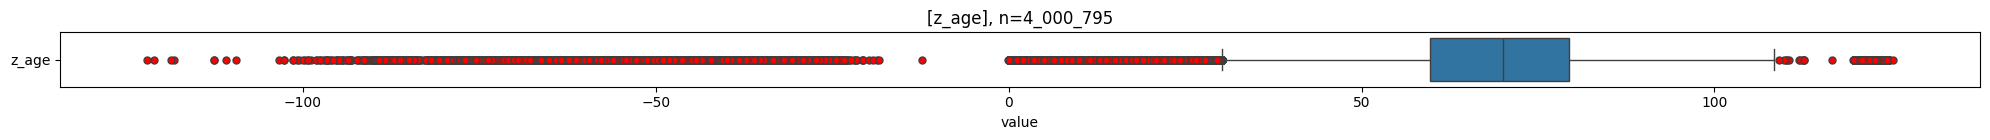

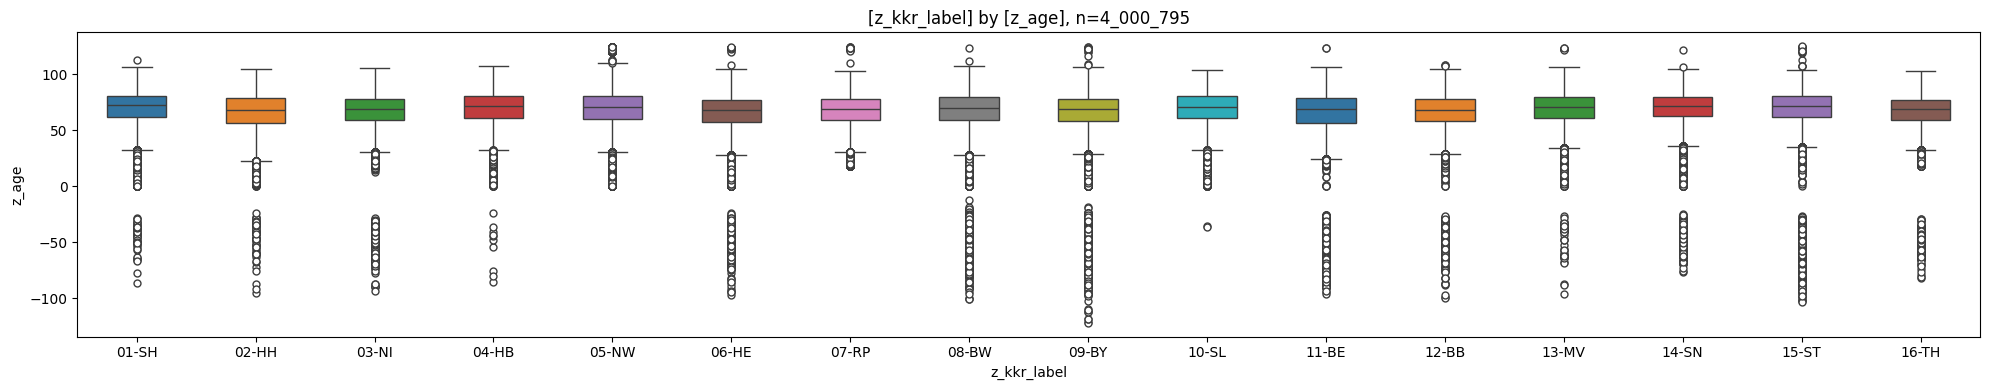


column (n = 4_000_795) |     notnull      |   min   | lower |  q25  | median | mean  |  q75  | upper  |  max   |  std  |  cv 
-----------------------+------------------+---------+-------+-------+--------+-------+-------+--------+--------+-------+-----
z_age                  | 4_000_795 (100%) | -122.00 | 30.25 | 59.67 |  70.00 | 68.01 | 79.33 | 108.50 | 125.25 | 15.27 | 0.22




item (n = 4_000_795) |   count   |   min   | lower |  q25  | median | mean  |  q75  | upper  |  max   |  std  |  cv 
---------------------+-----------+---------+-------+-------+--------+-------+-------+--------+--------+-------+-----
01-SH                |   194_283 |  -86.25 | 32.58 | 61.58 |  72.50 | 70.09 | 80.92 | 106.67 | 112.50 | 14.37 | 0.21
02-HH                |    69_613 |  -95.17 | 22.83 | 56.42 |  68.58 | 66.06 | 78.83 | 104.83 | 104.83 | 16.54 | 0.25
03-NI                |   277_590 |  -93.33 | 30.58 | 58.92 |  68.75 | 67.02 | 77.83 | 105.33 | 105.33 | 14.50 | 0.22
04-HB                |    30_960 |  -85.83 | 32.08 | 61.08 |  71.58 | 69.41 | 80.42 | 107.33 | 107.33 | 14.72 | 0.21
05-NW                | 1_017_558 |    0.00 | 30.33 | 60.33 |  70.75 | 69.00 | 80.33 | 110.33 | 124.67 | 14.67 | 0.21
06-HE                |   207_946 |  -97.50 | 28.08 | 57.58 |  68.00 | 65.94 | 77.25 | 105.00 | 124.67 | 15.48 | 0.23
07-RP                |   162_063 |   18.00 | 30.33 | 58.83 |  6

In [59]:
_=pls.plot_box_large(df_numerics["z_age"], height=150, width=2000, summary=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "z_age"]], height=400, width=2000, )

<br>

### <a id='toc1_13_2_'></a>[Anzahl Tage zwischen Diagnose und Tod](#toc0_)

> 💡 `ZfKD`: _Es treten Extremwerte auf, weit ausserhalb des Interquartilsabstandes. Grund dafür sind mutmasslich fehlende Datumsangaben, die auf 1900 kodiert werden._  
> _In der KKR Verteilung sind die Extreme in den GTDS Ländern besonders ausgeprägt_

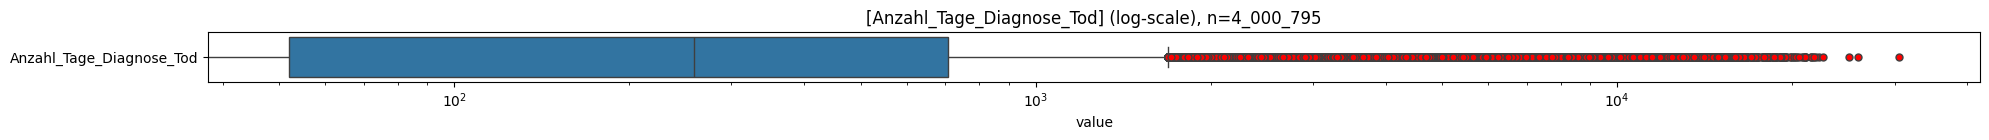

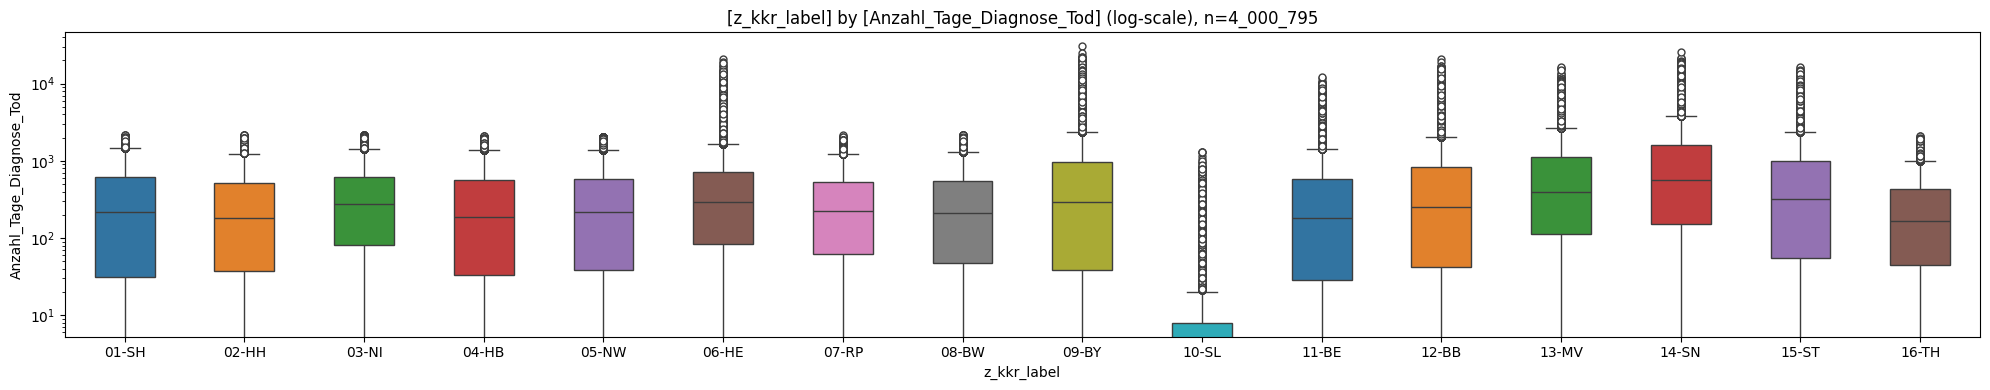


column (n = 4_000_795)   |     notnull     |   min   | lower |  q25  | median |  mean  |  q75   | upper |  max   |   std    |  cv 
-------------------------+-----------------+---------+-------+-------+--------+--------+--------+-------+--------+----------+-----
Anzahl_Tage_Diagnose_Tod | 1_152_972 (28%) | -27_320 |  -212 | 52.00 | 259.00 | 653.84 | 707.00 | 1_689 | 30_590 | 1_271.97 | 1.95


item (n = 4_000_795) |  count  |   min   | lower |  q25   | median |   mean   |   q75    | upper |  max   |   std    |  cv 
---------------------+---------+---------+-------+--------+--------+----------+----------+-------+--------+----------+-----
01-SH                |  55_342 |       0 |     0 |  31.00 | 217.00 |   391.41 |   611.00 | 1_481 |  2_185 |   450.63 | 1.15
02-HH                |  23_361 |       0 |     0 |  38.00 | 184.00 |   349.72 |   521.00 | 1_245 |  2_159 |   415.34 | 1.19
03-NI                |  85_931 |       0 |     0 |  81.00 | 273.00 |   420.74 |   625.00 | 1_441 |  2_187 | 

In [60]:
_=pls.plot_box_large(df_numerics["Anzahl_Tage_Diagnose_Tod"], height=150, width=2000, use_log=True, summary=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "Anzahl_Tage_Diagnose_Tod"]], height=400, width=2000, summary=True, use_log=True)

<br>

### <a id='toc1_13_3_'></a>[Tumordicke](#toc0_)

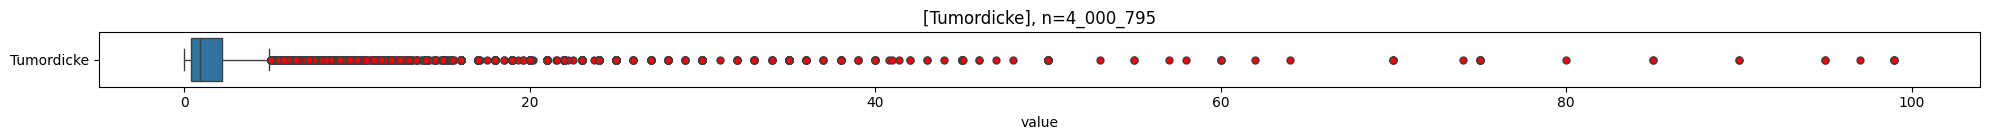


column (n = 4_000_795) |   notnull   |  min  | lower |  q25  | median | mean  |  q75  | upper |  max   |  std  |  cv  
-----------------------+-------------+-------+-------+-------+--------+-------+-------+-------+--------+-------+------
Tumordicke             | 58_628 (1%) | 0.010 | 0.010 | 0.400 |  0.900 | 1.951 | 2.200 | 4.900 | 99.000 | 3.516 | 1.802



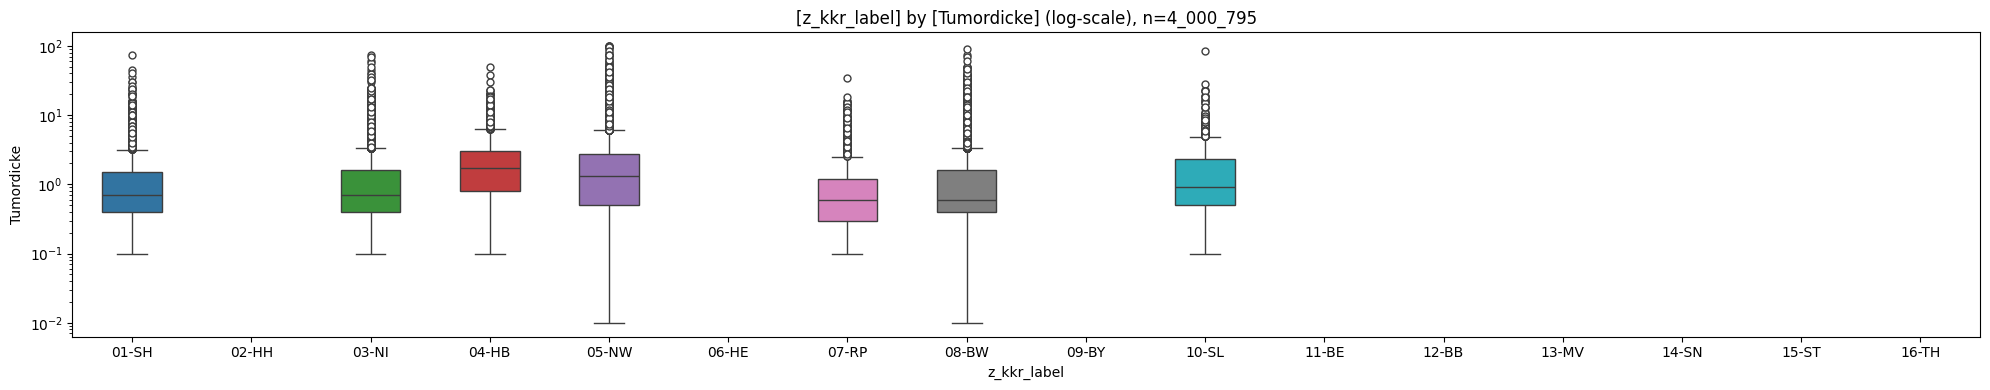

In [61]:
_=pls.plot_box_large(df_numerics["Tumordicke"], height=150, width=2000, use_log=False, violin=False, summary=True)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "Tumordicke"]], height=400, width=2000, summary=False, use_log=True)

### <a id='toc1_13_4_'></a>[PSA](#toc0_)

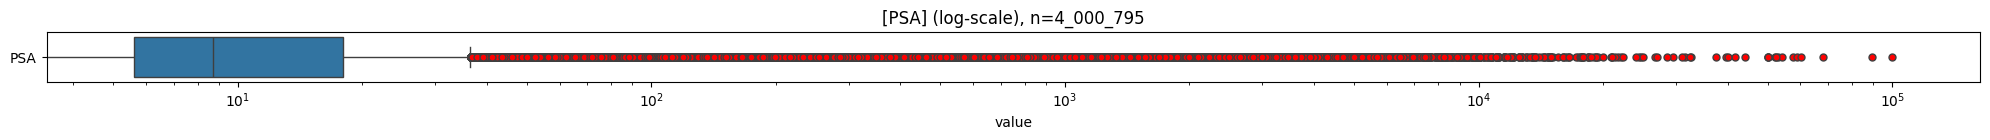


column (n = 4_000_795) |   notnull    |  min  | lower |  q25  | median |  mean  |  q75   | upper  |    max     |   std   |  cv  
-----------------------+--------------+-------+-------+-------+--------+--------+--------+--------+------------+---------+------
PSA                    | 243_614 (6%) | 0.000 | 0.000 | 5.630 |  8.730 | 90.411 | 18.000 | 36.550 | 99_999.000 | 742.986 | 8.218



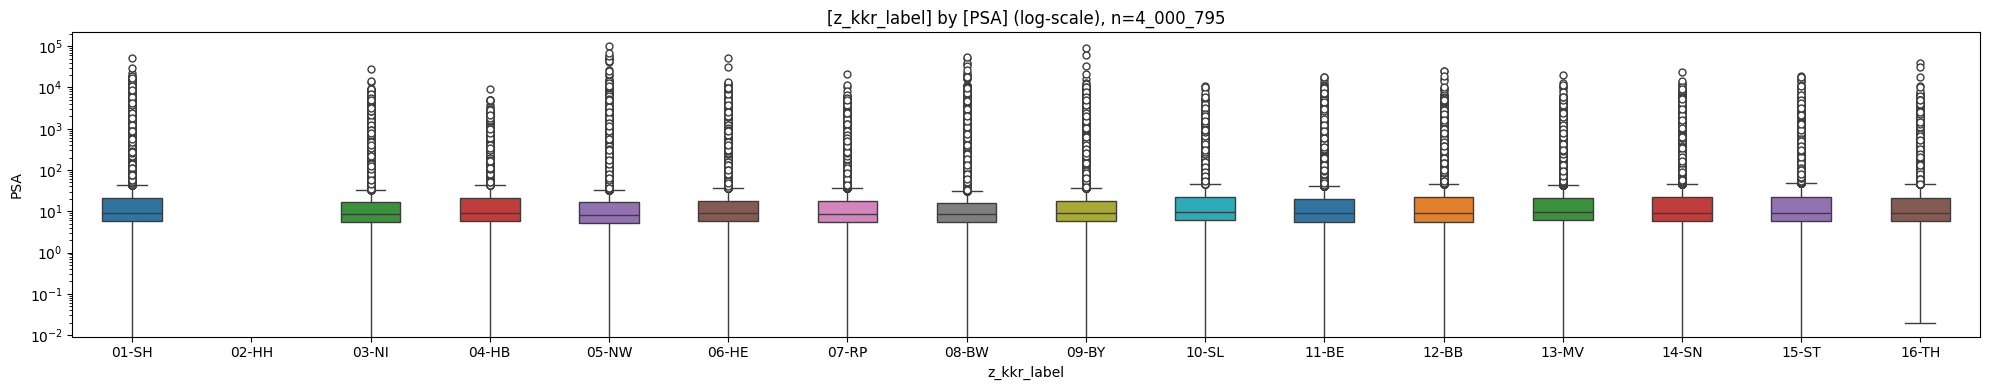

In [62]:
_=pls.plot_box_large(df_numerics["PSA"], height=150, width=2000, use_log=True, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "PSA"]], height=400, width=2000, summary=False, use_log=True)

### <a id='toc1_13_5_'></a>[LK_befallen](#toc0_)

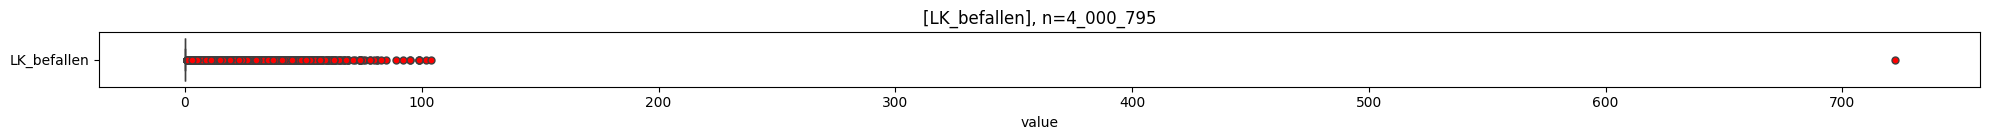


column (n = 4_000_795) |    notnull    | min | lower |  q25  | median | mean  |  q75  | upper | max |  std  |  cv  
-----------------------+---------------+-----+-------+-------+--------+-------+-------+-------+-----+-------+------
LK_befallen            | 794_122 (19%) |   0 |     0 | 0.000 |  0.000 | 0.915 | 0.000 |     0 | 722 | 3.077 | 3.361



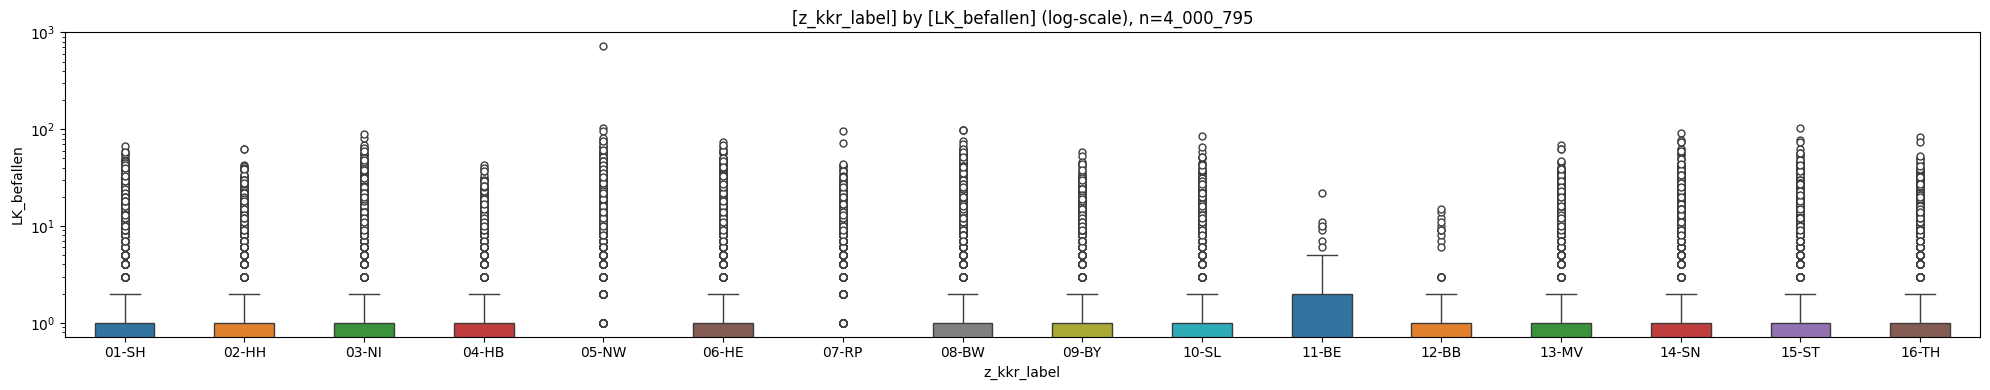

In [63]:
_=pls.plot_box_large(df_numerics["LK_befallen"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "LK_befallen"]], height=400, width=2000,  summary=False, use_log=True)

### <a id='toc1_13_6_'></a>[LK_untersucht](#toc0_)

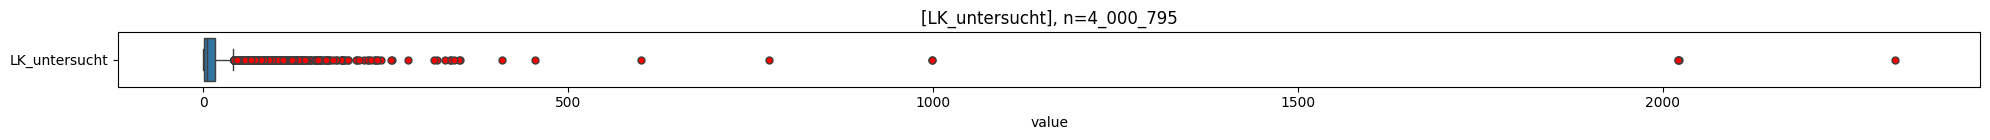


column (n = 4_000_795) |    notnull    | min | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv  
-----------------------+---------------+-----+-------+-------+--------+--------+--------+-------+-------+--------+------
LK_untersucht          | 965_882 (24%) |   0 |     0 | 1.000 |  5.000 | 10.622 | 17.000 |    41 | 2_319 | 13.664 | 1.286



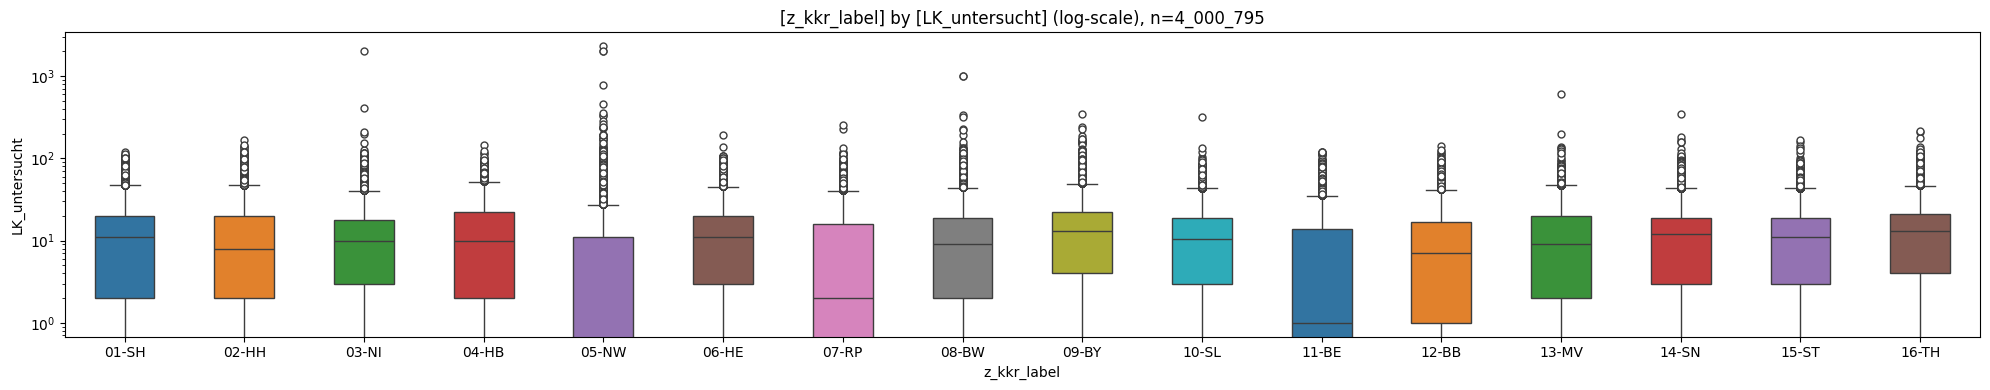

In [64]:
_=pls.plot_box_large(df_numerics["LK_untersucht"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "LK_untersucht"]], height=400, width=2000,  summary=False, use_log=True)

### <a id='toc1_13_7_'></a>[RektumAbstandAnokutanlinie](#toc0_)

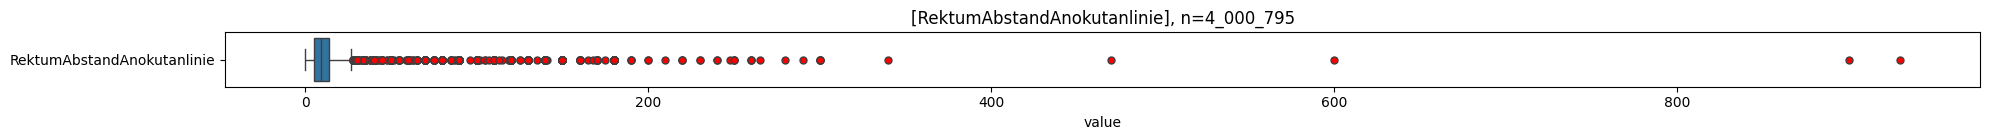


column (n = 4_000_795)     |   notnull   | min | lower |  q25  | median |  mean  |  q75   | upper | max |  std   |  cv  
---------------------------+-------------+-----+-------+-------+--------+--------+--------+-------+-----+--------+------
RektumAbstandAnokutanlinie | 42_304 (1%) |   0 |     0 | 5.000 |  9.000 | 11.292 | 14.000 |    27 | 930 | 16.997 | 1.505



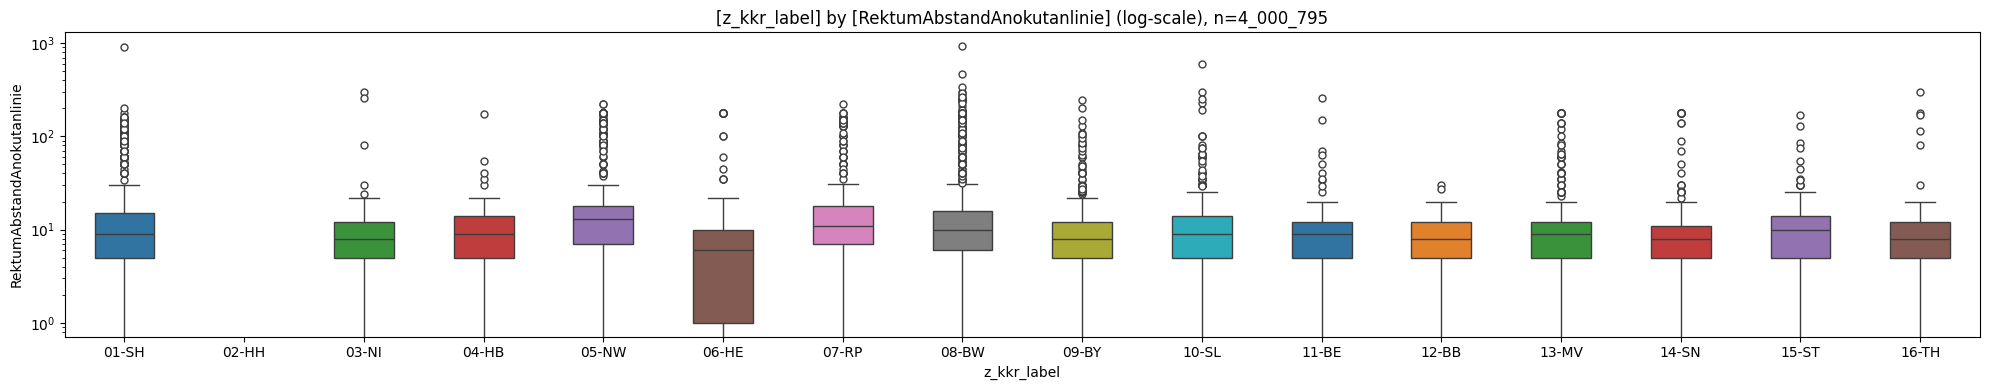

In [65]:
_=pls.plot_box_large(df_numerics["RektumAbstandAnokutanlinie"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "RektumAbstandAnokutanlinie"]], height=400, width=2000,  summary=False, use_log=True)

### <a id='toc1_13_8_'></a>[LDH](#toc0_)

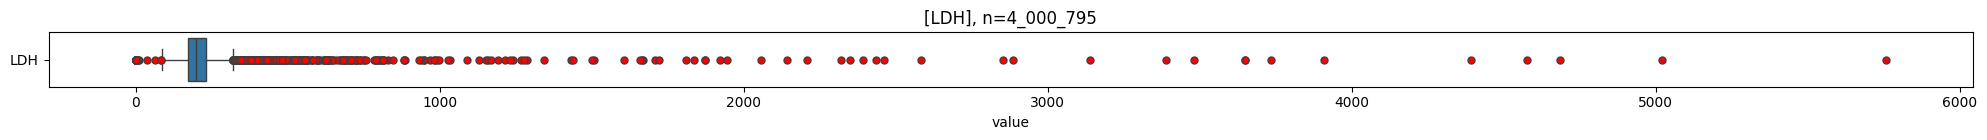


column (n = 4_000_795) |  notnull   | min | lower |   q25   | median  |  mean   |   q75   | upper |  max  |   std   |  cv  
-----------------------+------------+-----+-------+---------+---------+---------+---------+-------+-------+---------+------
LDH                    | 8_071 (0%) |   1 |    85 | 173.000 | 198.000 | 223.747 | 232.000 |   320 | 5_756 | 207.203 | 0.926



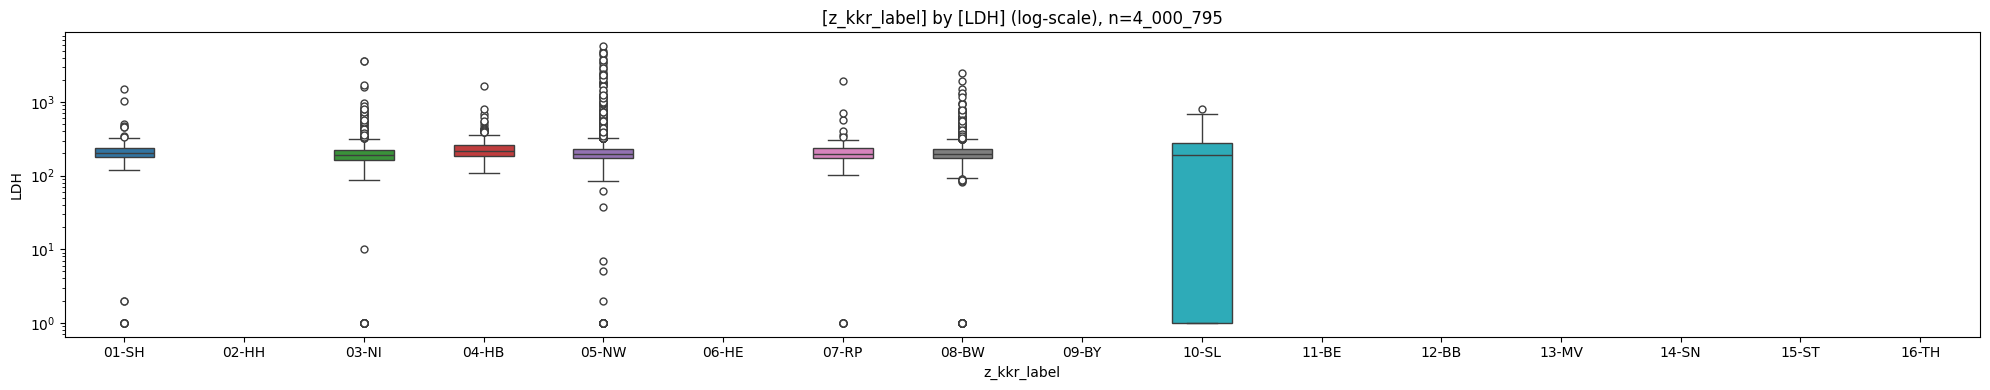

In [66]:
_=pls.plot_box_large(df_numerics["LDH"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "LDH"]], height=400, width=2000,  summary=False, use_log=True)